# SDV Models: Comprehensive Evaluation

This notebook contains a comprehensive evaluation of four synthetic data generation models:
1. **CTGAN** - Conditional Tabular GAN
2. **CopulaGAN** - GAN-based with copula modeling
3. **Gaussian Copula** - Statistical copula-based approach
4. **TVAE** - Tabular Variational Autoencoder

Each model is evaluated using multiple fidelity metrics including KS test, JS divergence, Wasserstein distance, and more.


## Data Loading and Setup


In [1]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
energy_efficiency = fetch_ucirepo(id=242) 
  
# data (as pandas dataframes) 
X = energy_efficiency.data.features 
y = energy_efficiency.data.targets 
  
# metadata 
print(energy_efficiency.metadata) 
  
# variable information 
print(energy_efficiency.variables) 

{'uci_id': 242, 'name': 'Energy Efficiency', 'repository_url': 'https://archive.ics.uci.edu/dataset/242/energy+efficiency', 'data_url': 'https://archive.ics.uci.edu/static/public/242/data.csv', 'abstract': 'This study looked into assessing the heating load and cooling load requirements of buildings (that is, energy efficiency) as a function of building parameters.', 'area': 'Computer Science', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 768, 'num_features': 8, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Y1', 'Y2'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2012, 'last_updated': 'Mon Feb 26 2024', 'dataset_doi': '10.24432/C51307', 'creators': ['Athanasios Tsanas', 'Angeliki Xifara'], 'intro_paper': {'ID': 379, 'type': 'NATIVE', 'title': 'Accurate quantitative estimation of energy performance of residential buildings using statistical machine 

In [2]:
import pandas as pd
import numpy as np

data = pd.concat([X, y[["Y1"]]], axis=1)
target_col = "Y1"

# Drop date/time/session/ID features before generator training (high cardinality).
_drop_feature_cols = [
    "Date", "Time", "date_time",
    "session_id", "Session ID", "Session_ID", "session",
    "X1 transaction date",
]
data = data.drop(columns=[c for c in _drop_feature_cols if c in data.columns], errors="ignore")

n_samples = min(1000, len(data))
data = data.sample(n=n_samples, random_state=42).reset_index(drop=True)

for col in data.columns:
    data[col] = pd.to_numeric(data[col], errors="coerce")
    data[col] = data[col].fillna(data[col].median())


# Generating synthetic data

In [3]:
# Import SDV libraries
import sdv
from sdv.metadata import SingleTableMetadata

metadata = SingleTableMetadata()
metadata.detect_from_dataframe(data)


from sdv.single_table import (
    CTGANSynthesizer,
    CopulaGANSynthesizer,
    TVAESynthesizer,
    GaussianCopulaSynthesizer
)
from sdv.evaluation.single_table import evaluate_quality, run_diagnostic

# Number of synthetic rows to generate per model
n_samples = len(data)

# Define models in one place
models = {
    "CTGAN": CTGANSynthesizer(metadata=metadata),
    "CopulaGAN": CopulaGANSynthesizer(metadata=metadata),
    "TVAE": TVAESynthesizer(metadata=metadata),
    "GaussianCopula": GaussianCopulaSynthesizer(metadata=metadata)
}

# Store outputs
synthetic_datasets = {}
diagnostic_reports = {}
quality_reports = {}
summary = []

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(data)

    synthetic_data = model.sample(n_samples)
    synthetic_datasets[name] = synthetic_data

    diagnostic_report = run_diagnostic(
        real_data=data,
        synthetic_data=synthetic_data,
        metadata=metadata
    )
    quality_report = evaluate_quality(
        real_data= data,
        synthetic_data=synthetic_data,
        metadata=metadata
    )

    diagnostic_reports[name] = diagnostic_report
    quality_reports[name] = quality_report

    diag_score = diagnostic_report.get_score()
    qual_score = quality_report.get_score()
    summary.append((name, diag_score, qual_score))

# Quick comparison table
summary_df = pd.DataFrame(summary, columns=["Model", "Diagnostic Score", "Quality Score"])
summary_df = summary_df.sort_values("Quality Score", ascending=False).reset_index(drop=True)

print("\nModel comparison:")
display(summary_df)

# Example: best model synthetic data
best_model_name = summary_df.loc[0, "Model"]
best_synthetic_data = synthetic_datasets[best_model_name]
print(f"\nBest model by quality score: {best_model_name}")
display(best_synthetic_data.head())

c:\Users\Gopi.Battineni\AppData\Local\Programs\Python\Python312\Lib\site-packages\sdv\single_table\base.py:183: FutureWarning: The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.
  warnings.warn(DEPRECATION_MSG, FutureWarning)
c:\Users\Gopi.Battineni\AppData\Local\Programs\Python\Python312\Lib\site-packages\sdv\single_table\base.py:139: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(



Training CTGAN...


c:\Users\Gopi.Battineni\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.2.2
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


Generating report ...

(1/2) Evaluating Data Validity: |██████████| 9/9 [00:00<00:00, 1797.64it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 500.16it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 9/9 [00:00<00:00, 627.90it/s]|
Column Shapes Score: 78.53%

(2/2) Evaluating Column Pair Trends: |██████████| 36/36 [00:00<00:00, 325.91it/s]|
Column Pair Trends Score: 56.93%

Overall Score (Average): 67.73%


Training CopulaGAN...
Generating report ...

(1/2) Evaluating Data Validity: |██████████| 9/9 [00:00<00:00, 768.00it/s]|
Data Validity Score: 100.0%

(2/2) Evaluating Data Structure: |██████████| 1/1 [00:00<00:00, 294.96it/s]|
Data Structure Score: 100.0%

Overall Score (Average): 100.0%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 9/9 [00:00<00:00, 294.98it/s]|
Column Shapes Score: 79.92%

(2/2) Evaluating Column Pair Trend

,Model,Diagnostic Score,Quality Score
0,TVAE,1.0,0.886220
1,GaussianCopula,1.0,0.789355
2,CopulaGAN,1.0,0.686985
3,CTGAN,1.0,0.677298



Best model by quality score: TVAE


,X1,X2,X3,X4,X5,X6,X7,X8,Y1
0,0.76,701.4,294.6,220.36,7.0,3,0.40,5,37.04
1,0.66,771.9,368.4,220.26,3.5,2,0.25,5,14.36
2,0.76,542.0,295.3,146.31,7.0,3,0.10,3,34.11
3,0.92,591.3,317.2,121.55,7.0,3,0.25,2,30.40
4,0.68,683.7,259.0,220.50,3.5,4,0.10,1,11.55


# 1. Univariate Analysis

### 1.1.  Kolmogorov-Smirnov (K-S) test

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 8/8 [00:00<00:00, 649.81it/s]|
Column Shapes Score: 77.59%

(2/2) Evaluating Column Pair Trends: |██████████| 28/28 [00:00<00:00, 211.15it/s]|
Column Pair Trends Score: 53.73%

Overall Score (Average): 65.66%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 8/8 [00:00<00:00, 864.96it/s]|
Column Shapes Score: 80.96%

(2/2) Evaluating Column Pair Trends: |██████████| 28/28 [00:00<00:00, 261.25it/s]|
Column Pair Trends Score: 53.7%

Overall Score (Average): 67.33%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 8/8 [00:00<00:00, 819.36it/s]|
Column Shapes Score: 86.04%

(2/2) Evaluating Column Pair Trends: |██████████| 28/28 [00:00<00:00, 301.07it/s]|
Column Pair Trends Score: 90.45%

Overall Score (Average): 88.24%

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 8/8 [00:00<00:00, 638.18it/s]|
Column Shapes Score: 75.55%

(2/2) Evaluating Column Pair Trends: |█

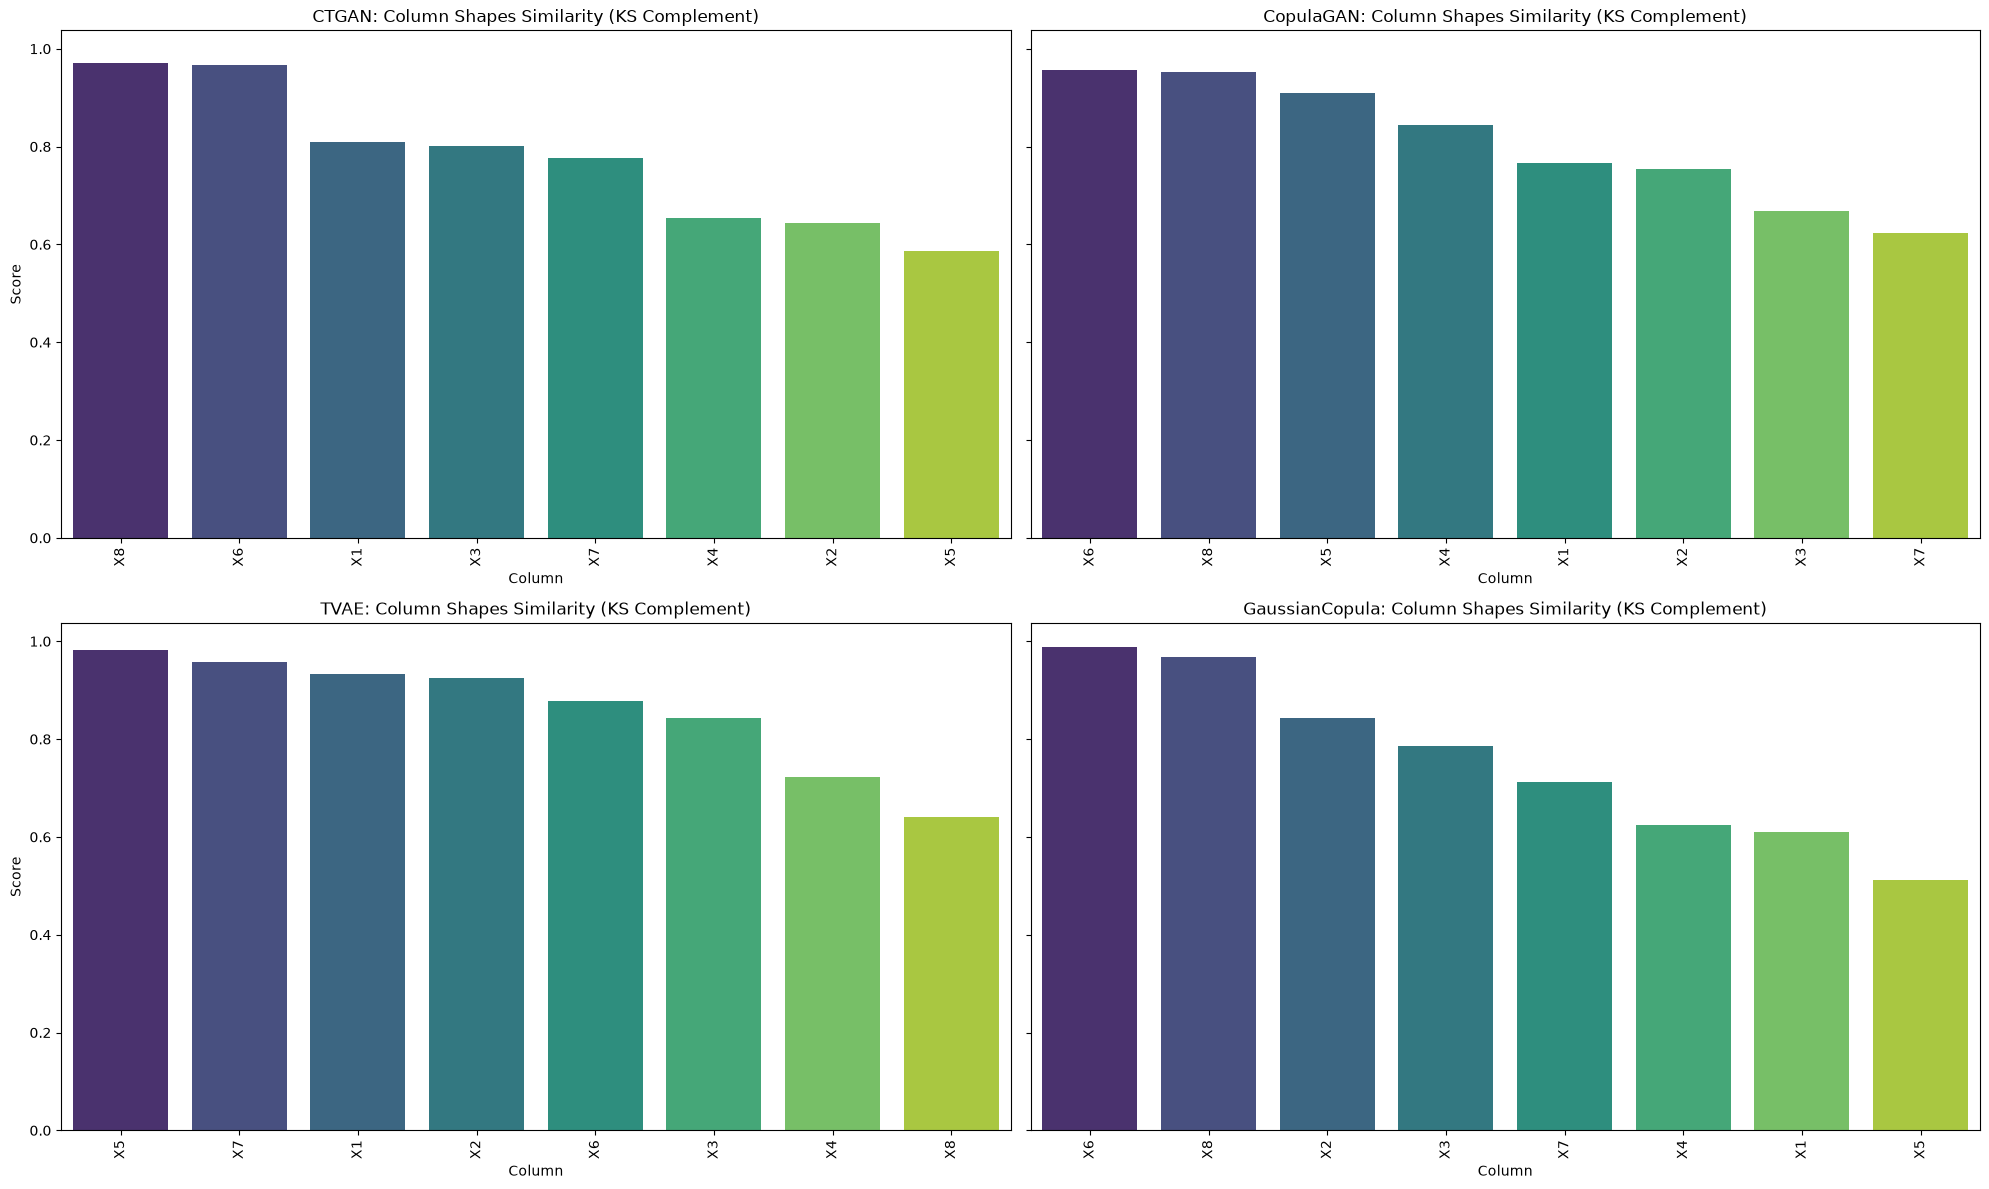

,Column,Metric,Score,Model
0,X8,TVComplement,0.970052,CTGAN
1,X6,TVComplement,0.967448,CTGAN
2,X1,KSComplement,0.808594,CTGAN
3,X3,KSComplement,0.800781,CTGAN
4,X7,KSComplement,0.776042,CTGAN
5,X4,KSComplement,0.653646,CTGAN
6,X2,KSComplement,0.644531,CTGAN
7,X5,KSComplement,0.585938,CTGAN
8,X6,TVComplement,0.955729,CopulaGAN
9,X8,TVComplement,0.953125,CopulaGAN


In [4]:
import warnings
warnings.filterwarnings("ignore")

from sdv.evaluation.single_table import QualityReport
from sdv.metadata import SingleTableMetadata
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "Y1"

real_eval = data.drop(columns=[target_col], errors="ignore").copy()

metadata_eval = SingleTableMetadata()
metadata_eval.detect_from_dataframe(real_eval)

column_shape_details = {}

for model_name in model_order:
    synth_eval = synthetic_datasets[model_name].drop(columns=[target_col], errors="ignore").copy()
    synth_eval = synth_eval[real_eval.columns]

    qr = QualityReport()
    qr.generate(
        real_data=real_eval,
        synthetic_data=synth_eval,
        metadata=metadata_eval.to_dict()
    )
    details = qr.get_details("Column Shapes").sort_values("Score", ascending=False)
    column_shape_details[model_name] = details

fig, axes = plt.subplots(2, 2, figsize=(20, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    details = column_shape_details[model_name]
    sns.barplot(
        x="Column", y="Score",
        data=details,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Column Shapes Similarity (KS Complement)")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Column")
    ax.set_ylabel("Score")

plt.tight_layout()
plt.show()

combined_details = pd.concat(
    [df.assign(Model=name) for name, df in column_shape_details.items()],
    ignore_index=True
)
display(combined_details.head(20))


### 1.2. Jensen–Shannon divergence

In [5]:
import numpy as np
from pandas.api.types import is_numeric_dtype
from scipy.spatial.distance import jensenshannon
from sklearn.preprocessing import MinMaxScaler

def _prob_vectors_numeric(real, synth, bins=30, eps=1e-12):
    """Convert numeric columns into comparable probability vectors."""
    real = pd.to_numeric(real, errors='coerce').dropna().to_numpy()
    synth = pd.to_numeric(synth, errors='coerce').dropna().to_numpy()

    edges = np.histogram_bin_edges(np.concatenate([real, synth]), bins=bins)
    r_hist, _ = np.histogram(real, bins=edges)
    s_hist, _ = np.histogram(synth, bins=edges)

    r = r_hist.astype(float) + eps
    s = s_hist.astype(float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s

def _prob_vectors_categorical(real, synth, eps=1e-12):
    """Convert categorical columns into comparable probability vectors."""
    r_counts = real.astype(str).value_counts(dropna=False)
    s_counts = synth.astype(str).value_counts(dropna=False)
    keys = r_counts.index.union(s_counts.index)
    r = r_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    s = s_counts.reindex(keys, fill_value=0).to_numpy(dtype=float) + eps
    r /= r.sum()
    s /= s.sum()
    return r, s, keys

def compute_js_divergence(real_df: pd.DataFrame,
                          synth_df: pd.DataFrame,
                          bins=30,
                          normalize=True) -> pd.DataFrame:
    """
    Compute Jensen–Shannon Divergence for each column between real and synthetic data.
    Returns a DataFrame with per-feature JS divergence values.
    """
    common_cols = [c for c in real_df.columns if c in synth_df.columns]
    real = real_df[common_cols].copy()
    synth = synth_df[common_cols].copy()

    # Optional normalization for numeric columns
    if normalize:
        num_cols = [c for c in common_cols if is_numeric_dtype(real[c])]
        scaler = MinMaxScaler()
        real[num_cols] = scaler.fit_transform(real[num_cols])
        synth[num_cols] = scaler.transform(synth[num_cols])

    results = []
    for col in common_cols:
        r_col, s_col = real[col], synth[col]

        if is_numeric_dtype(r_col):
            p, q = _prob_vectors_numeric(r_col, s_col, bins=bins)
        else:
            p, q, _ = _prob_vectors_categorical(r_col, s_col)

        # Jensen-Shannon divergence (base=2 → bounded [0,1])
        js_div = jensenshannon(p, q, base=2) ** 2

        results.append({"Feature": col, "JS_Divergence": js_div})

    return pd.DataFrame(results).sort_values("JS_Divergence")


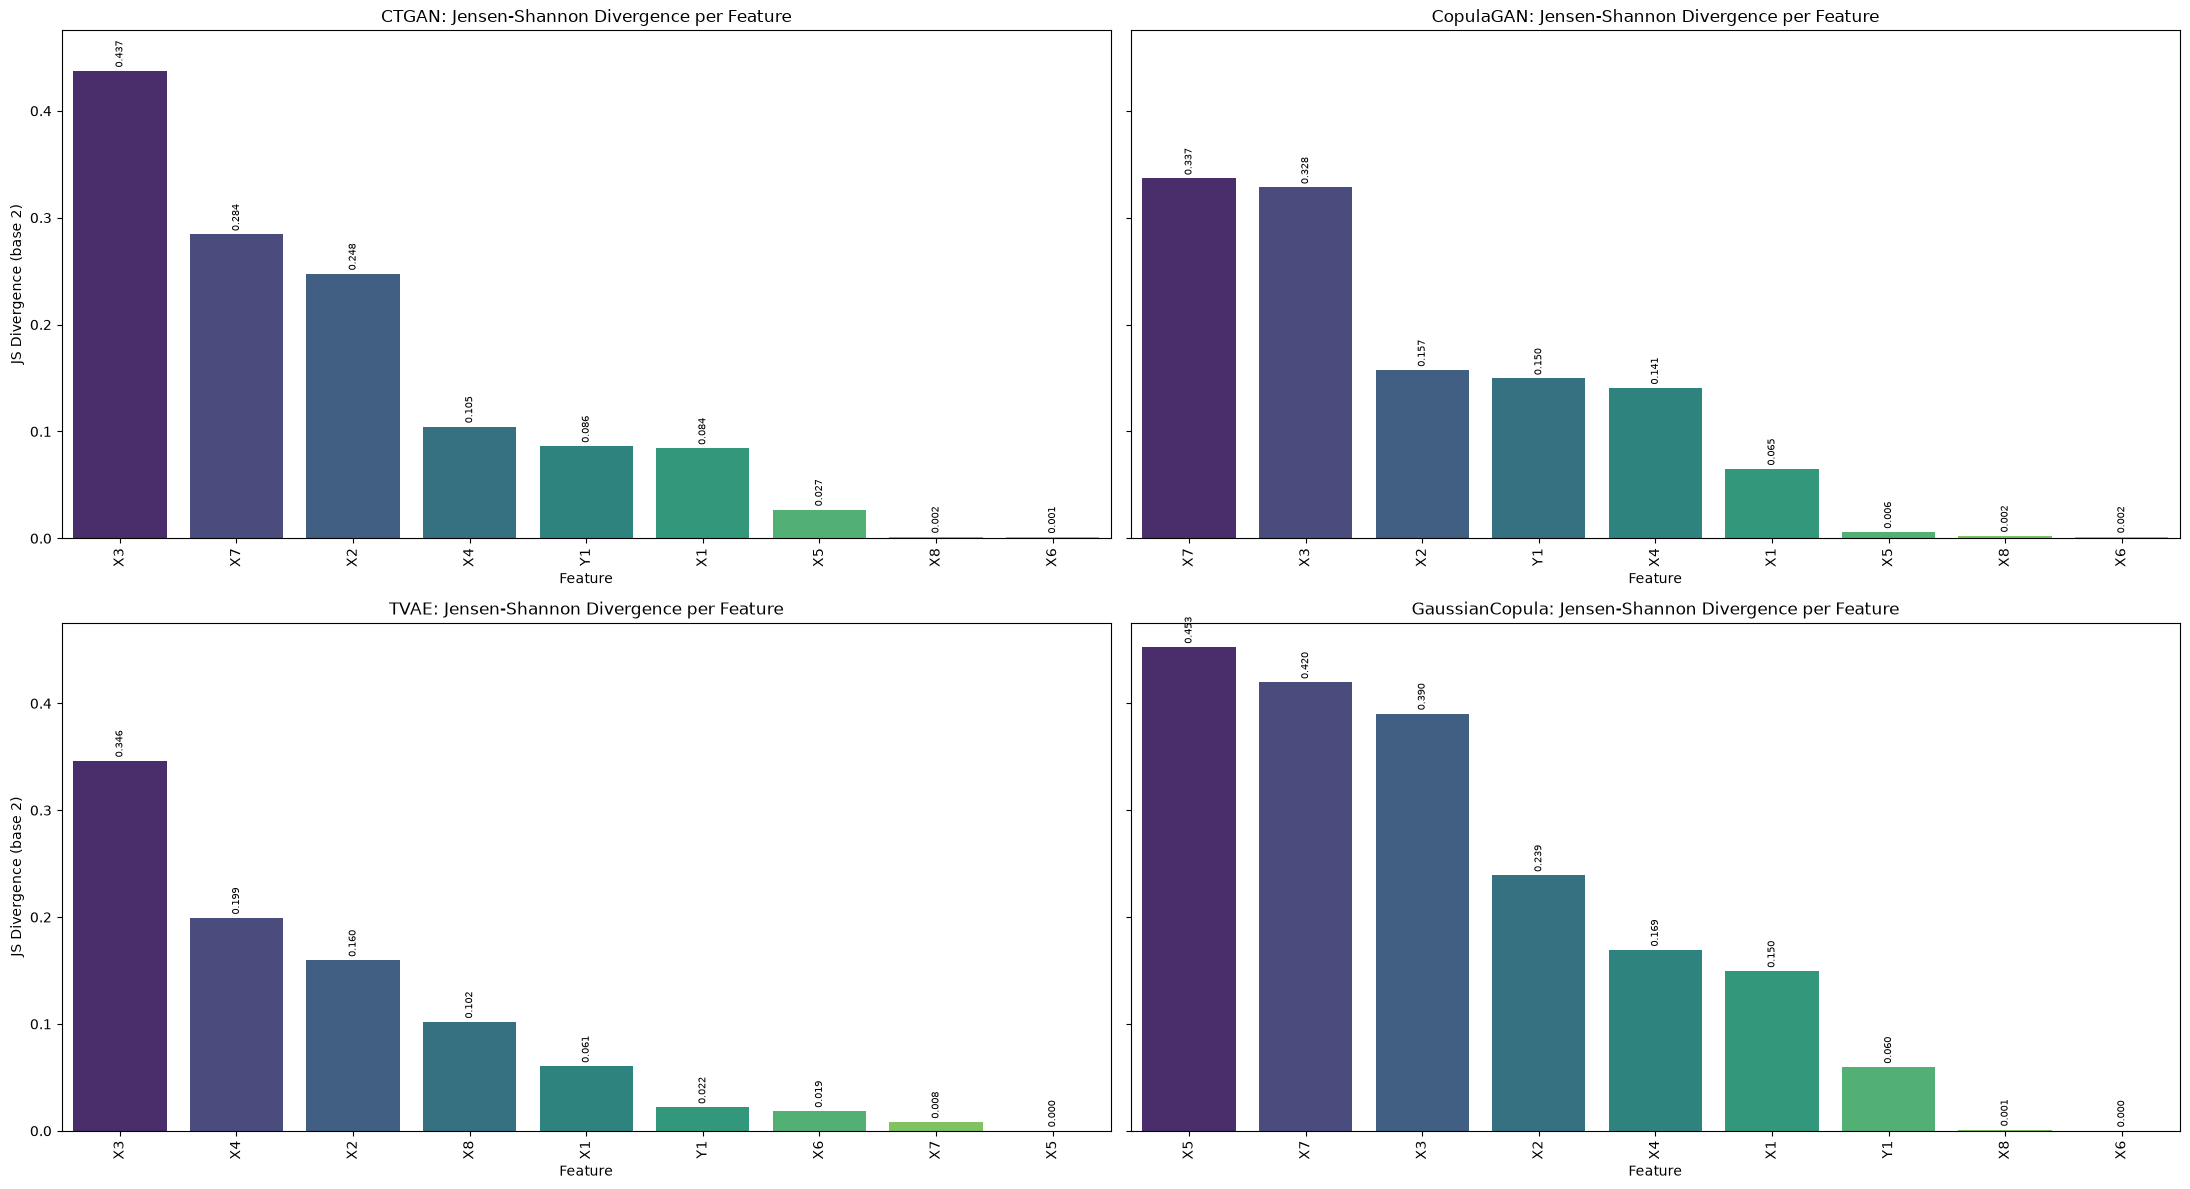

,Feature,JS_Divergence,Model
0,X3,0.437474,CTGAN
1,X7,0.284414,CTGAN
2,X2,0.247599,CTGAN
3,X4,0.104609,CTGAN
4,Y1,0.086296,CTGAN
5,X1,0.084338,CTGAN
6,X5,0.026856,CTGAN
7,X8,0.001540,CTGAN
8,X6,0.001324,CTGAN
9,X7,0.336755,CopulaGAN


In [6]:
import matplotlib.pyplot as plt, numpy as np
import seaborn as sns
import pandas as pd

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
js_results_by_model = {}

# Compute JS divergence for each model
for model_name in model_order:
    js_df = compute_js_divergence(
        data,
        synthetic_datasets[model_name],
        bins="fd",
        normalize=True
    ).sort_values("JS_Divergence", ascending=False)
    js_results_by_model[model_name] = js_df

# Plot all 4 models in one figure (2x2)
fig, axes = plt.subplots(2, 2, figsize=(22, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    js_df = js_results_by_model[model_name]
    bars = sns.barplot(
        x="Feature",
        y="JS_Divergence",
        data=js_df,
        palette="viridis",
        ax=ax
    )

    # Add value labels
    for bar in bars.patches:
        yval = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            yval + 0.003,
            f"{yval:.3f}",
            ha="center",
            va="bottom",
            fontsize=7,
            rotation=90
        )

    ax.set_title(f"{model_name}: Jensen-Shannon Divergence per Feature")
    ax.set_xlabel("Feature")
    ax.set_ylabel("JS Divergence (base 2)")
    ax.tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

# Optional: combined table for quick comparison
all_js = pd.concat(
    [df.assign(Model=name) for name, df in js_results_by_model.items()],
    ignore_index=True
)
display(all_js.head(20))

### 1.3 Wasserstein Distance



CTGAN - Wasserstein Distance:
X1: 0.1001
X2: 0.2345
X3: 0.0609
X4: 0.1334
X5: 0.1982
X6: 0.0291
X7: 0.1088
X8: 0.0125
Y1: 0.0408

CopulaGAN - Wasserstein Distance:
X1: 0.1191
X2: 0.1109
X3: 0.1388
X4: 0.0622
X5: 0.0898
X6: 0.0299
X7: 0.1518
X8: 0.0229
Y1: 0.1587

TVAE - Wasserstein Distance:
X1: 0.0272
X2: 0.0246
X3: 0.0580
X4: 0.0513
X5: 0.0182
X6: 0.0755
X7: 0.0261
X8: 0.1891
Y1: 0.0299

GaussianCopula - Wasserstein Distance:
X1: 0.1908
X2: 0.0474
X3: 0.0849
X4: 0.0835
X5: 0.2422
X6: 0.0039
X7: 0.0969
X8: 0.0182
Y1: 0.0344

Model summary (lower is better):


,Model,Mean_Wasserstein,Median_Wasserstein,Max_Wasserstein
0,TVAE,0.055541,0.029869,0.189062
1,GaussianCopula,0.089152,0.083513,0.242225
2,CopulaGAN,0.098246,0.110857,0.158688
3,CTGAN,0.102021,0.100116,0.234485


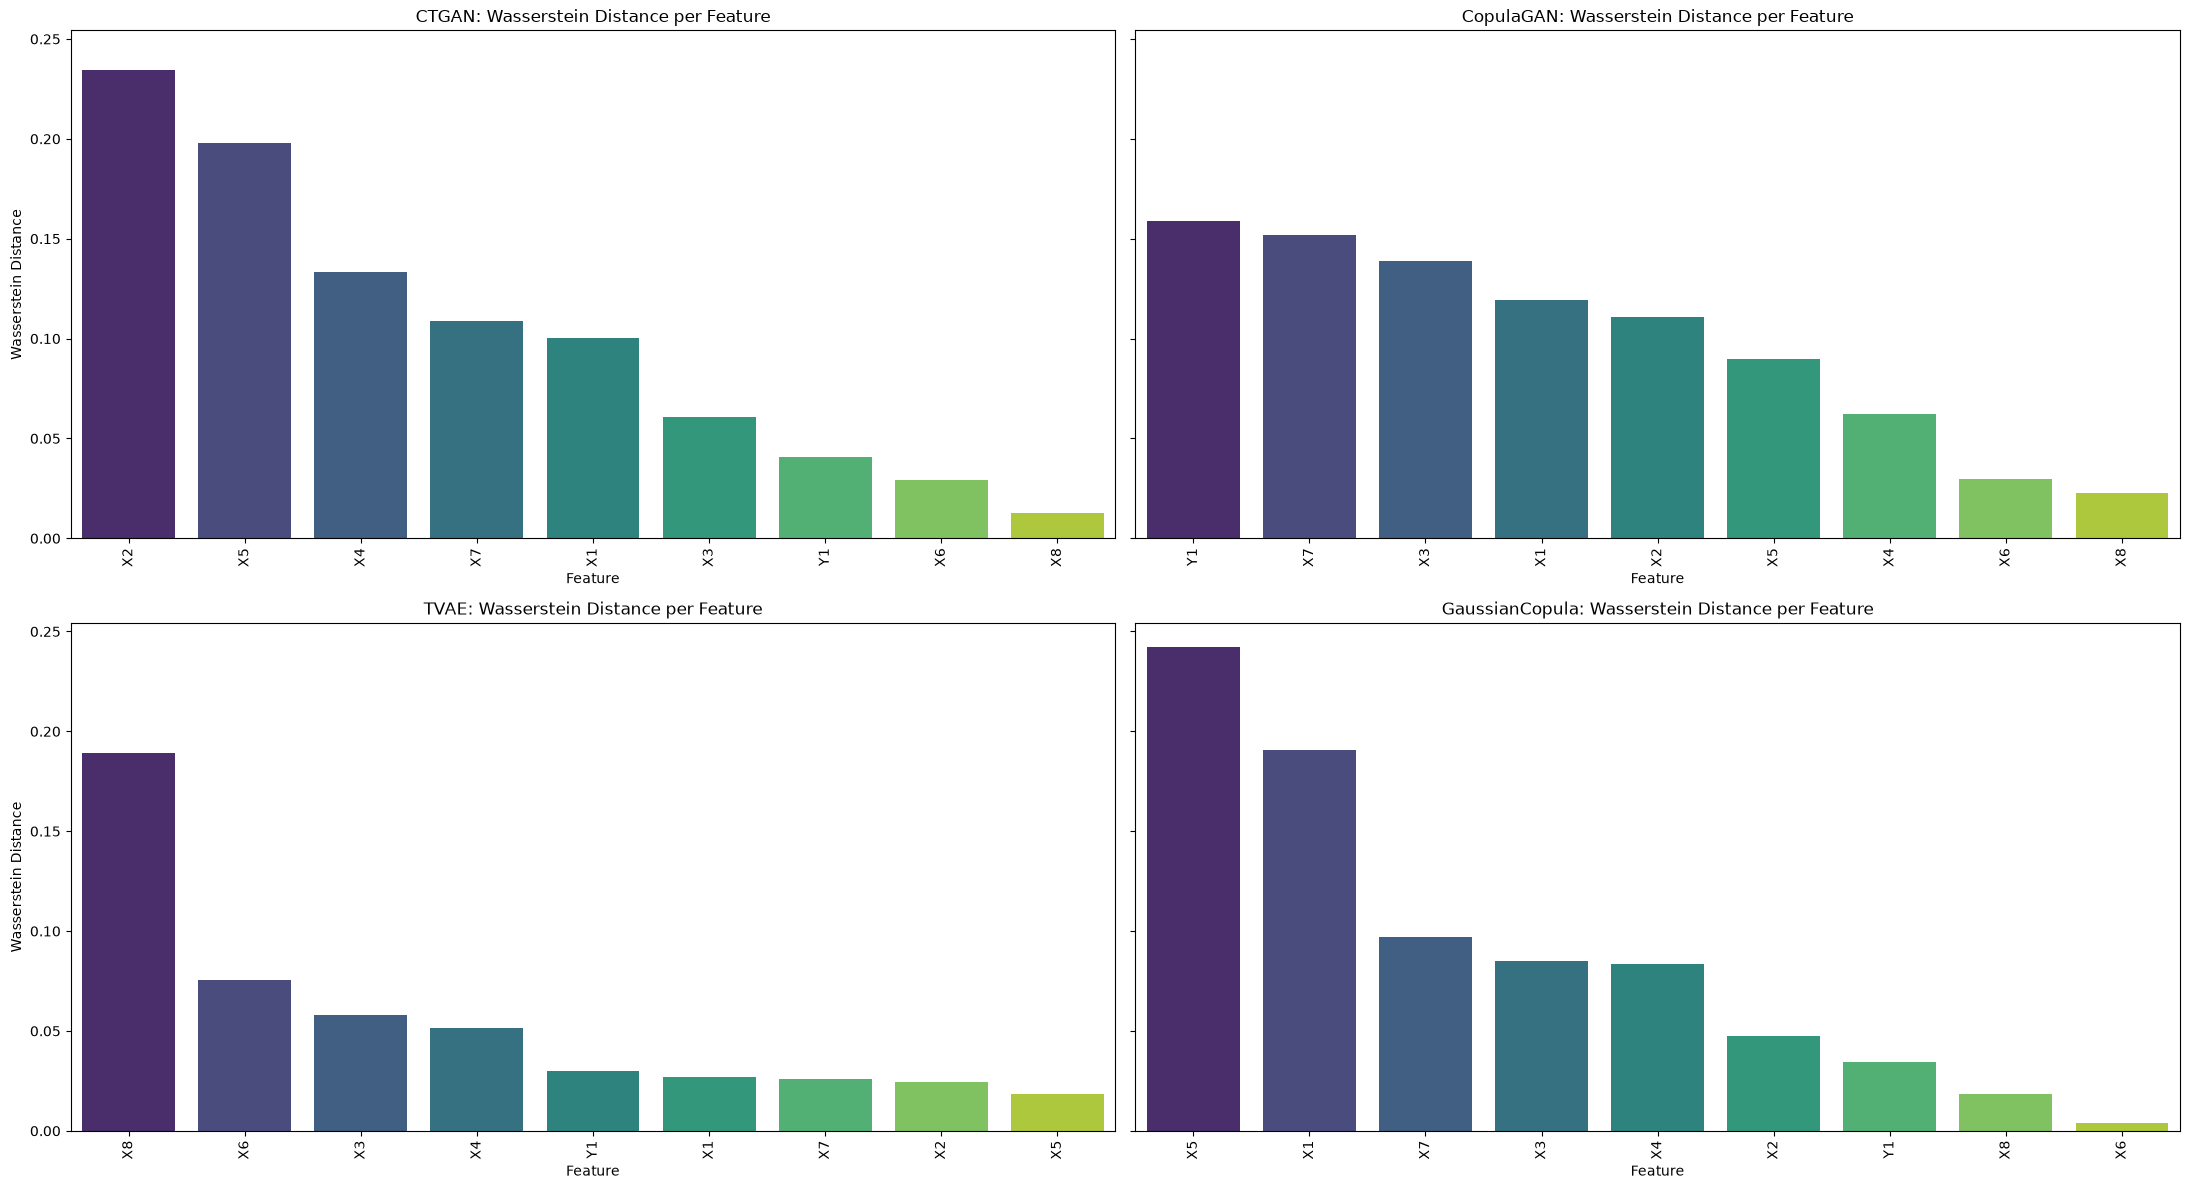

In [7]:
from scipy.stats import wasserstein_distance
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assumes these already exist:
# - data
# - synthetic_datasets dict with keys:
#   "CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

# Scale real data once
scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(data),
    columns=data.columns
)

wasserstein_by_model = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name]

    # Ensure same column order as real data
    synth_df = synth_df[data.columns]

    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_df),
        columns=synth_df.columns
    )

    dists = []
    print(f"\n{model_name} - Wasserstein Distance:")
    for col in data.columns:
        dist = wasserstein_distance(real_scaled[col], synthetic_scaled[col])
        dists.append((col, dist))
        print(f"{col}: {dist:.4f}")

    dist_df = pd.DataFrame(dists, columns=["Feature", "Wasserstein_Distance"]).sort_values(
        "Wasserstein_Distance", ascending=False
    )
    wasserstein_by_model[model_name] = dist_df

    summary_rows.append({
        "Model": model_name,
        "Mean_Wasserstein": dist_df["Wasserstein_Distance"].mean(),
        "Median_Wasserstein": dist_df["Wasserstein_Distance"].median(),
        "Max_Wasserstein": dist_df["Wasserstein_Distance"].max(),
    })

# Summary table (lower is better)
summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Wasserstein").reset_index(drop=True)
print("\nModel summary (lower is better):")
display(summary_df)

# Plot all 4 models in one figure
fig, axes = plt.subplots(2, 2, figsize=(22, 12), sharey=True)
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    df_plot = wasserstein_by_model[model_name]
    sns.barplot(
        x="Feature",
        y="Wasserstein_Distance",
        data=df_plot,
        palette="viridis",
        ax=ax
    )
    ax.set_title(f"{model_name}: Wasserstein Distance per Feature")
    ax.tick_params(axis="x", rotation=90)
    ax.set_xlabel("Feature")
    ax.set_ylabel("Wasserstein Distance")

plt.tight_layout()
plt.show()

### 1.4 Gower Distance

In [8]:
import numpy as np
import pandas as pd
import gower

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "Y1"
id_col = "ID"
drop_cols = [c for c in [id_col, target_col] if c in data.columns]

X_real = data.drop(columns=drop_cols, errors="ignore").copy()

gower_results = []

for model_name in model_order:
    X_synth = synthetic_datasets[model_name].drop(columns=drop_cols, errors="ignore").copy()

    common_cols = X_real.columns.intersection(X_synth.columns)
    Xr = X_real[common_cols].reset_index(drop=True).copy()
    Xs = X_synth[common_cols].reset_index(drop=True).copy()

    num_cols = Xr.select_dtypes(include=[np.number]).columns
    Xr[num_cols] = Xr[num_cols].astype(np.float64)
    Xs[num_cols] = Xs[num_cols].astype(np.float64)

    gower_real = 1.0 - gower.gower_matrix(Xr)
    gower_synth = 1.0 - gower.gower_matrix(Xs)

    real_upper = gower_real[np.triu_indices_from(gower_real, k=1)]
    synth_upper = gower_synth[np.triu_indices_from(gower_synth, k=1)]

    max_intra_real = float(np.max(real_upper))
    avg_intra_real = float(np.mean(real_upper))
    max_intra_synth = float(np.max(synth_upper))
    avg_intra_synth = float(np.mean(synth_upper))

    combined = pd.concat([Xr, Xs], axis=0, ignore_index=True)
    gower_combined = 1.0 - gower.gower_matrix(combined)
    n_real = len(Xr)
    cross_block = gower_combined[:n_real, n_real:]

    max_cross = float(np.max(cross_block))
    avg_cross = float(np.mean(cross_block))

    print(f"\n{model_name} - Gower Similarity:")
    print("Intra-set Similarity (Real):")
    print(f"Max = {max_intra_real:.4f}, Avg = {avg_intra_real:.4f}\n")
    print("Intra-set Similarity (Synthetic):")
    print(f"Max = {max_intra_synth:.4f}, Avg = {avg_intra_synth:.4f}\n")
    print("Cross-set Similarity (Real vs Synthetic):")
    print(f"Max = {max_cross:.4f}, Avg = {avg_cross:.4f}")

    gower_results.append({
        "Model": model_name,
        "Max_Intra_Real": max_intra_real,
        "Avg_Intra_Real": avg_intra_real,
        "Max_Intra_Synth": max_intra_synth,
        "Avg_Intra_Synth": avg_intra_synth,
        "Max_Cross_Real_vs_Synth": max_cross,
        "Avg_Cross_Real_vs_Synth": avg_cross,
    })

gower_summary_df = pd.DataFrame(gower_results)
display(gower_summary_df)



CTGAN - Gower Similarity:
Intra-set Similarity (Real):
Max = 0.9750, Avg = 0.6218

Intra-set Similarity (Synthetic):
Max = 1.0000, Avg = 0.6527

Cross-set Similarity (Real vs Synthetic):
Max = 0.9823, Avg = 0.6177

CopulaGAN - Gower Similarity:
Intra-set Similarity (Real):
Max = 0.9750, Avg = 0.6218

Intra-set Similarity (Synthetic):
Max = 0.9965, Avg = 0.5863

Cross-set Similarity (Real vs Synthetic):
Max = 0.9974, Avg = 0.5960

TVAE - Gower Similarity:
Intra-set Similarity (Real):
Max = 0.9750, Avg = 0.6218

Intra-set Similarity (Synthetic):
Max = 0.9994, Avg = 0.6500

Cross-set Similarity (Real vs Synthetic):
Max = 0.9997, Avg = 0.6282

GaussianCopula - Gower Similarity:
Intra-set Similarity (Real):
Max = 0.9750, Avg = 0.6218

Intra-set Similarity (Synthetic):
Max = 0.9875, Avg = 0.6335

Cross-set Similarity (Real vs Synthetic):
Max = 0.9944, Avg = 0.6112


,Model,Max_Intra_Real,Avg_Intra_Real,Max_Intra_Synth,Avg_Intra_Synth,Max_Cross_Real_vs_Synth,Avg_Cross_Real_vs_Synth
0,CTGAN,0.975,0.621784,1.000000,0.652744,0.982263,0.617680
1,CopulaGAN,0.975,0.621784,0.996528,0.586278,0.997449,0.595962
2,TVAE,0.975,0.621784,0.999394,0.649972,0.999730,0.628166
3,GaussianCopula,0.975,0.621784,0.987469,0.633526,0.994427,0.611222


### 1.5 t-SNE Visualization


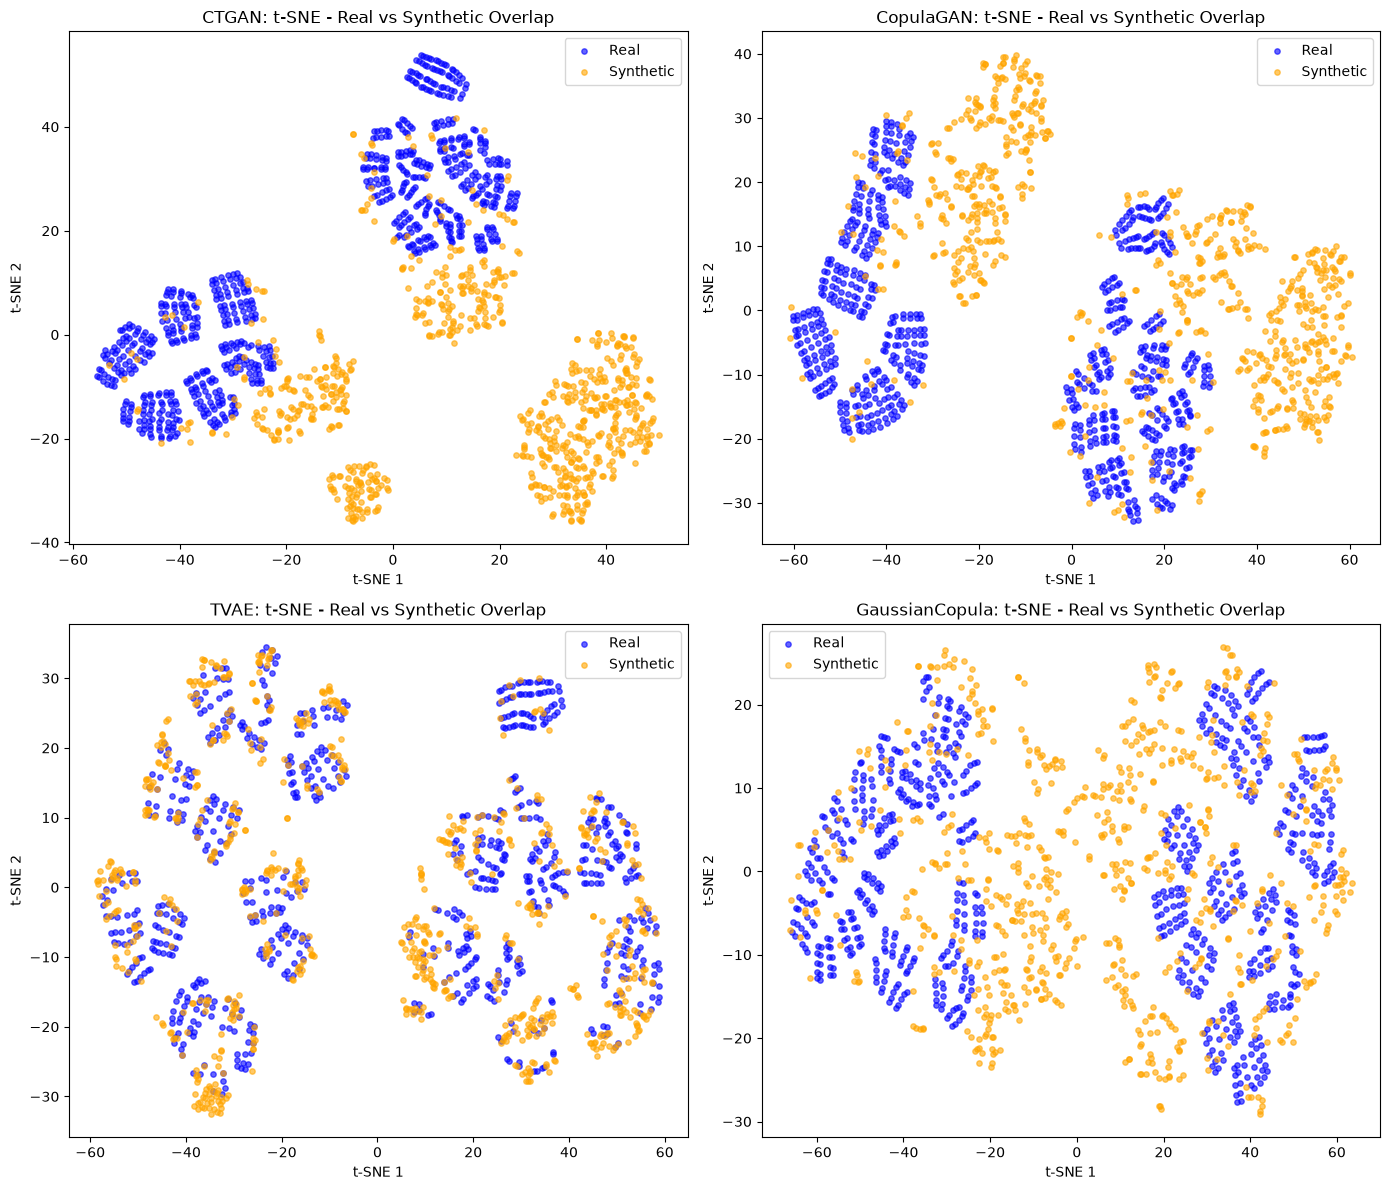

In [9]:
from sklearn.manifold import TSNE
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assumes:
# - data
# - synthetic_datasets dict with keys:
#   "CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

# Scale real data once
scaler = MinMaxScaler()
real_scaled = pd.DataFrame(
    scaler.fit_transform(data),
    columns=data.columns
)

# Create 2x2 t-SNE plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for ax, model_name in zip(axes, model_order):
    synth_df = synthetic_datasets[model_name][data.columns]

    synthetic_scaled = pd.DataFrame(
        scaler.transform(synth_df),
        columns=synth_df.columns
    )

    combined = np.vstack([real_scaled.values, synthetic_scaled.values])
    labels = np.array(["Real"] * len(real_scaled) + ["Synthetic"] * len(synthetic_scaled))

    tsne = TSNE(n_components=2, random_state=42)
    tsne_result = tsne.fit_transform(combined)

    ax.scatter(
        tsne_result[labels == "Real", 0],
        tsne_result[labels == "Real", 1],
        c="blue", alpha=0.6, s=15, label="Real"
    )
    ax.scatter(
        tsne_result[labels == "Synthetic", 0],
        tsne_result[labels == "Synthetic", 1],
        c="orange", alpha=0.6, s=15, label="Synthetic"
    )

    ax.set_title(f"{model_name}: t-SNE - Real vs Synthetic Overlap")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
    ax.legend()

plt.tight_layout()
plt.show()

### 1.6 MMD (Maximum Mean Discrepancy)


In [10]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel

def _sample_rows(X, max_rows=2000, seed=42):
    if X.shape[0] <= max_rows:
        return X
    rng = np.random.default_rng(seed)
    idx = rng.choice(X.shape[0], size=max_rows, replace=False)
    return X[idx]

def _median_gamma(X, Y):
    Z = np.vstack([X, Y])
    n = Z.shape[0]
    take = min(1200, n)
    idx = np.random.default_rng(42).choice(n, size=take, replace=False)
    Zs = Z[idx]
    d2 = np.sum((Zs[:, None, :] - Zs[None, :, :]) ** 2, axis=2)
    vals = d2[np.triu_indices_from(d2, k=1)]
    med = np.median(vals[vals > 0]) if np.any(vals > 0) else 1.0
    return 1.0 / (2.0 * med)

def compute_mmd_rbf_safe(X, Y, gamma=None):
    if gamma is None:
        gamma = _median_gamma(X, Y)
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    return float(Kxx.mean() + Kyy.mean() - 2.0 * Kxy.mean())

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "Y1"
id_col = None
drop_cols = [c for c in [id_col, target_col] if c is not None and c in data.columns]

real_features = data.drop(columns=drop_cols, errors="ignore").copy()
mmd_results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_features = synth_df.drop(columns=drop_cols, errors="ignore").copy()

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols].to_numpy(dtype=np.float64)
    X_synth = synth_features[common_cols].to_numpy(dtype=np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    Xr = _sample_rows(X_real_scaled, max_rows=2000, seed=42)
    Xs = _sample_rows(X_synth_scaled, max_rows=2000, seed=42)

    mmd_score = compute_mmd_rbf_safe(Xr, Xs, gamma=None)
    mmd_results.append({"Model": model_name, "MMD_Score": mmd_score})

    print(f"{model_name} - MMD score: {mmd_score:.6f}")

mmd_summary_df = pd.DataFrame(mmd_results).sort_values("MMD_Score").reset_index(drop=True)
print("\nMMD comparison (lower is better):")
display(mmd_summary_df)

CTGAN - MMD score: 0.054927
CopulaGAN - MMD score: 0.031800
TVAE - MMD score: 0.020381
GaussianCopula - MMD score: 0.024683

MMD comparison (lower is better):


,Model,MMD_Score
0,TVAE,0.020381
1,GaussianCopula,0.024683
2,CopulaGAN,0.031800
3,CTGAN,0.054927


### 1.7 Cosine Similarity


In [11]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "Y1"
id_col = None
drop_cols = [c for c in [id_col, target_col] if c is not None and c in data.columns]

real_features = data.drop(columns=drop_cols, errors="ignore").copy()
similarity_results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_features = synth_df.drop(columns=drop_cols, errors="ignore").copy()

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols].copy()
    X_synth = synth_features[common_cols].copy()

    if "color" in X_real.columns:
        X_real["color"] = X_real["color"].astype("category").cat.codes
        X_synth["color"] = X_synth["color"].astype("category").cat.codes

    X_real = X_real.apply(pd.to_numeric, errors="coerce").fillna(0).to_numpy(dtype=np.float64)
    X_synth = X_synth.apply(pd.to_numeric, errors="coerce").fillna(0).to_numpy(dtype=np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    cross_sim = cosine_similarity(X_real_scaled, X_synth_scaled)
    avg_sim = float(np.mean(cross_sim))
    max_sim = float(np.max(cross_sim))

    print(f"\n{model_name} - Sample-Level Similarity:")
    print(f"Average cosine similarity: {avg_sim:.4f}")
    print(f"Maximum cosine similarity: {max_sim:.4f}")

    similarity_results.append({
        "Model": model_name,
        "Average_Cosine_Similarity": avg_sim,
        "Maximum_Cosine_Similarity": max_sim
    })

similarity_summary_df = pd.DataFrame(similarity_results).sort_values(
    "Average_Cosine_Similarity", ascending=False
).reset_index(drop=True)

print("\nCosine similarity comparison (higher means more similar):")
display(similarity_summary_df)


CTGAN - Sample-Level Similarity:
Average cosine similarity: 0.0026
Maximum cosine similarity: 0.9934

CopulaGAN - Sample-Level Similarity:
Average cosine similarity: -0.0015
Maximum cosine similarity: 0.9997

TVAE - Sample-Level Similarity:
Average cosine similarity: 0.0028
Maximum cosine similarity: 1.0000

GaussianCopula - Sample-Level Similarity:
Average cosine similarity: 0.0012
Maximum cosine similarity: 0.9995

Cosine similarity comparison (higher means more similar):


,Model,Average_Cosine_Similarity,Maximum_Cosine_Similarity
0,TVAE,0.002820,0.999999
1,CTGAN,0.002569,0.993406
2,GaussianCopula,0.001194,0.999539
3,CopulaGAN,-0.001534,0.999725


### 1.8 Nearest Neighbours 


In [12]:
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

target_col = "Y1"
id_col = None
drop_cols = [c for c in [id_col, target_col] if c is not None and c in data.columns]

real_features = data.drop(columns=drop_cols, errors="ignore").copy()
privacy_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    synth_features = synth_df.drop(columns=drop_cols, errors="ignore").copy()

    common_cols = real_features.columns.intersection(synth_features.columns)
    X_real = real_features[common_cols].astype(np.float64)
    X_synth = synth_features[common_cols].astype(np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    nn = NearestNeighbors(n_neighbors=1).fit(X_real_scaled)
    distances, _ = nn.kneighbors(X_synth_scaled)

    avg_nn_dist = float(np.mean(distances))
    min_nn_dist = float(np.min(distances))
    p5_nn_dist = float(np.percentile(distances, 5))

    print(f"\n{model_name} - Privacy Check:")
    print(f"Average NN Distance (Synthetic -> Real): {avg_nn_dist:.4f}")
    print(f"Minimum NN Distance (Synthetic -> Real): {min_nn_dist:.4f}")
    print(f"5th Percentile NN Distance: {p5_nn_dist:.4f}")

    privacy_rows.append({
        "Model": model_name,
        "Avg_NN_Distance": avg_nn_dist,
        "Min_NN_Distance": min_nn_dist,
        "P5_NN_Distance": p5_nn_dist
    })

privacy_summary_df = pd.DataFrame(privacy_rows).sort_values(
    "Avg_NN_Distance", ascending=False
).reset_index(drop=True)

print("\nPrivacy distance summary (higher generally safer):")
display(privacy_summary_df)


CTGAN - Privacy Check:
Average NN Distance (Synthetic -> Real): 2.0249
Minimum NN Distance (Synthetic -> Real): 0.3212
5th Percentile NN Distance: 0.9278

CopulaGAN - Privacy Check:
Average NN Distance (Synthetic -> Real): 2.1947
Minimum NN Distance (Synthetic -> Real): 0.0803
5th Percentile NN Distance: 0.8923

TVAE - Privacy Check:
Average NN Distance (Synthetic -> Real): 0.6809
Minimum NN Distance (Synthetic -> Real): 0.0052
5th Percentile NN Distance: 0.1494

GaussianCopula - Privacy Check:
Average NN Distance (Synthetic -> Real): 1.3192
Minimum NN Distance (Synthetic -> Real): 0.0914
5th Percentile NN Distance: 0.6027

Privacy distance summary (higher generally safer):


,Model,Avg_NN_Distance,Min_NN_Distance,P5_NN_Distance
0,CopulaGAN,2.194717,0.080279,0.892302
1,CTGAN,2.024912,0.321208,0.927789
2,GaussianCopula,1.319213,0.091365,0.602716
3,TVAE,0.680908,0.005195,0.149393


Average error by model


,Model,Mean Error %,Median Error %,Std Error %
0,CTGAN,6.831319,5.423380,6.953187
1,CopulaGAN,6.337747,4.079192,10.726314
2,TVAE,6.569800,2.751480,6.650251
3,GaussianCopula,3.734944,2.341670,10.718952


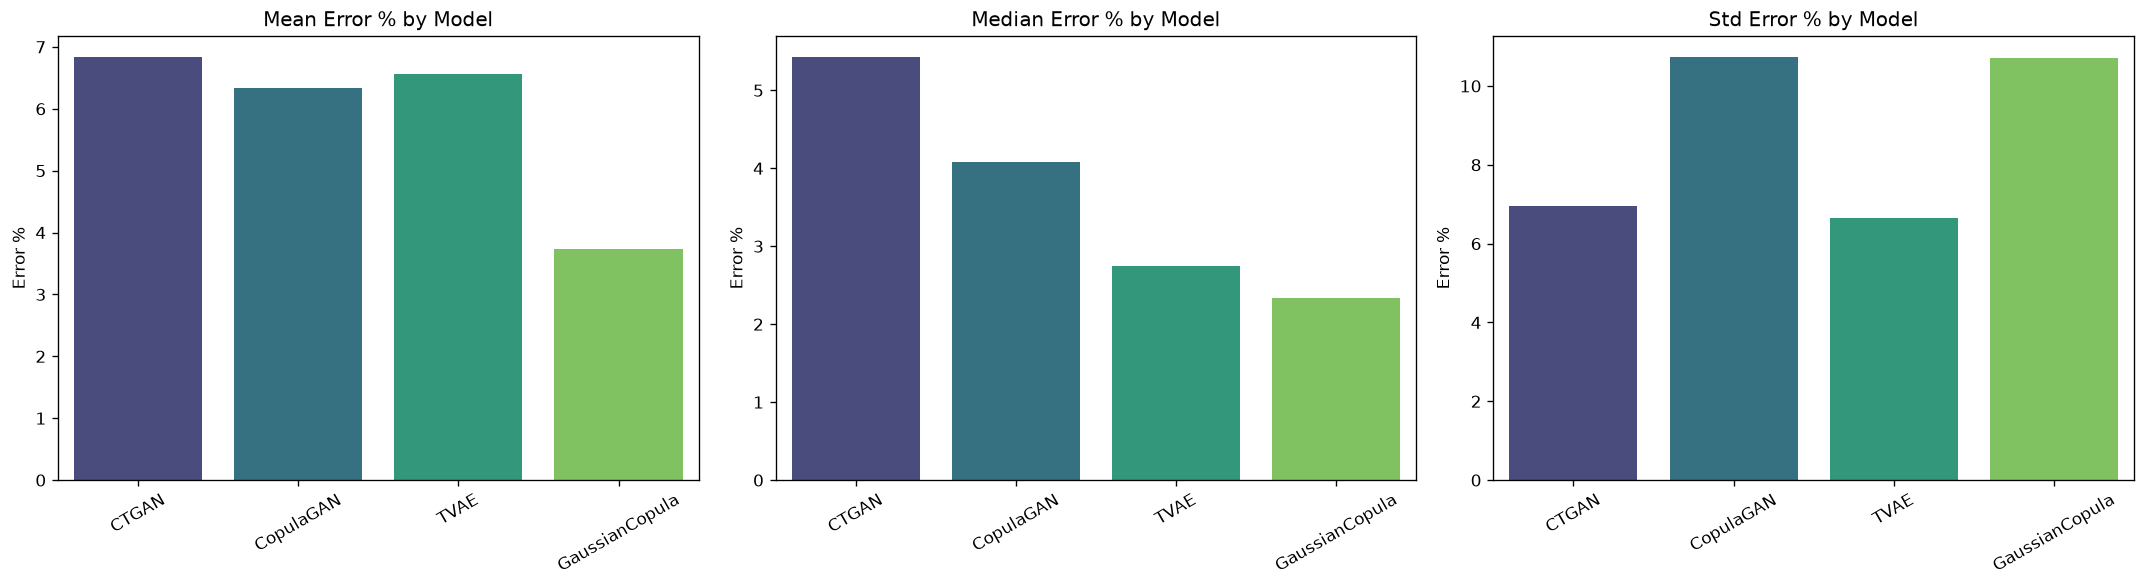

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()

drop_from_metrics = []
if "ID" in num_cols:
    drop_from_metrics.append("ID")
if target_col in num_cols:
    drop_from_metrics.append(target_col)

num_cols = [c for c in num_cols if c not in drop_from_metrics]

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]

    real_means = real_df[num_cols].astype(np.float64).mean()
    synth_means = synth_df[num_cols].astype(np.float64).mean()

    real_stds = real_df[num_cols].astype(np.float64).std(ddof=1)
    synth_stds = synth_df[num_cols].astype(np.float64).std(ddof=1)

    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100.0
    std_error_pct = (np.abs(synth_stds - real_stds) / real_stds.replace(0, np.nan).abs()) * 100.0

    feature_error_df = pd.DataFrame({
        "Feature": num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    }).replace([np.inf, -np.inf], np.nan)

    model_summary = {
        "Model": model_name,
        "Mean Error %": float(feature_error_df["Mean_Error_%"].mean(skipna=True)),
        "Median Error %": float(feature_error_df["Mean_Error_%"].median(skipna=True)),
        "Std Error %": float(feature_error_df["Std_Error_%"].mean(skipna=True))
    }

    summary_rows.append(model_summary)
    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index("Model").loc[model_order].reset_index()

print("Average error by model")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2], palette="viridis")
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()


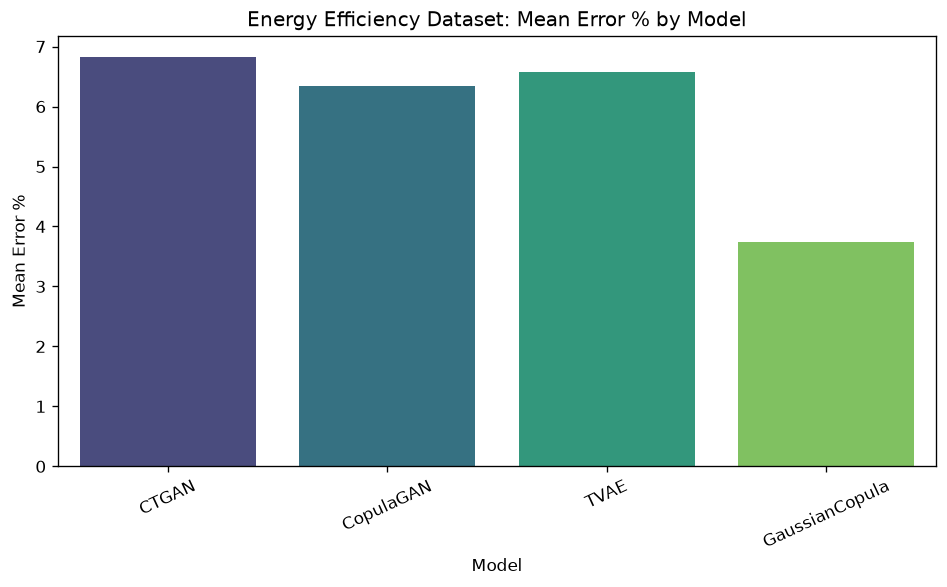

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_df = summary_df[["Model", "Mean Error %"]].copy()

plt.figure(figsize=(8, 5), dpi=120)
sns.barplot(data=plot_df, x="Model", y="Mean Error %", palette="viridis")
plt.title("Energy Efficiency Dataset: Mean Error % by Model")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

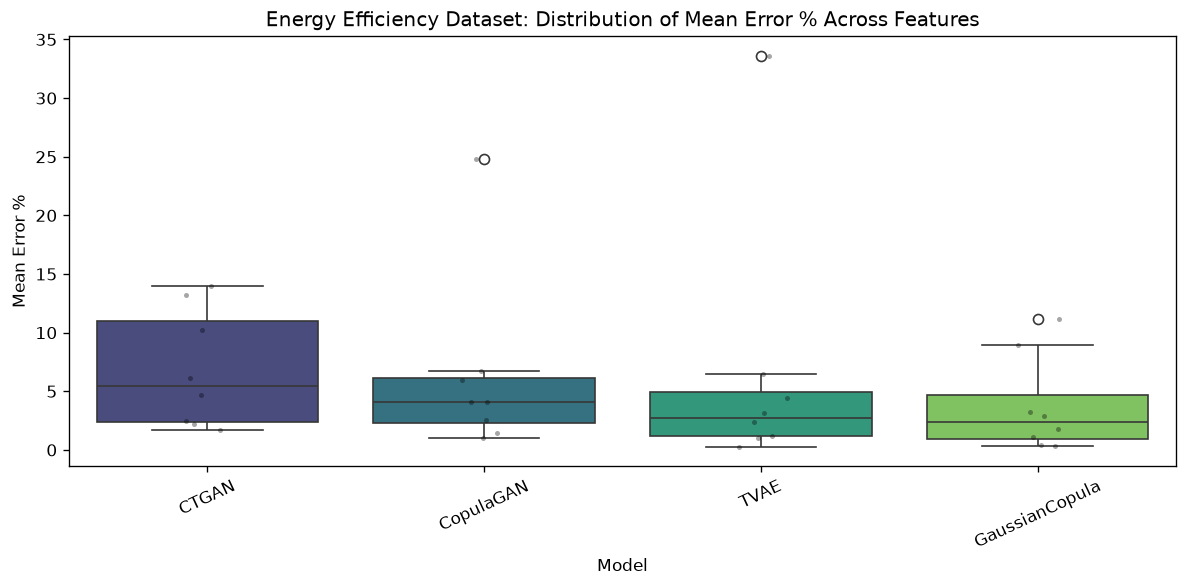

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dist_df = pd.concat(
    [
        feature_error_by_model[m][["Feature", "Mean_Error_%"]].assign(Model=m)
        for m in ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
    ],
    ignore_index=True
).replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["Mean_Error_%"])

plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=dist_df, x="Model", y="Mean_Error_%", palette="viridis")
sns.stripplot(data=dist_df, x="Model", y="Mean_Error_%", color="black", alpha=0.35, size=3)
plt.title("Energy Efficiency Dataset: Distribution of Mean Error % Across Features")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

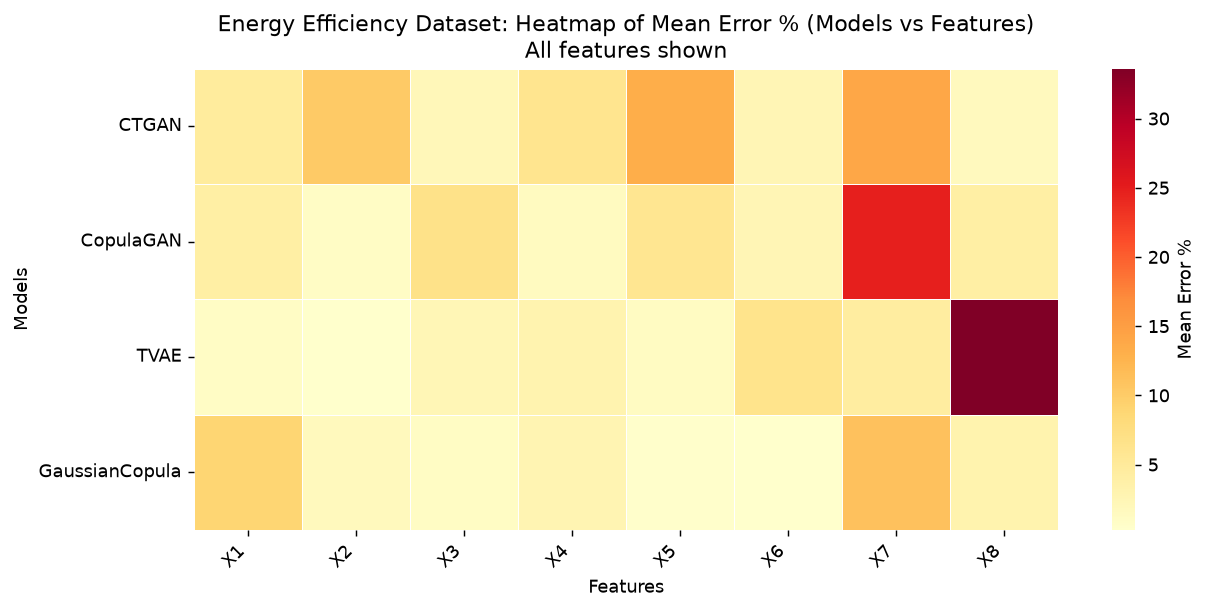

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = heatmap_df.mean(axis=0, skipna=True).sort_values(ascending=False).head(max_features).index
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(f"Energy Efficiency Dataset: Heatmap of Mean Error % (Models vs Features)\n{truncated_note}")
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 2 Bivariate Analysis


In [17]:
from itertools import combinations
from scipy import stats
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

def bivariate_quality_regression(real_df, synth_df, target="Y1", id_col=None):
    num_cols = real_df.select_dtypes(include=["number"]).columns.tolist()
    num_cols = [c for c in num_cols if c not in [target, id_col] if c is not None]

    scaler = MinMaxScaler()

    real_scaled = real_df.copy()
    synth_scaled = synth_df.copy()

    real_scaled[num_cols] = scaler.fit_transform(real_df[num_cols])
    synth_scaled[num_cols] = scaler.transform(synth_df[num_cols])

    results_corr = []
    results_target = []

    for a, b in combinations(num_cols, 2):
        r_corr = real_scaled[[a, b]].corr().iloc[0, 1]
        s_corr = synth_scaled[[a, b]].corr().iloc[0, 1]
        results_corr.append({
            "var_a": a,
            "var_b": b,
            "delta_corr": abs(r_corr - s_corr)
        })

    if target in real_scaled.columns and target in synth_scaled.columns:
        for col in num_cols:
            r_groups = [g[col].values for _, g in real_scaled.groupby(target)]
            s_groups = [g[col].values for _, g in synth_scaled.groupby(target)]

            if len(r_groups) == 2 and len(s_groups) == 2:
                d_real = stats.wasserstein_distance(*r_groups)
                d_synth = stats.wasserstein_distance(*s_groups)
                results_target.append({
                    "feature": col,
                    "delta_wasserstein": abs(d_real - d_synth)
                })

    corr_df = pd.DataFrame(results_corr).sort_values("delta_corr", ascending=False)
    target_df = pd.DataFrame(results_target).sort_values("delta_wasserstein", ascending=False) if results_target else pd.DataFrame(columns=["feature", "delta_wasserstein"])

    return corr_df, target_df


In [18]:
import pandas as pd

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
real_df = data.copy()

target_col = "Y1"
id_col = None

if "bivariate_quality_regression" in globals():
    quality_fn = bivariate_quality_regression
else:
    raise NameError("Define `bivariate_quality_regression` before running this cell.")

all_corr_results = {}
all_target_results = {}
summary_rows = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]

    real_eval = real_df.drop(columns=[id_col], errors="ignore")
    synth_eval = synth_df.drop(columns=[id_col], errors="ignore")

    corr_results, target_results = quality_fn(
        real_df=real_eval,
        synth_df=synth_eval
    )

    all_corr_results[model_name] = corr_results
    all_target_results[model_name] = target_results

    print(f"\n{model_name} - Largest differences in pairwise correlations:")
    display(corr_results.head(10))
    print("=" * 60)
    print(f"{model_name} - Features that differ most by {target_col} class:")
    display(target_results.head(10))
    print("=" * 60)

    corr_metric_col = next((c for c in ["delta_corr", "AbsDiff", "abs_diff", "Difference", "diff"] if c in corr_results.columns), None)
    target_metric_col = next((c for c in ["delta_wasserstein", "AbsDiff", "abs_diff", "Difference", "diff"] if c in target_results.columns), None)

    summary_rows.append({
        "Model": model_name,
        "TopCorrDiff": corr_results[corr_metric_col].iloc[0] if corr_metric_col and not corr_results.empty else None,
        "MeanTop10CorrDiff": corr_results[corr_metric_col].head(10).mean() if corr_metric_col and not corr_results.empty else None,
        "TopTargetDiff": target_results[target_metric_col].iloc[0] if target_metric_col and not target_results.empty else None,
        "MeanTop10TargetDiff": target_results[target_metric_col].head(10).mean() if target_metric_col and not target_results.empty else None,
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)



CTGAN - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
0,X1,X2,1.017860
18,X4,X5,0.973796
2,X1,X4,0.904480
9,X2,X5,0.842502
8,X2,X4,0.813052
3,X1,X5,0.811503
13,X3,X4,0.325694
14,X3,X5,0.301472
7,X2,X3,0.208619
1,X1,X3,0.200989


CTGAN - Features that differ most by Y1 class:


,feature,delta_wasserstein



CopulaGAN - Largest differences in pairwise correlations:


...


GaussianCopula - Largest differences in pairwise correlations:


,var_a,var_b,delta_corr
2,X1,X4,0.391368
3,X1,X5,0.321696
27,X7,X8,0.262017
9,X2,X5,0.230630
0,X1,X2,0.229575
18,X4,X5,0.172176
8,X2,X4,0.140365
1,X1,X3,0.101981
13,X3,X4,0.089420
16,X3,X7,0.083781


GaussianCopula - Features that differ most by Y1 class:


,feature,delta_wasserstein


,Model,TopCorrDiff,MeanTop10CorrDiff,TopTargetDiff,MeanTop10TargetDiff
0,CTGAN,1.017860,0.639997,None,None
1,CopulaGAN,0.991153,0.627340,None,None
2,TVAE,0.197171,0.118692,None,None
3,GaussianCopula,0.391368,0.202301,None,None


### 3 Multivariate Analysis


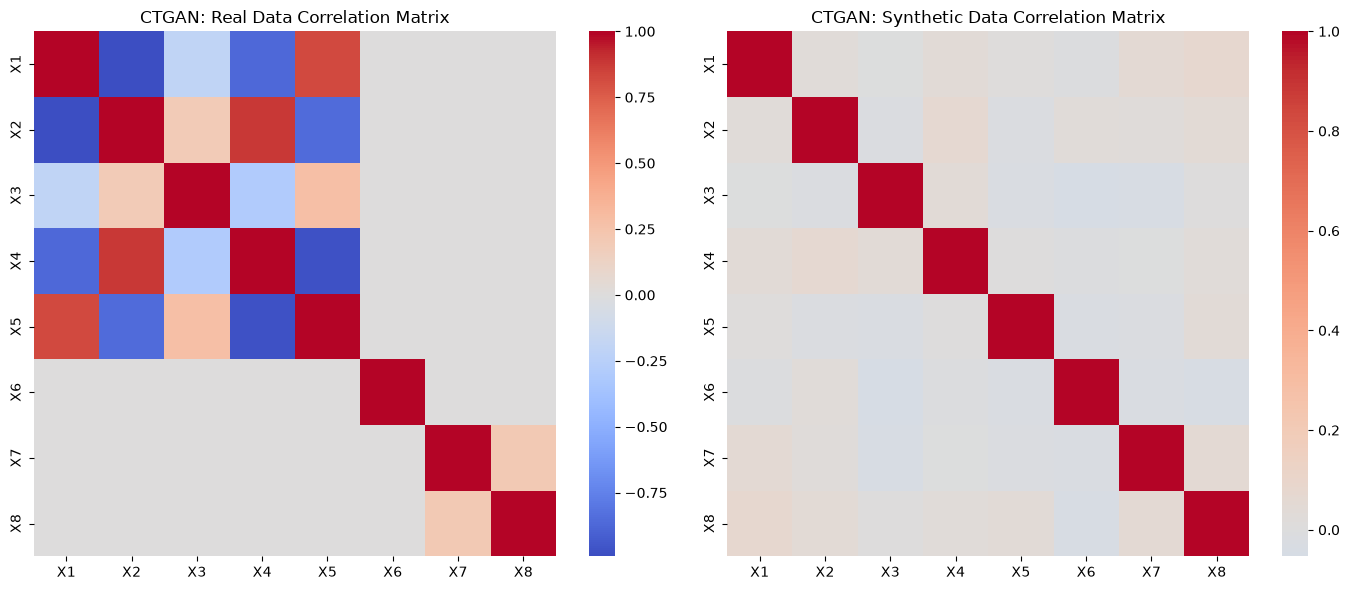

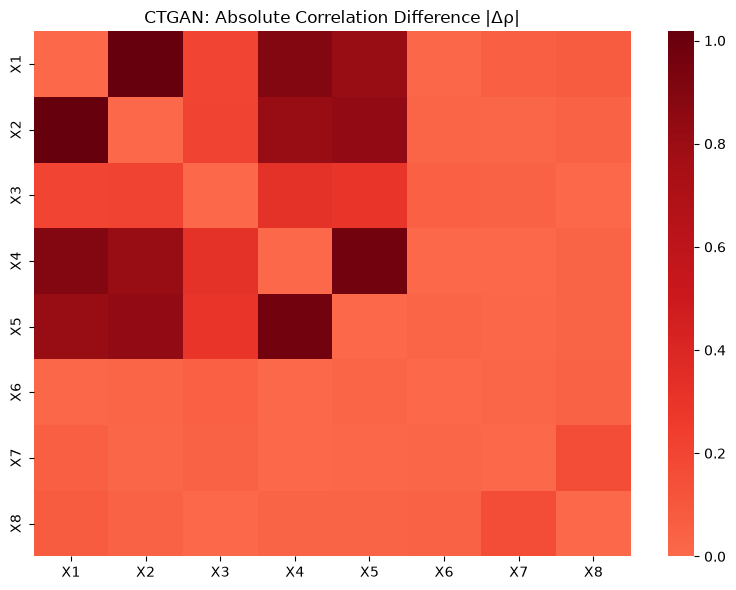

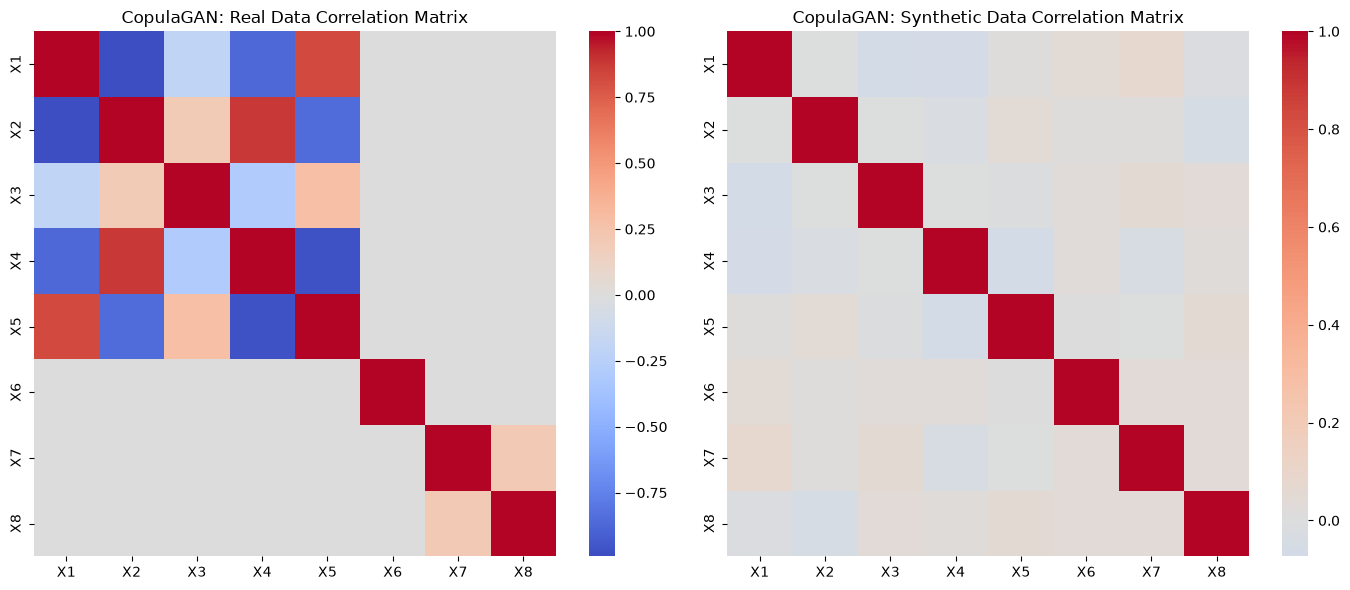

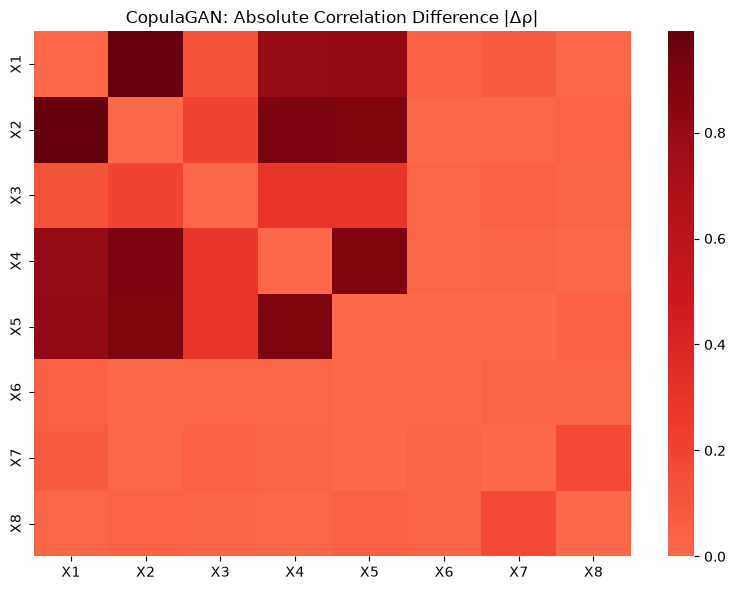

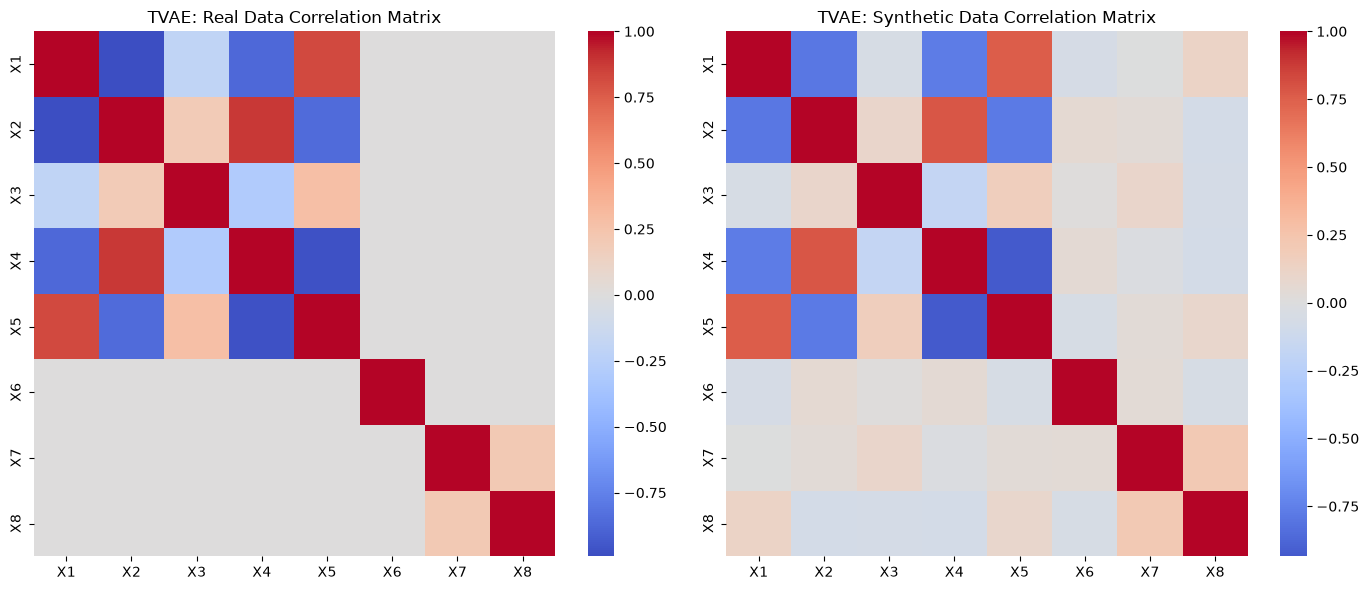

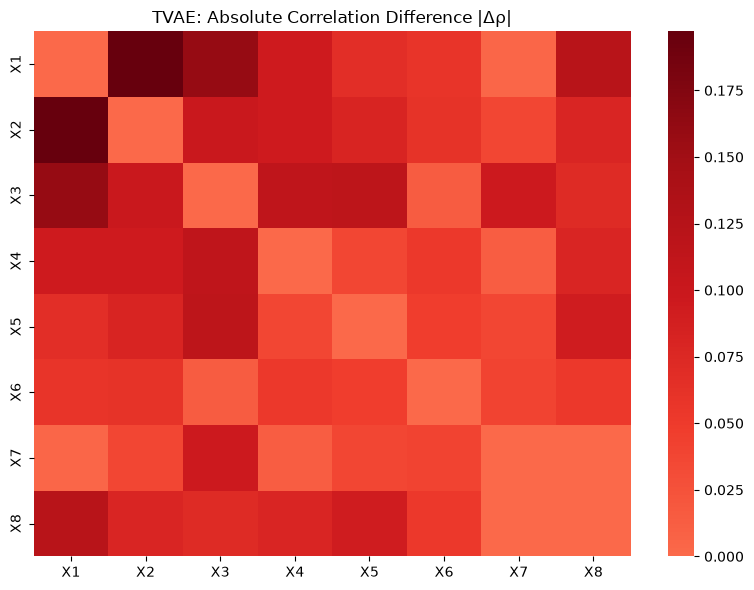

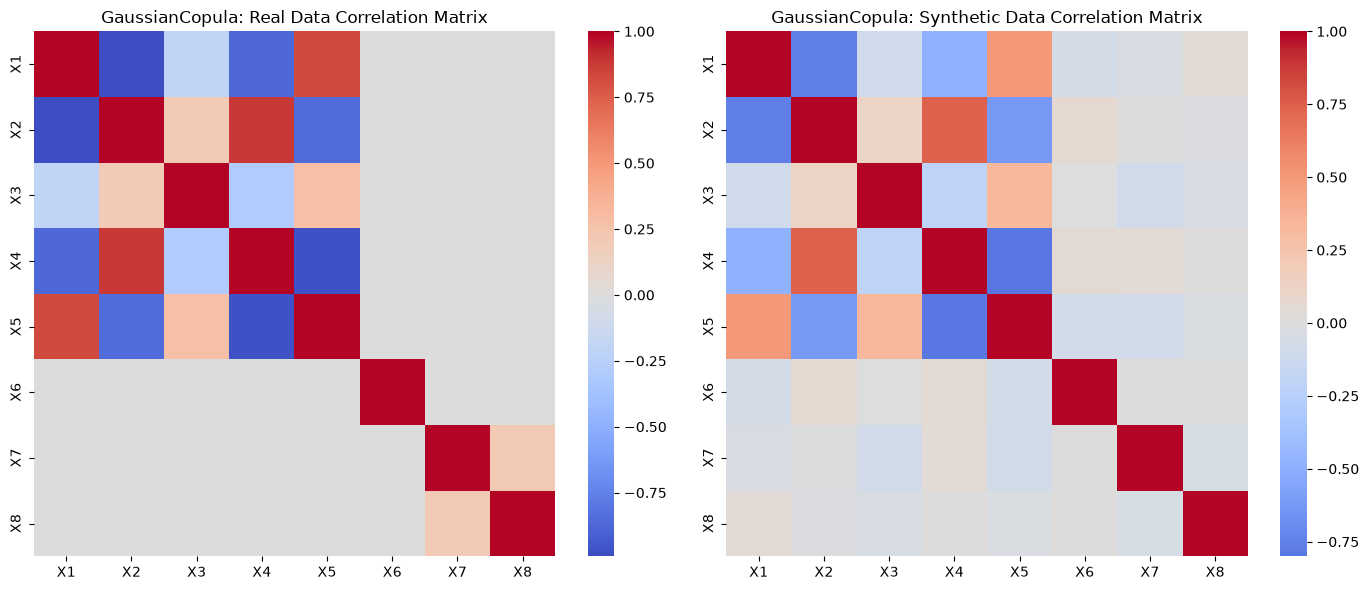

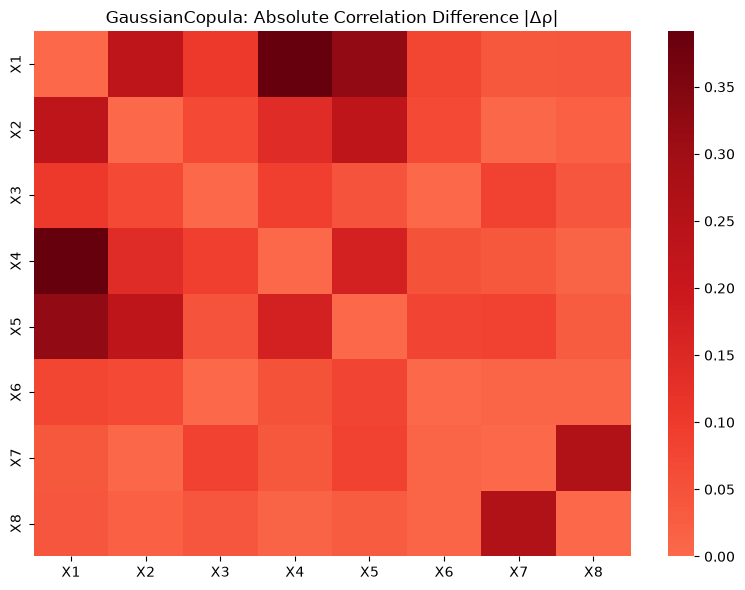

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = data.copy()
target_col = "Y1"
id_col = None

num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c not in [target_col, id_col] if c is not None]

real_corr = real_df[num_cols].corr()

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]
    synth_corr = synth_df[num_cols].corr()

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    sns.heatmap(real_corr, cmap="coolwarm", center=0, ax=axes[0])
    axes[0].set_title(f"{model_name}: Real Data Correlation Matrix")

    sns.heatmap(synth_corr, cmap="coolwarm", center=0, ax=axes[1])
    axes[1].set_title(f"{model_name}: Synthetic Data Correlation Matrix")

    plt.tight_layout()
    plt.show()

    diff_corr = (real_corr - synth_corr).abs()
    plt.figure(figsize=(8, 6))
    sns.heatmap(diff_corr, cmap="Reds", center=0)
    plt.title(f"{model_name}: Absolute Correlation Difference |Δρ|")
    plt.tight_layout()
    plt.show()



CTGAN - Global MMD (RBF): 0.054252


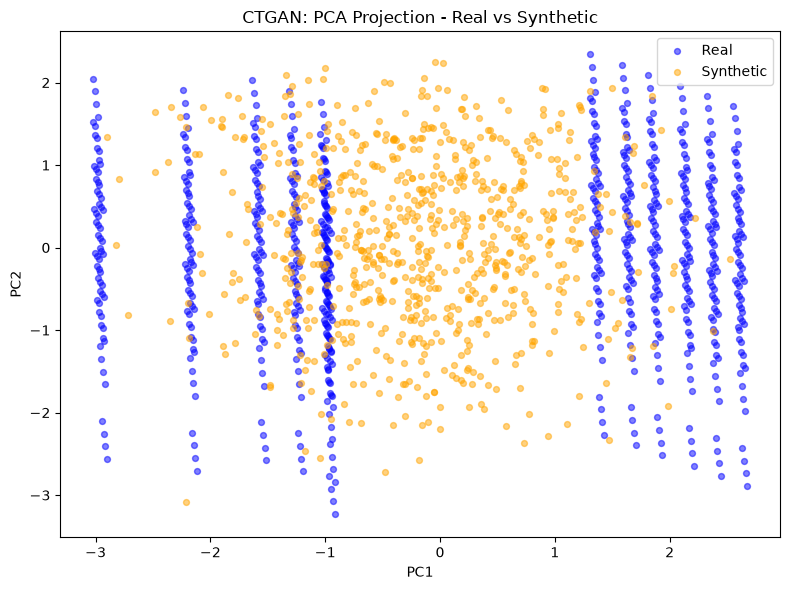

CTGAN - Two-Sample Classifier Accuracy: 0.9616

CopulaGAN - Global MMD (RBF): 0.030936


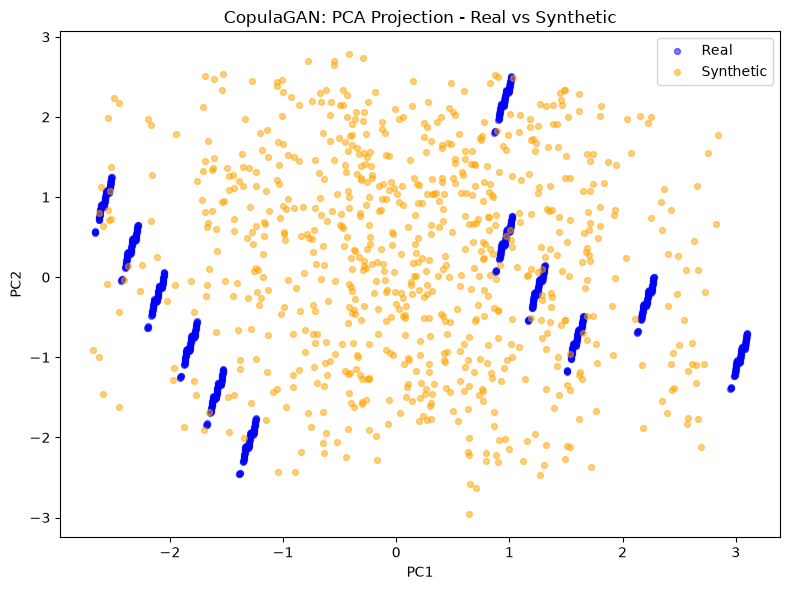

CopulaGAN - Two-Sample Classifier Accuracy: 0.9639

TVAE - Global MMD (RBF): 0.019390


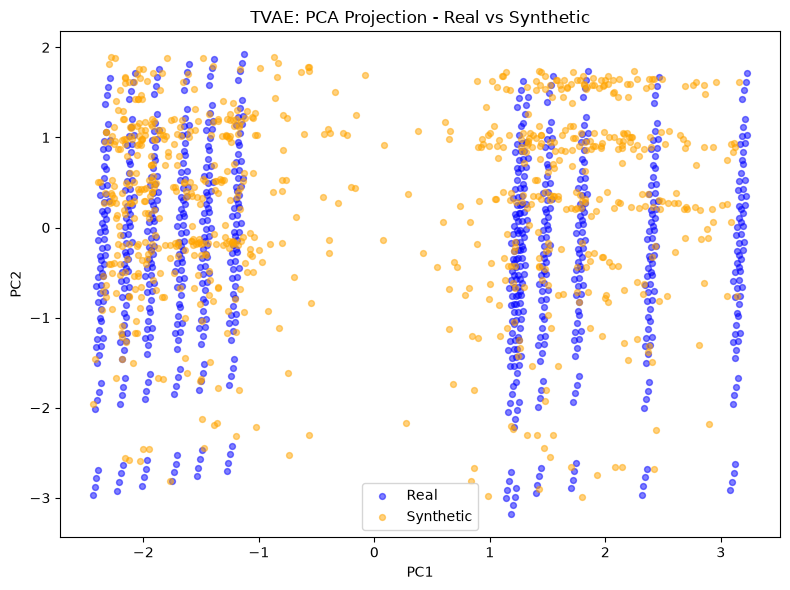

TVAE - Two-Sample Classifier Accuracy: 0.9259

GaussianCopula - Global MMD (RBF): 0.023690


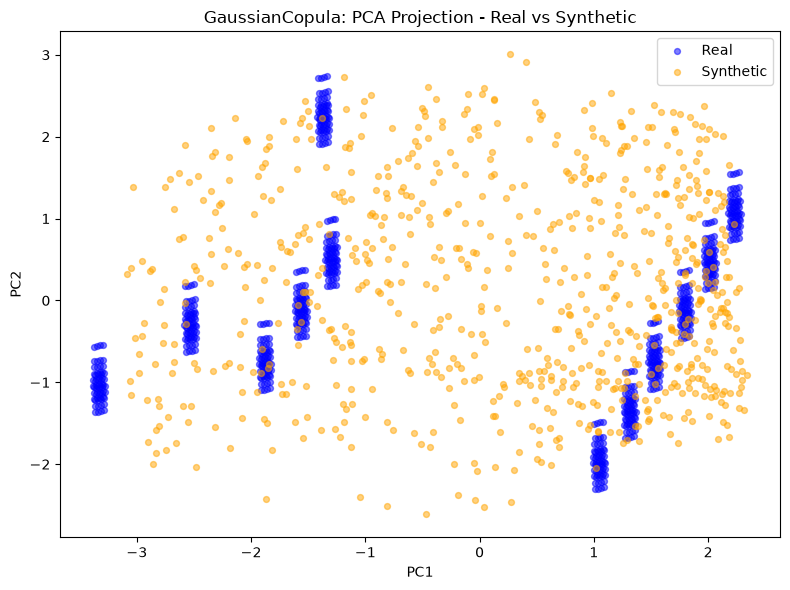

GaussianCopula - Two-Sample Classifier Accuracy: 0.9844

Summary (lower MMD and lower C2ST accuracy generally indicate better overlap):


,Model,Global_MMD_RBF,C2ST_Accuracy
0,TVAE,0.019390,0.925872
1,GaussianCopula,0.023690,0.984380
2,CopulaGAN,0.030936,0.963896
3,CTGAN,0.054252,0.961605


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score


def mmd_rbf(X, Y, gamma=None, gamma_sample_size=1500):
    if gamma is None:
        Z = np.vstack([X, Y])
        n = len(Z)
        k = min(gamma_sample_size, n)
        idx = np.random.default_rng(42).choice(n, size=k, replace=False)
        Zs = Z[idx]
        d2 = np.sum((Zs[:, None, :] - Zs[None, :, :]) ** 2, axis=2)
        vals = d2[np.triu_indices_from(d2, k=1)]
        med = np.median(vals[vals > 0]) if np.any(vals > 0) else 1.0
        gamma = 1.0 / (2.0 * med)

    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)
    n, m = len(X), len(Y)

    return ((Kxx.sum() - np.trace(Kxx)) / (n * (n - 1))
            + (Kyy.sum() - np.trace(Kyy)) / (m * (m - 1))
            - 2 * Kxy.mean())


model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
target_col = "Y1"
id_col = None
drop_cols = [c for c in [id_col, target_col] if c is not None and c in data.columns]

X_real_df = data.drop(columns=drop_cols, errors="ignore").copy()
results = []

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    X_synth_df = synth_df.drop(columns=drop_cols, errors="ignore").copy()

    common_cols = X_real_df.columns.intersection(X_synth_df.columns)
    X_real = X_real_df[common_cols].to_numpy(dtype=np.float64)
    X_synth = X_synth_df[common_cols].to_numpy(dtype=np.float64)

    scaler = StandardScaler()
    X_real_scaled = scaler.fit_transform(X_real)
    X_synth_scaled = scaler.transform(X_synth)

    mmd_value = mmd_rbf(X_real_scaled, X_synth_scaled)
    print(f"\n{model_name} - Global MMD (RBF): {mmd_value:.6f}")

    pca = PCA(n_components=2, random_state=42)
    X_all = np.vstack([X_real_scaled, X_synth_scaled])
    labels = np.array(["Real"] * len(X_real_scaled) + ["Synthetic"] * len(X_synth_scaled))
    X_pca = pca.fit_transform(X_all)

    plt.figure(figsize=(8, 6))
    plt.scatter(X_pca[labels == "Real", 0], X_pca[labels == "Real", 1],
                color="blue", alpha=0.5, label="Real", s=18)
    plt.scatter(X_pca[labels == "Synthetic", 0], X_pca[labels == "Synthetic", 1],
                color="orange", alpha=0.5, label="Synthetic", s=18)
    plt.title(f"{model_name}: PCA Projection - Real vs Synthetic")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.legend()
    plt.tight_layout()
    plt.show()

    y_real = np.ones(len(X_real_scaled))
    y_synth = np.zeros(len(X_synth_scaled))
    X_c2st = np.vstack([X_real_scaled, X_synth_scaled])
    y_c2st = np.hstack([y_real, y_synth])

    X_train, X_test, y_train, y_test = train_test_split(
        X_c2st, y_c2st, test_size=0.3, stratify=y_c2st, random_state=42
    )

    clf = RandomForestRegressor(n_estimators=200, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = r2_score(y_test, y_pred)

    print(f"{model_name} - Two-Sample Classifier Accuracy: {acc:.4f}")

    results.append({
        "Model": model_name,
        "Global_MMD_RBF": float(mmd_value),
        "C2ST_Accuracy": float(acc)
    })

results_df = pd.DataFrame(results).sort_values("Global_MMD_RBF").reset_index(drop=True)
print("\nSummary (lower MMD and lower C2ST accuracy generally indicate better overlap):")
display(results_df)


# 4 Utility with 10 regressors 


In [24]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.neural_network import MLPRegressor

models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(random_state=42),
    'Lasso': Lasso(random_state=42),
    'ElasticNet': ElasticNet(random_state=42),
    'SVR-RBF': SVR(kernel='rbf'),
    'KNN': KNeighborsRegressor(),
    'DecisionTree': DecisionTreeRegressor(random_state=42),
    'RandomForest': RandomForestRegressor(random_state=42),
    'ExtraTrees': ExtraTreesRegressor(random_state=42),
    'GradientBoost': GradientBoostingRegressor(random_state=42),
    'MLP': MLPRegressor(max_iter=2000, random_state=42)
}


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

def evaluate_models(train_df, test_df, label, models, test_size=0.2, seed=42):
    X_train = train_df.drop(columns=[label]).copy()
    y_train = train_df[label].copy()
    X_test = test_df.drop(columns=[label]).copy()
    y_test = test_df[label].copy()
    X_train, _, y_train, _ = train_test_split(X_train, y_train, test_size=test_size, random_state=seed)
    _, X_test, _, y_test = train_test_split(X_test, y_test, test_size=test_size, random_state=seed)
    num_cols = X_train.select_dtypes(include=[np.number]).columns
    X_train = X_train[num_cols].astype(np.float64)
    X_test = X_test[num_cols].astype(np.float64)
    scaler = StandardScaler().fit(X_train)
    X_train = scaler.transform(X_train)
    X_test = scaler.transform(X_test)
    results = []
    for name, model in models.items():
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        results.append({"Model": name, "MAE": mean_absolute_error(y_test, preds),
            "RMSE": np.sqrt(mean_squared_error(y_test, preds)), "R2": r2_score(y_test, preds)})
    return pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)


In [26]:
import pandas as pd

label_col = "Y1"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

trtr_results = evaluate_models(train_df=data, test_df=data, label=label_col, models=models)
print("TRTR (Train Real, Test Real)")
display(trtr_results)
print("=" * 70)

all_comparisons = []
for synth_name in model_order:
    _common = [c for c in data.columns if c in synthetic_datasets[synth_name].columns]
    synth_train = synthetic_datasets[synth_name][_common].copy()
    tstr_results = evaluate_models(train_df=synth_train, test_df=data, label=label_col, models=models)
    print(f"{synth_name} - TSTR (Train Synthetic, Test Real)")
    display(tstr_results)
    comparison = trtr_results.merge(tstr_results, on="Model", suffixes=("_TRTR", "_TSTR"))
    comparison["RMSE_Diff"] = comparison["RMSE_TSTR"] - comparison["RMSE_TRTR"]
    comparison["MAE_Diff"] = comparison["MAE_TSTR"] - comparison["MAE_TRTR"]
    comparison["R2_Drop"] = comparison["R2_TRTR"] - comparison["R2_TSTR"]
    comparison["Synthetic_Model"] = synth_name
    comparison = comparison.sort_values("RMSE_Diff", ascending=False)
    print(f"{synth_name} - TRTR vs TSTR Comparison")
    display(comparison)
    print("=" * 70)
    all_comparisons.append(comparison)

combined_comparison = pd.concat(all_comparisons, ignore_index=True)
summary = combined_comparison.groupby("Synthetic_Model", as_index=False)["RMSE_Diff"].mean().sort_values("RMSE_Diff")
print("Average RMSE increase by synthetic generator (lower is better):")
display(summary)


TRTR (Train Real, Test Real)


,Model,MAE,RMSE,R2
0,ExtraTrees,0.345157,0.524558,0.997211
1,GradientBoost,0.376701,0.540016,0.997044
2,RandomForest,0.369292,0.559231,0.996830
3,DecisionTree,0.386623,0.598175,0.996373
4,MLP,0.573855,0.801321,0.993492
5,KNN,1.686597,2.675482,0.927450
6,SVR-RBF,2.006684,3.047016,0.905902
7,LinearRegression,2.325813,3.233638,0.894022
8,Ridge,2.339003,3.248108,0.893072
9,Lasso,2.699875,3.762727,0.856505


CTGAN - TSTR (Train Synthetic, Test Real)


,Model,MAE,RMSE,R2
0,Lasso,8.896086,9.933655,-0.000116
1,ElasticNet,9.058720,10.071478,-0.028060
2,Ridge,9.847514,10.805543,-0.183383
3,LinearRegression,9.849274,10.807249,-0.183757
4,SVR-RBF,9.714189,10.987641,-0.223605
5,RandomForest,10.163931,11.347959,-0.305172
6,ExtraTrees,10.837631,12.276908,-0.527602
7,KNN,10.655909,12.300430,-0.533461
8,GradientBoost,11.071128,12.446185,-0.570018
9,MLP,11.657330,13.164287,-0.756414


CTGAN - TRTR vs TSTR Comparison


...

,Model,MAE,RMSE,R2
0,ElasticNet,2.955889,3.936271,0.842963
1,SVR-RBF,3.127206,4.129536,0.827164
2,Lasso,3.935001,4.828903,0.763664
3,KNN,3.866818,4.964570,0.750198
4,Ridge,5.170340,6.180274,0.612878
5,LinearRegression,5.203361,6.214778,0.608544
6,MLP,5.201285,6.515561,0.569735
7,RandomForest,5.530622,7.170243,0.478925
8,ExtraTrees,6.601595,7.859598,0.373916
9,DecisionTree,6.264221,7.904476,0.366745


GaussianCopula - TRTR vs TSTR Comparison


,Model,MAE_TRTR,RMSE_TRTR,R2_TRTR,MAE_TSTR,RMSE_TSTR,R2_TSTR,RMSE_Diff,MAE_Diff,R2_Drop,Synthetic_Model
1,GradientBoost,0.376701,0.540016,0.997044,6.330380,8.106937,0.333890,7.566921,5.953679,0.663154,GaussianCopula
0,ExtraTrees,0.345157,0.524558,0.997211,6.601595,7.859598,0.373916,7.335040,6.256438,0.623296,GaussianCopula
3,DecisionTree,0.386623,0.598175,0.996373,6.264221,7.904476,0.366745,7.306301,5.877597,0.629628,GaussianCopula
2,RandomForest,0.369292,0.559231,0.996830,5.530622,7.170243,0.478925,6.611012,5.161330,0.517905,GaussianCopula
4,MLP,0.573855,0.801321,0.993492,5.201285,6.515561,0.569735,5.714240,4.627429,0.423757,GaussianCopula
7,LinearRegression,2.325813,3.233638,0.894022,5.203361,6.214778,0.608544,2.981139,2.877548,0.285479,GaussianCopula
8,Ridge,2.339003,3.248108,0.893072,5.170340,6.180274,0.612878,2.932166,2.831337,0.280193,GaussianCopula
5,KNN,1.686597,2.675482,0.927450,3.866818,4.964570,0.750198,2.289087,2.180221,0.177252,GaussianCopula
6,SVR-RBF,2.006684,3.047016,0.905902,3.127206,4.129536,0.827164,1.082520,1.120522,0.078738,GaussianCopula
9,Lasso,2.699875,3.762727,0.856505,3.935001,4.828903,0.763664,1.066176,1.235126,0.092840,GaussianCopula


Average RMSE increase by synthetic generator (lower is better):


,Synthetic_Model,RMSE_Diff
3,TVAE,2.283164
2,GaussianCopula,4.027818
1,CopulaGAN,9.612248
0,CTGAN,9.668008


TRTR (Train Real, Test Real)


,Model,MAE,RMSE,R2
0,ExtraTrees,0.345157,0.524558,0.997211
1,GradientBoost,0.376701,0.540016,0.997044
2,RandomForest,0.369292,0.559231,0.996830
3,DecisionTree,0.386623,0.598175,0.996373
4,MLP,0.573855,0.801321,0.993492
5,KNN,1.686597,2.675482,0.927450
6,SVR-RBF,2.006684,3.047016,0.905902
7,LinearRegression,2.325813,3.233638,0.894022
8,Ridge,2.339003,3.248108,0.893072
9,Lasso,2.699875,3.762727,0.856505


CTGAN - TSTR


,Model,MAE,RMSE,R2
0,Lasso,8.896086,9.933655,-0.000116
1,ElasticNet,9.058720,10.071478,-0.028060
2,Ridge,9.847514,10.805543,-0.183383
3,LinearRegression,9.849274,10.807249,-0.183757
4,SVR-RBF,9.714189,10.987641,-0.223605
5,RandomForest,10.163931,11.347959,-0.305172
6,ExtraTrees,10.837631,12.276908,-0.527602
7,KNN,10.655909,12.300430,-0.533461
8,GradientBoost,11.071128,12.446185,-0.570018
9,MLP,11.657330,13.164287,-0.756414


CTGAN - TRTR vs TSTR Comparison


,Model,MAE_TRTR,RMSE_TRTR,R2_TRTR,MAE_TSTR,RMSE_TSTR,R2_TSTR,RMSE_Diff,Synthetic_Model
0,ExtraTrees,0.345157,0.524558,0.997211,10.837631,12.276908,-0.527602,11.752350,CTGAN
1,GradientBoost,0.376701,0.540016,0.997044,11.071128,12.446185,-0.570018,11.906169,CTGAN
2,RandomForest,0.369292,0.559231,0.996830,10.163931,11.347959,-0.305172,10.788728,CTGAN
3,DecisionTree,0.386623,0.598175,0.996373,12.868896,15.711898,-1.502013,15.113723,CTGAN
4,MLP,0.573855,0.801321,0.993492,11.657330,13.164287,-0.756414,12.362966,CTGAN
5,KNN,1.686597,2.675482,0.927450,10.655909,12.300430,-0.533461,9.624948,CTGAN
6,SVR-RBF,2.006684,3.047016,0.905902,9.714189,10.987641,-0.223605,7.940625,CTGAN
7,LinearRegression,2.325813,3.233638,0.894022,9.849274,10.807249,-0.183757,7.573611,CTGAN
8,Ridge,2.339003,3.248108,0.893072,9.847514,10.805543,-0.183383,7.557435,CTGAN
9,Lasso,2.699875,3.762727,0.856505,8.896086,9.933655,-0.000116,6.170928,CTGAN


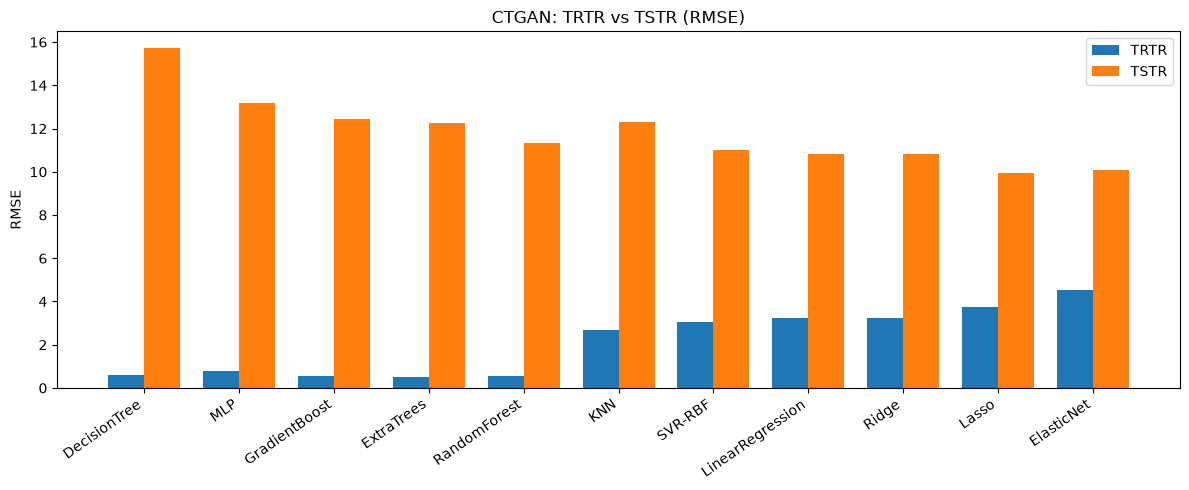

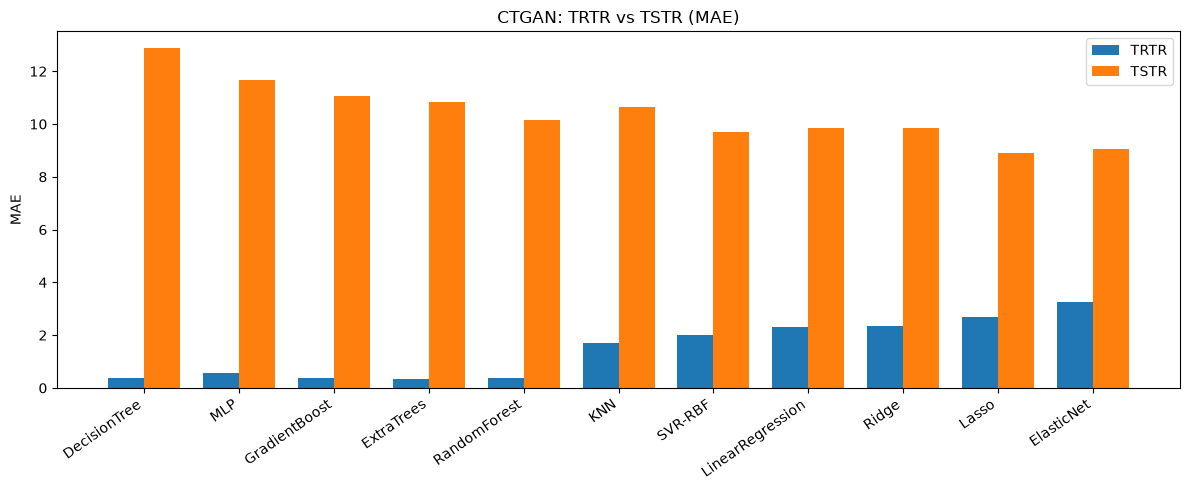

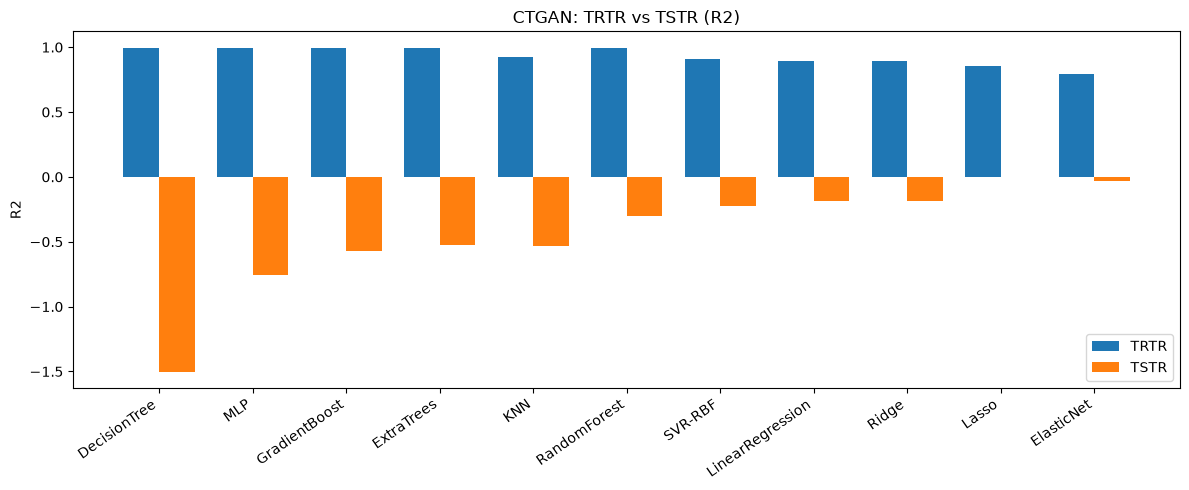

CopulaGAN - TSTR


,Model,MAE,RMSE,R2
0,GradientBoost,9.130791,10.695237,-0.159346
1,LinearRegression,9.493086,10.891682,-0.202326
2,Ridge,9.494104,10.892839,-0.202581
3,RandomForest,9.431404,11.038926,-0.235054
4,ElasticNet,9.945152,11.399016,-0.316943
5,Lasso,10.021304,11.498916,-0.340127
6,ExtraTrees,9.856031,11.645298,-0.374464
7,KNN,10.118481,12.090601,-0.481590
8,MLP,10.647062,12.095063,-0.482684
9,SVR-RBF,10.327531,12.114025,-0.487336


CopulaGAN - TRTR vs TSTR Comparison


,Model,MAE_TRTR,RMSE_TRTR,R2_TRTR,MAE_TSTR,RMSE_TSTR,R2_TSTR,RMSE_Diff,Synthetic_Model
0,ExtraTrees,0.345157,0.524558,0.997211,9.856031,11.645298,-0.374464,11.120740,CopulaGAN
1,GradientBoost,0.376701,0.540016,0.997044,9.130791,10.695237,-0.159346,10.155221,CopulaGAN
2,RandomForest,0.369292,0.559231,0.996830,9.431404,11.038926,-0.235054,10.479695,CopulaGAN
3,DecisionTree,0.386623,0.598175,0.996373,11.814545,14.878272,-1.243557,14.280097,CopulaGAN
4,MLP,0.573855,0.801321,0.993492,10.647062,12.095063,-0.482684,11.293742,CopulaGAN
5,KNN,1.686597,2.675482,0.927450,10.118481,12.090601,-0.481590,9.415118,CopulaGAN
6,SVR-RBF,2.006684,3.047016,0.905902,10.327531,12.114025,-0.487336,9.067009,CopulaGAN
7,LinearRegression,2.325813,3.233638,0.894022,9.493086,10.891682,-0.202326,7.658044,CopulaGAN
8,Ridge,2.339003,3.248108,0.893072,9.494104,10.892839,-0.202581,7.644731,CopulaGAN
9,Lasso,2.699875,3.762727,0.856505,10.021304,11.498916,-0.340127,7.736189,CopulaGAN


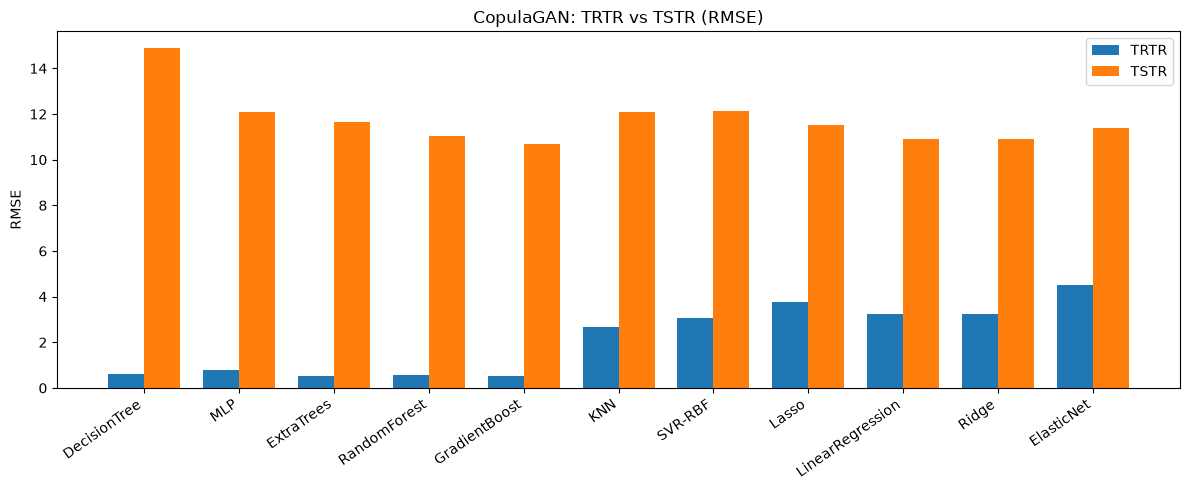

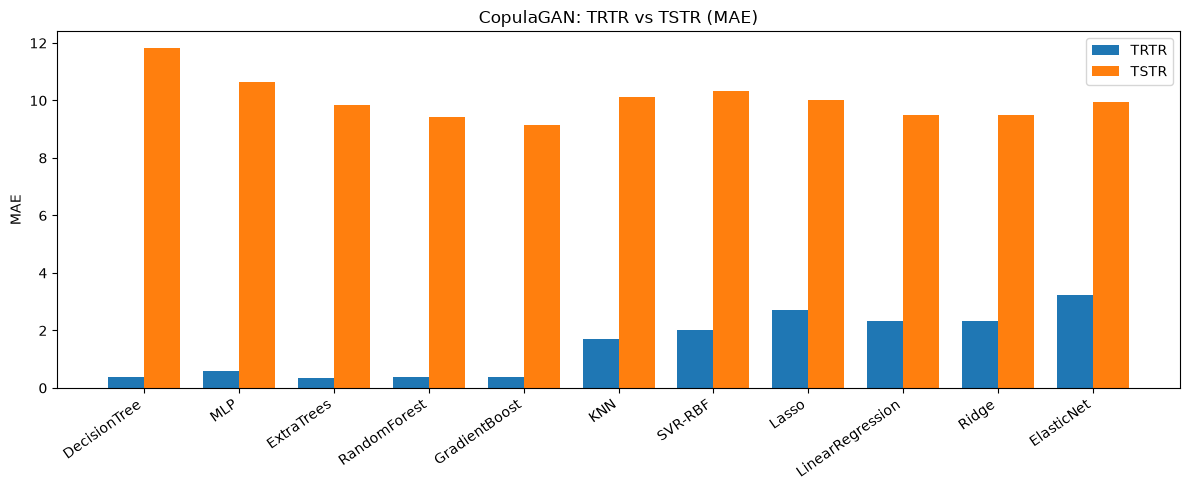

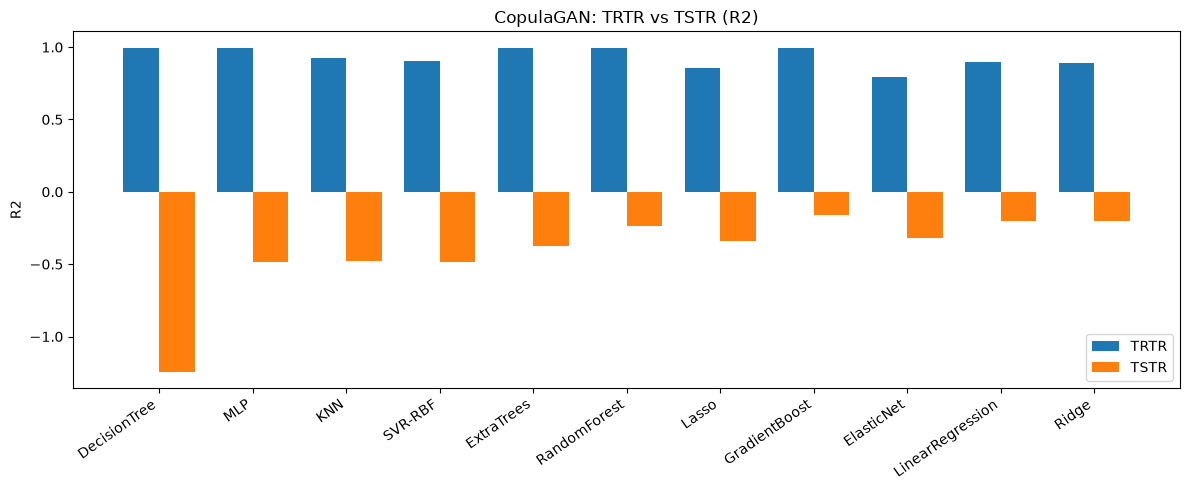

TVAE - TSTR


,Model,MAE,RMSE,R2
0,RandomForest,2.796338,3.753454,0.857211
1,MLP,2.789919,3.869415,0.848252
2,GradientBoost,2.847125,3.954184,0.841530
3,LinearRegression,2.692327,4.025222,0.835785
4,Ridge,2.694811,4.029710,0.835419
5,KNN,2.998870,4.143934,0.825956
6,ExtraTrees,2.960611,4.210626,0.820309
7,SVR-RBF,3.135507,4.321665,0.810707
8,Lasso,3.435220,4.830232,0.763534
9,ElasticNet,3.708705,5.159324,0.730215


TVAE - TRTR vs TSTR Comparison


,Model,MAE_TRTR,RMSE_TRTR,R2_TRTR,MAE_TSTR,RMSE_TSTR,R2_TSTR,RMSE_Diff,Synthetic_Model
0,ExtraTrees,0.345157,0.524558,0.997211,2.960611,4.210626,0.820309,3.686068,TVAE
1,GradientBoost,0.376701,0.540016,0.997044,2.847125,3.954184,0.841530,3.414168,TVAE
2,RandomForest,0.369292,0.559231,0.996830,2.796338,3.753454,0.857211,3.194223,TVAE
3,DecisionTree,0.386623,0.598175,0.996373,4.363377,6.322186,0.594896,5.724012,TVAE
4,MLP,0.573855,0.801321,0.993492,2.789919,3.869415,0.848252,3.068094,TVAE
5,KNN,1.686597,2.675482,0.927450,2.998870,4.143934,0.825956,1.468452,TVAE
6,SVR-RBF,2.006684,3.047016,0.905902,3.135507,4.321665,0.810707,1.274649,TVAE
7,LinearRegression,2.325813,3.233638,0.894022,2.692327,4.025222,0.835785,0.791584,TVAE
8,Ridge,2.339003,3.248108,0.893072,2.694811,4.029710,0.835419,0.781602,TVAE
9,Lasso,2.699875,3.762727,0.856505,3.435220,4.830232,0.763534,1.067505,TVAE


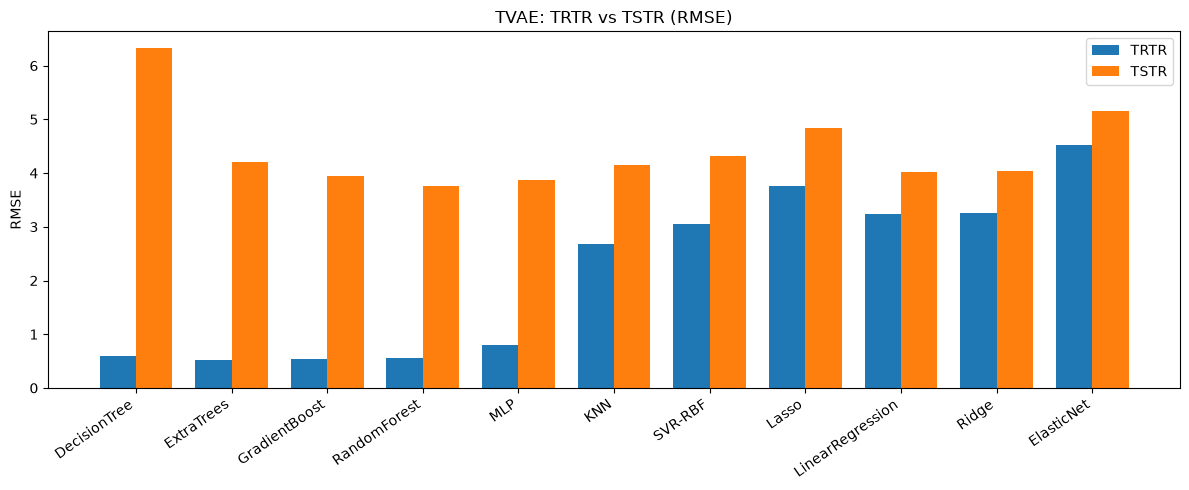

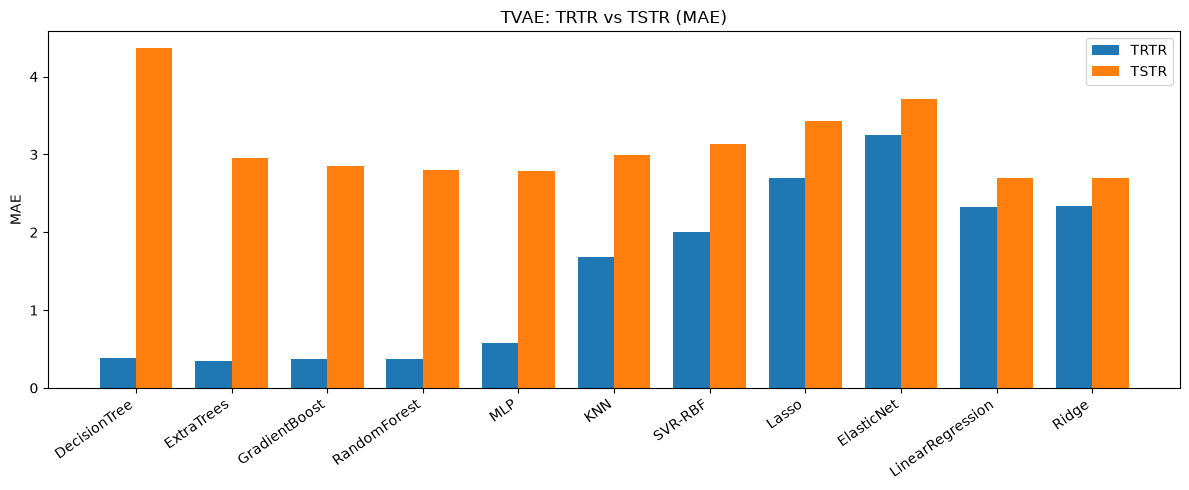

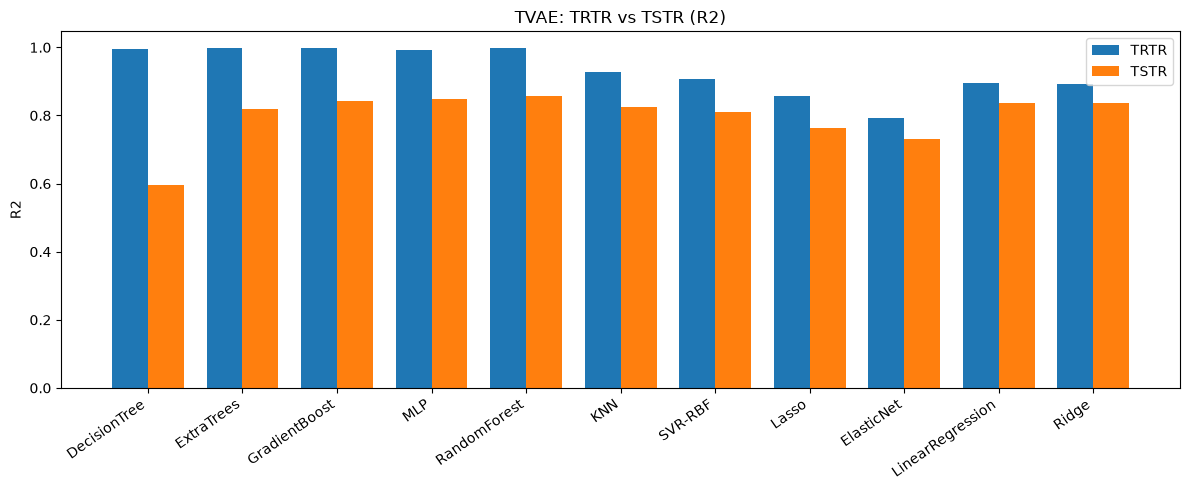

GaussianCopula - TSTR


,Model,MAE,RMSE,R2
0,ElasticNet,2.955889,3.936271,0.842963
1,SVR-RBF,3.127206,4.129536,0.827164
2,Lasso,3.935001,4.828903,0.763664
3,KNN,3.866818,4.964570,0.750198
4,Ridge,5.170340,6.180274,0.612878
5,LinearRegression,5.203361,6.214778,0.608544
6,MLP,5.201285,6.515561,0.569735
7,RandomForest,5.530622,7.170243,0.478925
8,ExtraTrees,6.601595,7.859598,0.373916
9,DecisionTree,6.264221,7.904476,0.366745


GaussianCopula - TRTR vs TSTR Comparison


,Model,MAE_TRTR,RMSE_TRTR,R2_TRTR,MAE_TSTR,RMSE_TSTR,R2_TSTR,RMSE_Diff,Synthetic_Model
0,ExtraTrees,0.345157,0.524558,0.997211,6.601595,7.859598,0.373916,7.335040,GaussianCopula
1,GradientBoost,0.376701,0.540016,0.997044,6.330380,8.106937,0.333890,7.566921,GaussianCopula
2,RandomForest,0.369292,0.559231,0.996830,5.530622,7.170243,0.478925,6.611012,GaussianCopula
3,DecisionTree,0.386623,0.598175,0.996373,6.264221,7.904476,0.366745,7.306301,GaussianCopula
4,MLP,0.573855,0.801321,0.993492,5.201285,6.515561,0.569735,5.714240,GaussianCopula
5,KNN,1.686597,2.675482,0.927450,3.866818,4.964570,0.750198,2.289087,GaussianCopula
6,SVR-RBF,2.006684,3.047016,0.905902,3.127206,4.129536,0.827164,1.082520,GaussianCopula
7,LinearRegression,2.325813,3.233638,0.894022,5.203361,6.214778,0.608544,2.981139,GaussianCopula
8,Ridge,2.339003,3.248108,0.893072,5.170340,6.180274,0.612878,2.932166,GaussianCopula
9,Lasso,2.699875,3.762727,0.856505,3.935001,4.828903,0.763664,1.066176,GaussianCopula


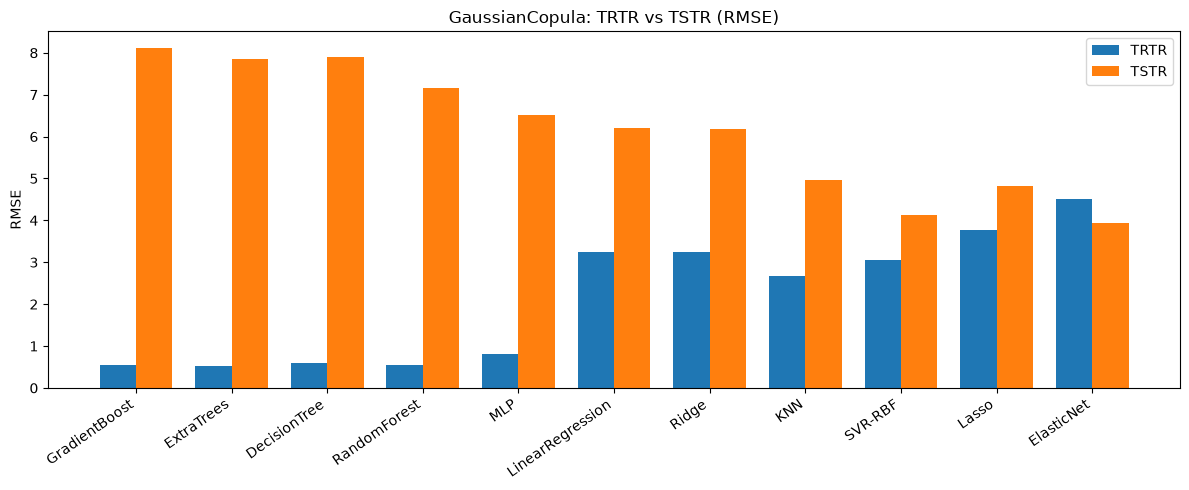

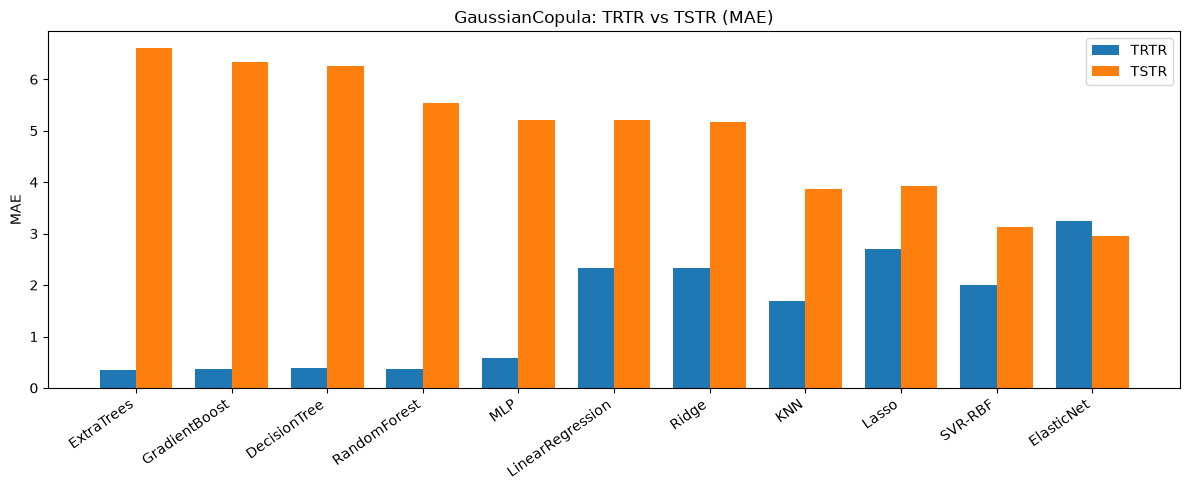

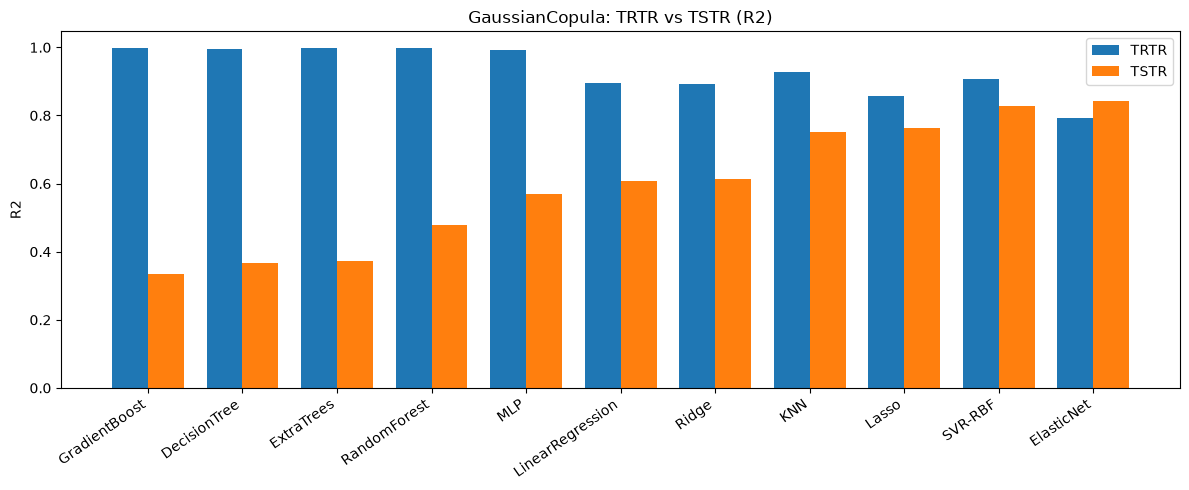

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric="RMSE"):
    if metric not in trtr_results.columns or metric not in tstr_results.columns:
        return
    df = trtr_results[["Model", metric]].merge(
        tstr_results[["Model", metric]], on="Model", suffixes=("_TRTR", "_TSTR")
    )
    df["Diff"] = (
        df[f"{metric}_TSTR"] - df[f"{metric}_TRTR"]
        if metric in ["MAE", "RMSE"]
        else df[f"{metric}_TRTR"] - df[f"{metric}_TSTR"]
    )
    df = df.sort_values("Diff", ascending=False)
    x = np.arange(len(df))
    w = 0.38
    plt.figure(figsize=(12, 5))
    plt.bar(x - w/2, df[f"{metric}_TRTR"], w, label="TRTR")
    plt.bar(x + w/2, df[f"{metric}_TSTR"], w, label="TSTR")
    plt.xticks(x, df["Model"], rotation=35, ha="right")
    plt.ylabel(metric)
    plt.title(f"{synth_name}: TRTR vs TSTR ({metric})")
    plt.legend()
    plt.tight_layout()
    plt.show()

label_col = "Y1"
model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
trtr_results = evaluate_models(train_df=data, test_df=data, label=label_col, models=models)
print("TRTR (Train Real, Test Real)")
display(trtr_results)
print("=" * 70)
for synth_name in model_order:
    _common = [c for c in data.columns if c in synthetic_datasets[synth_name].columns]
    synth_train = synthetic_datasets[synth_name][_common].copy()
    tstr_results = evaluate_models(train_df=synth_train, test_df=data, label=label_col, models=models)
    print(f"{synth_name} - TSTR")
    display(tstr_results)
    comparison = trtr_results.merge(tstr_results, on="Model", suffixes=("_TRTR", "_TSTR"))
    comparison["RMSE_Diff"] = comparison["RMSE_TSTR"] - comparison["RMSE_TRTR"]
    comparison["Synthetic_Model"] = synth_name
    print(f"{synth_name} - TRTR vs TSTR Comparison")
    display(comparison)
    print("=" * 70)
    for metric in ["RMSE", "MAE", "R2"]:
        plot_trtr_vs_tstr(trtr_results, tstr_results, synth_name, metric)


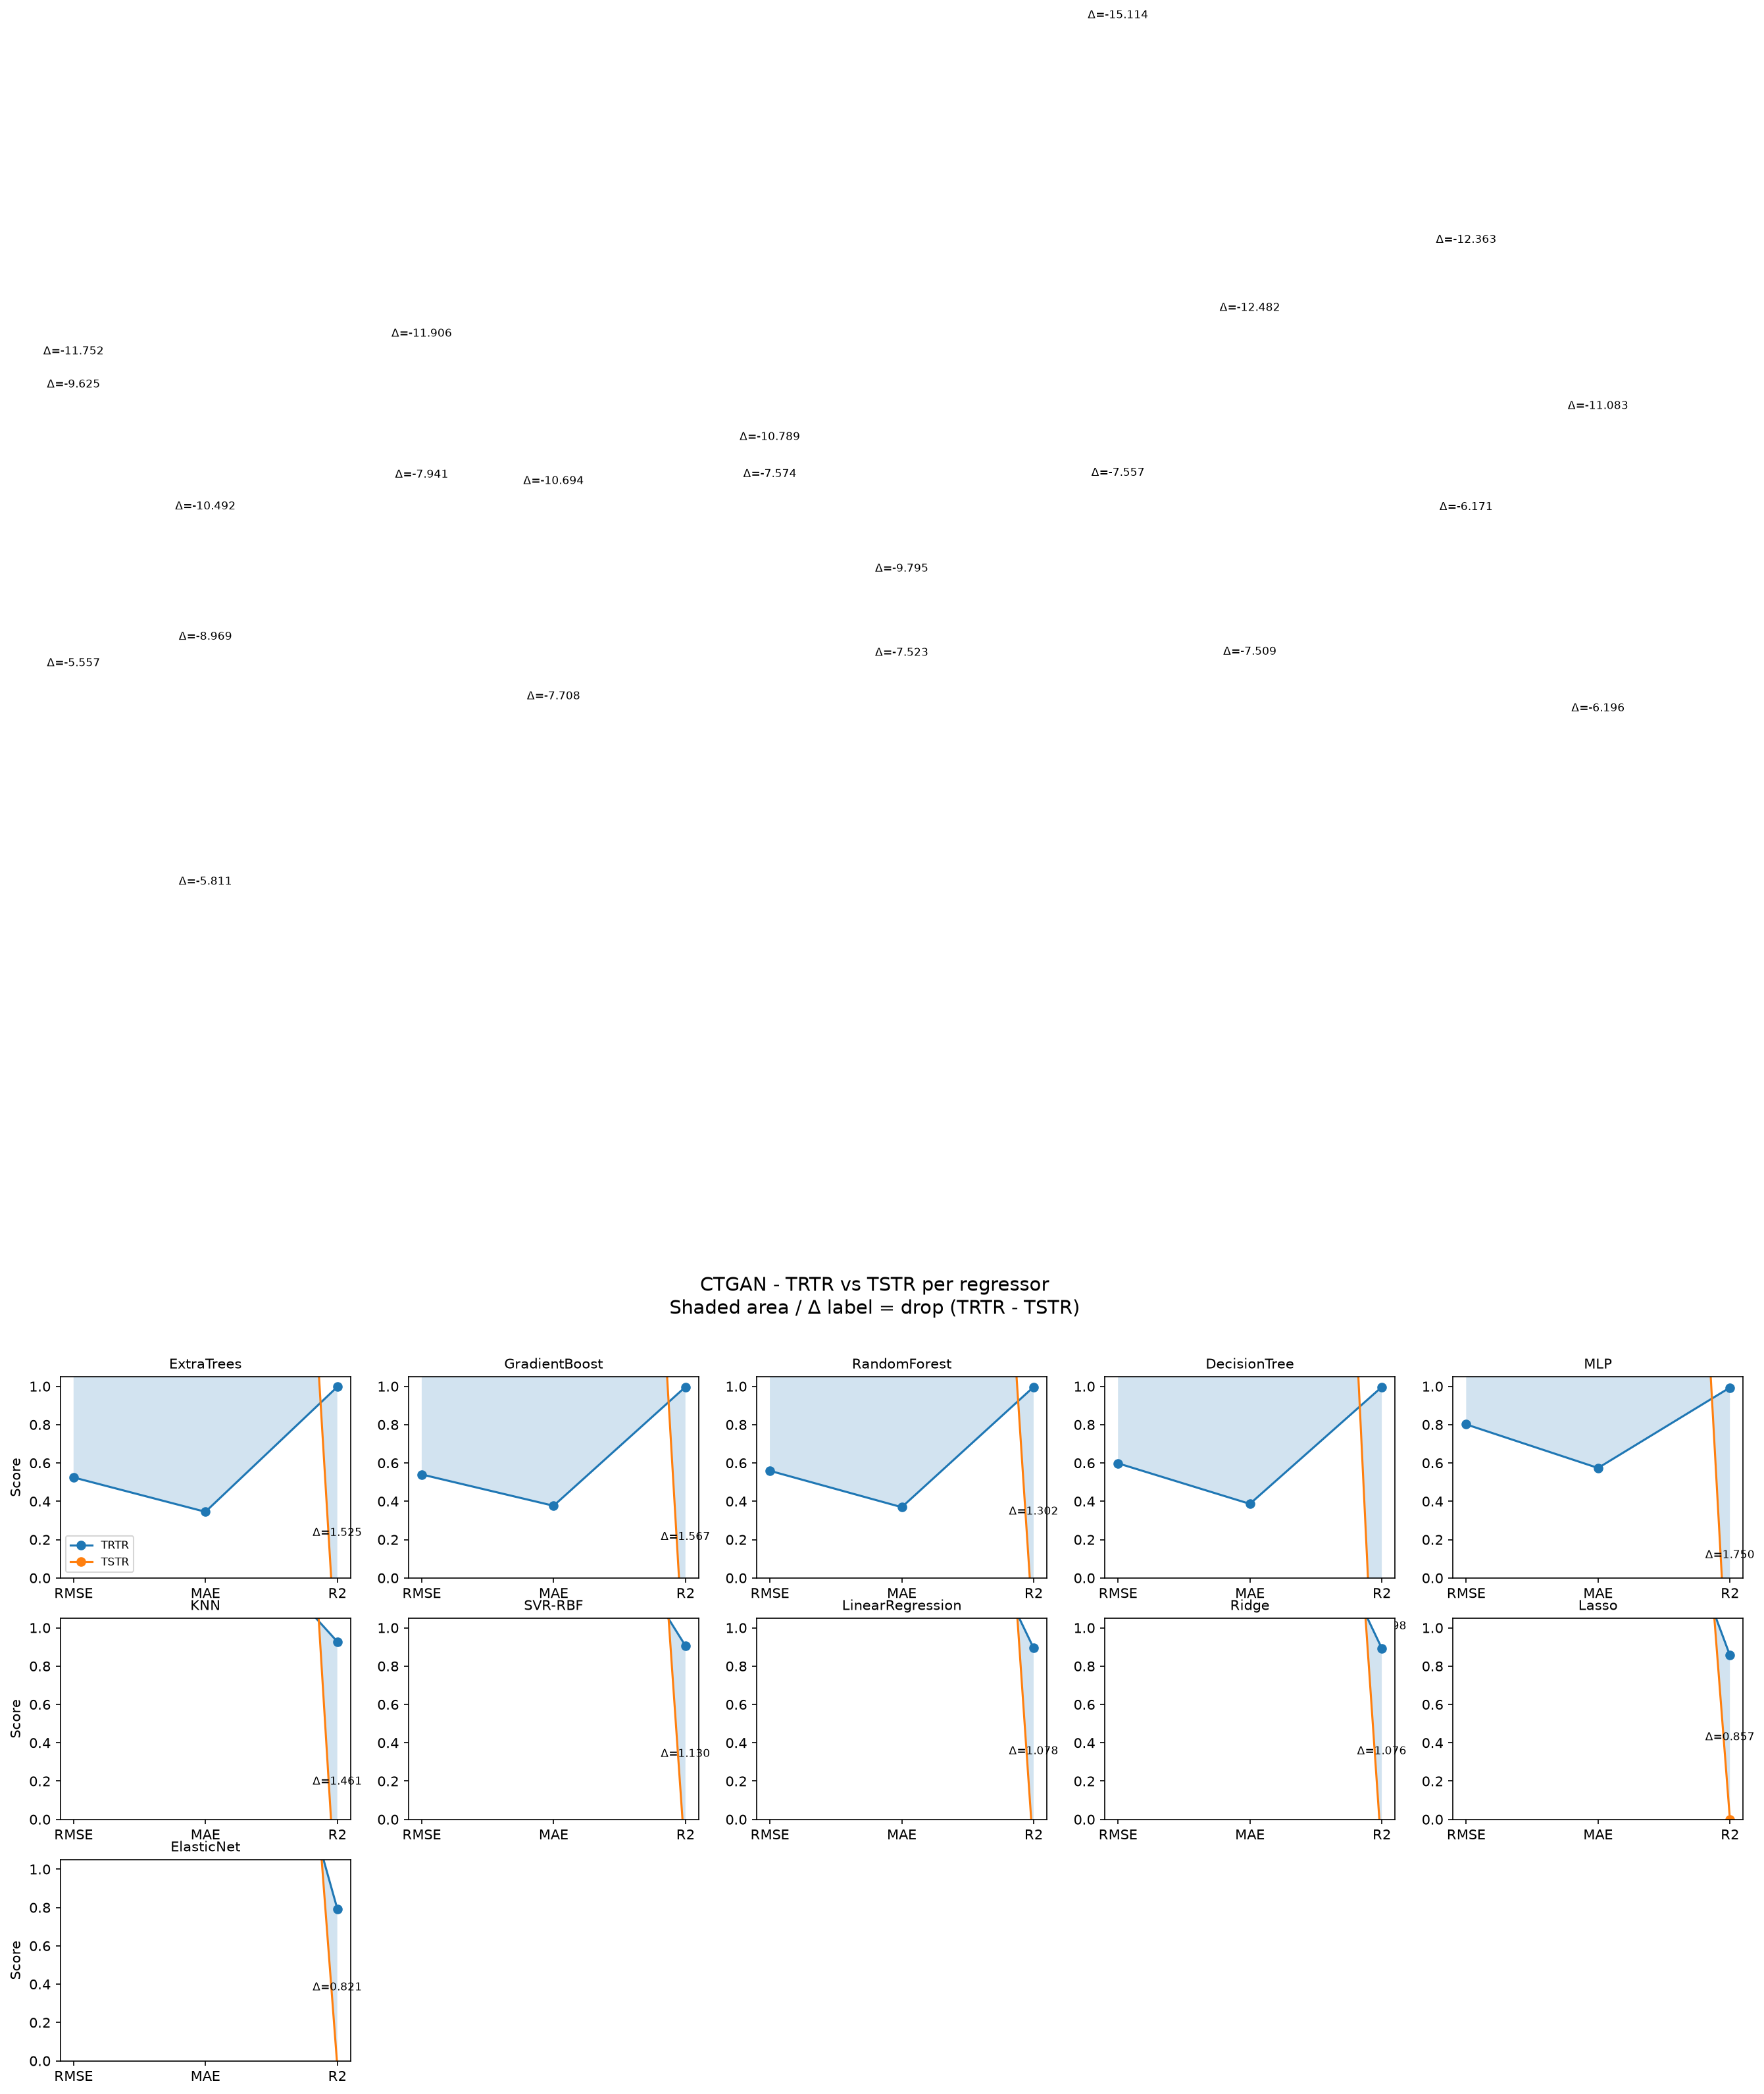

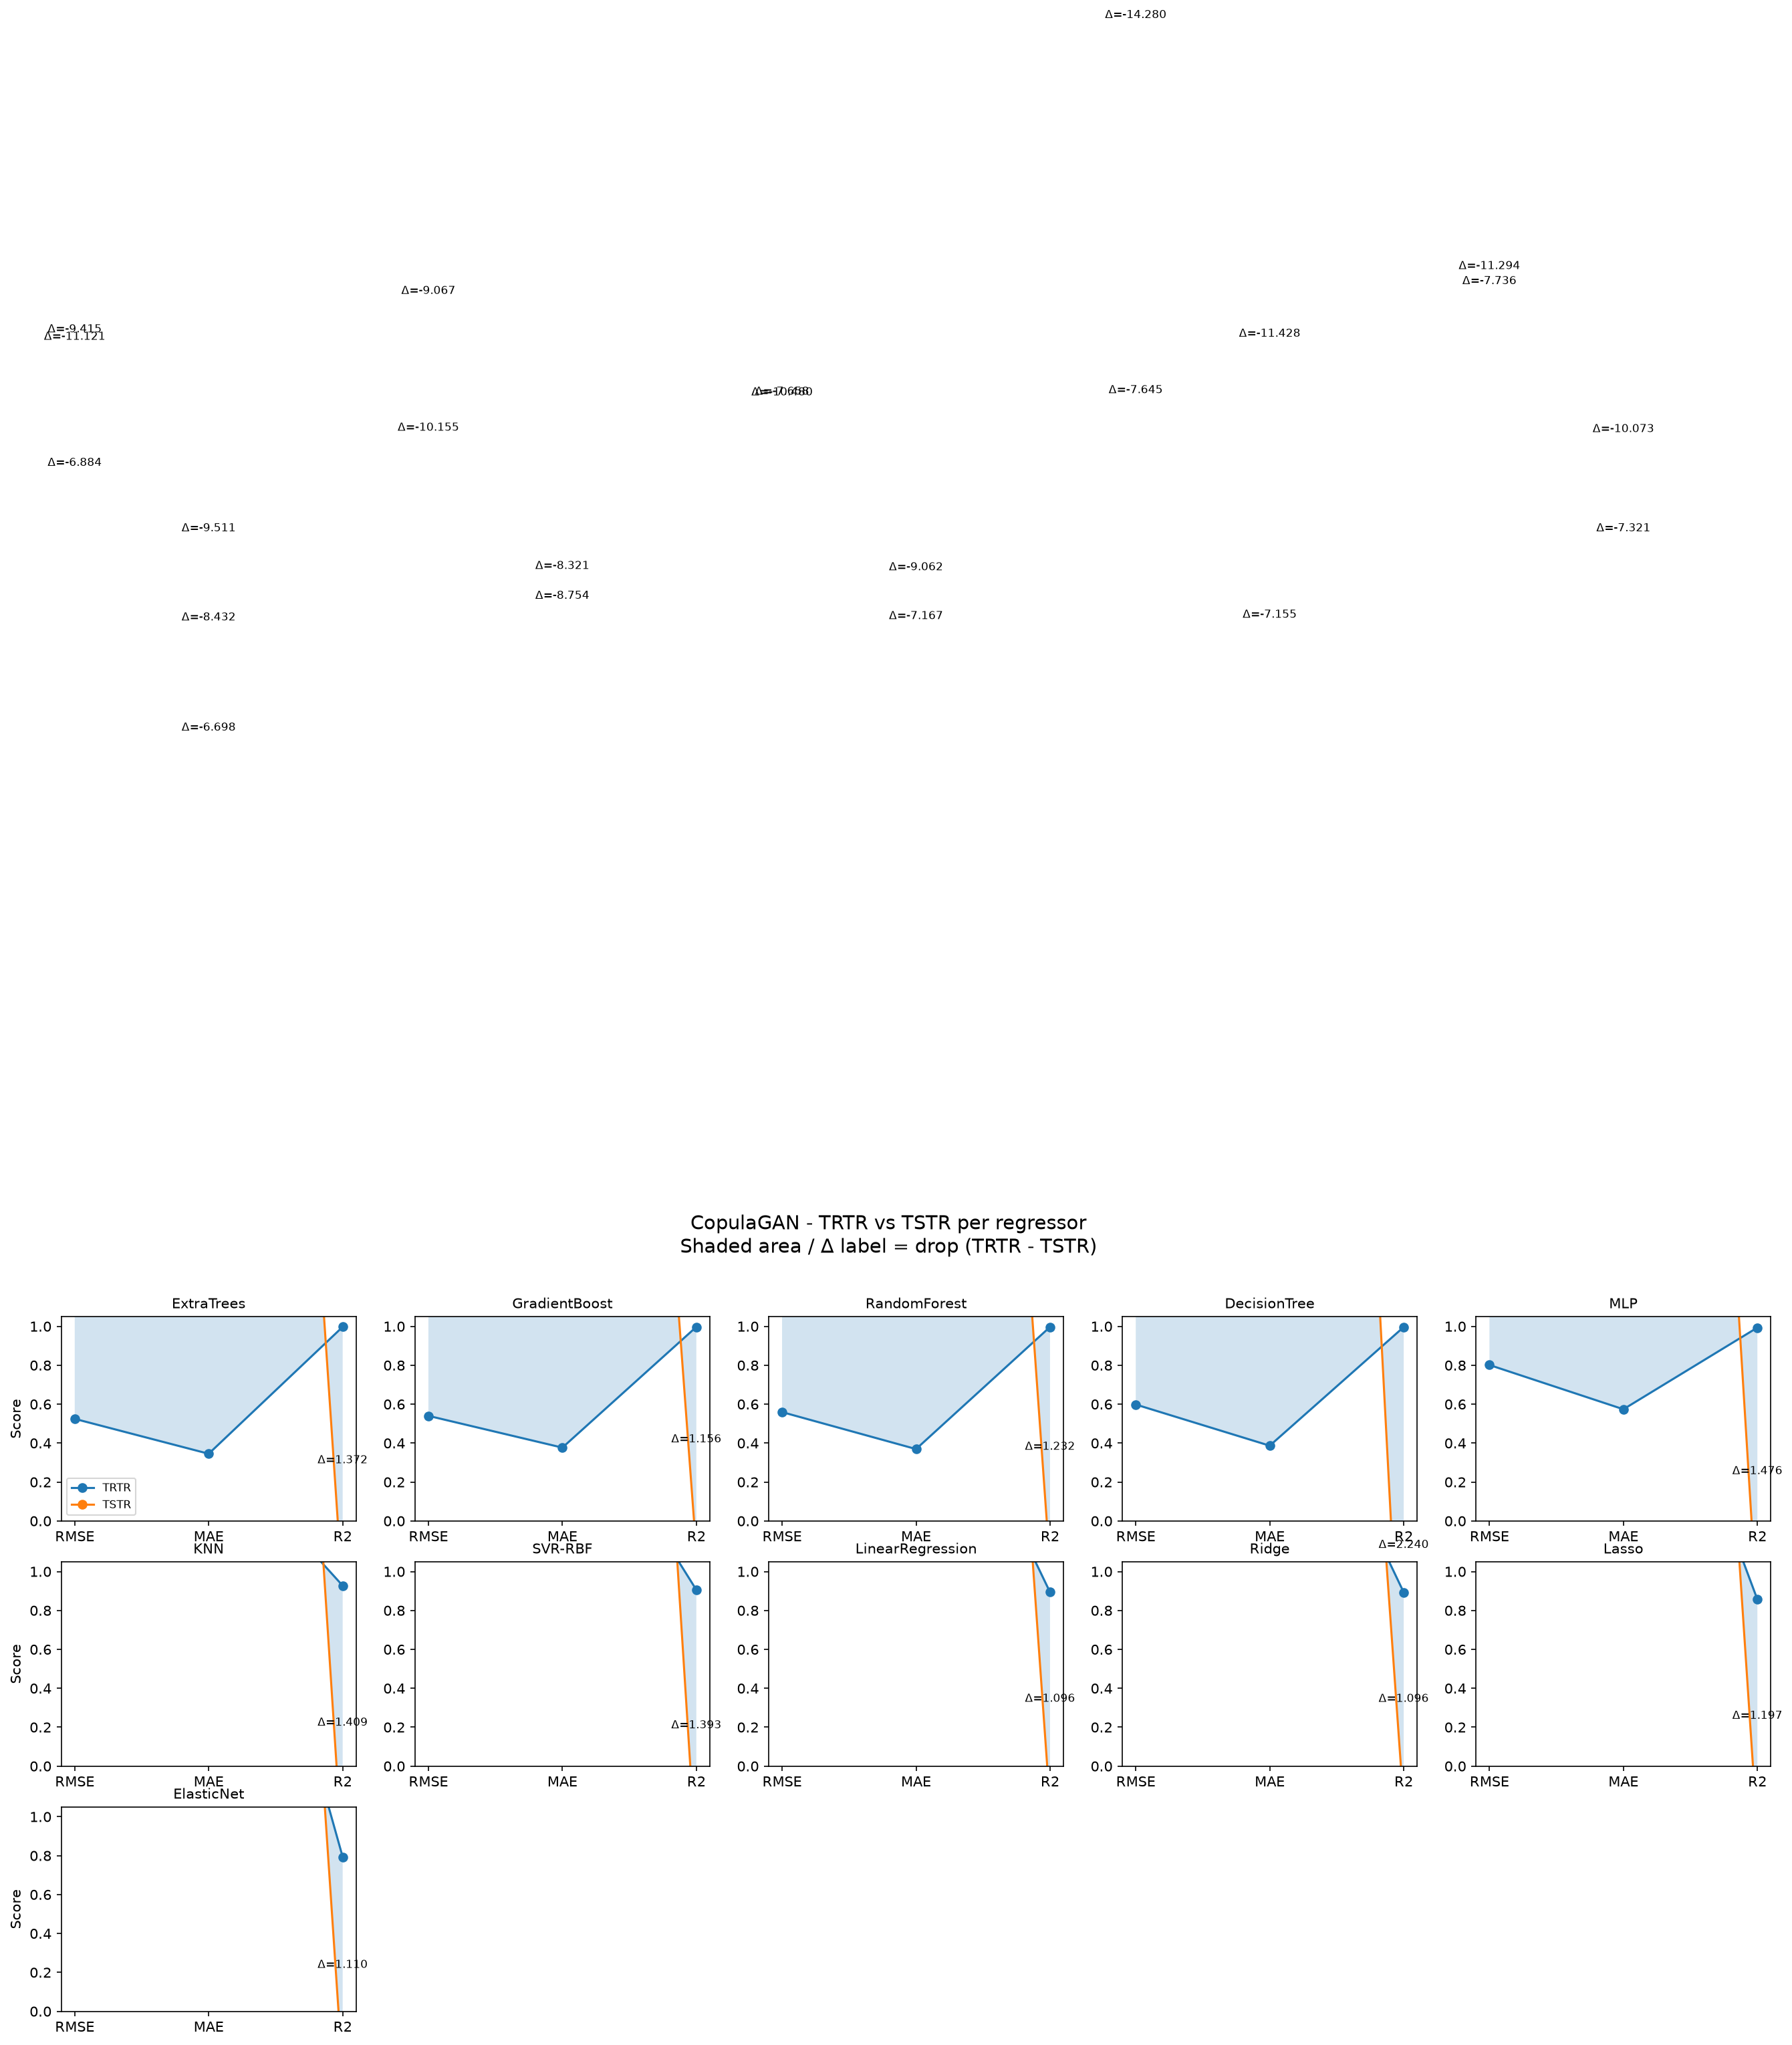

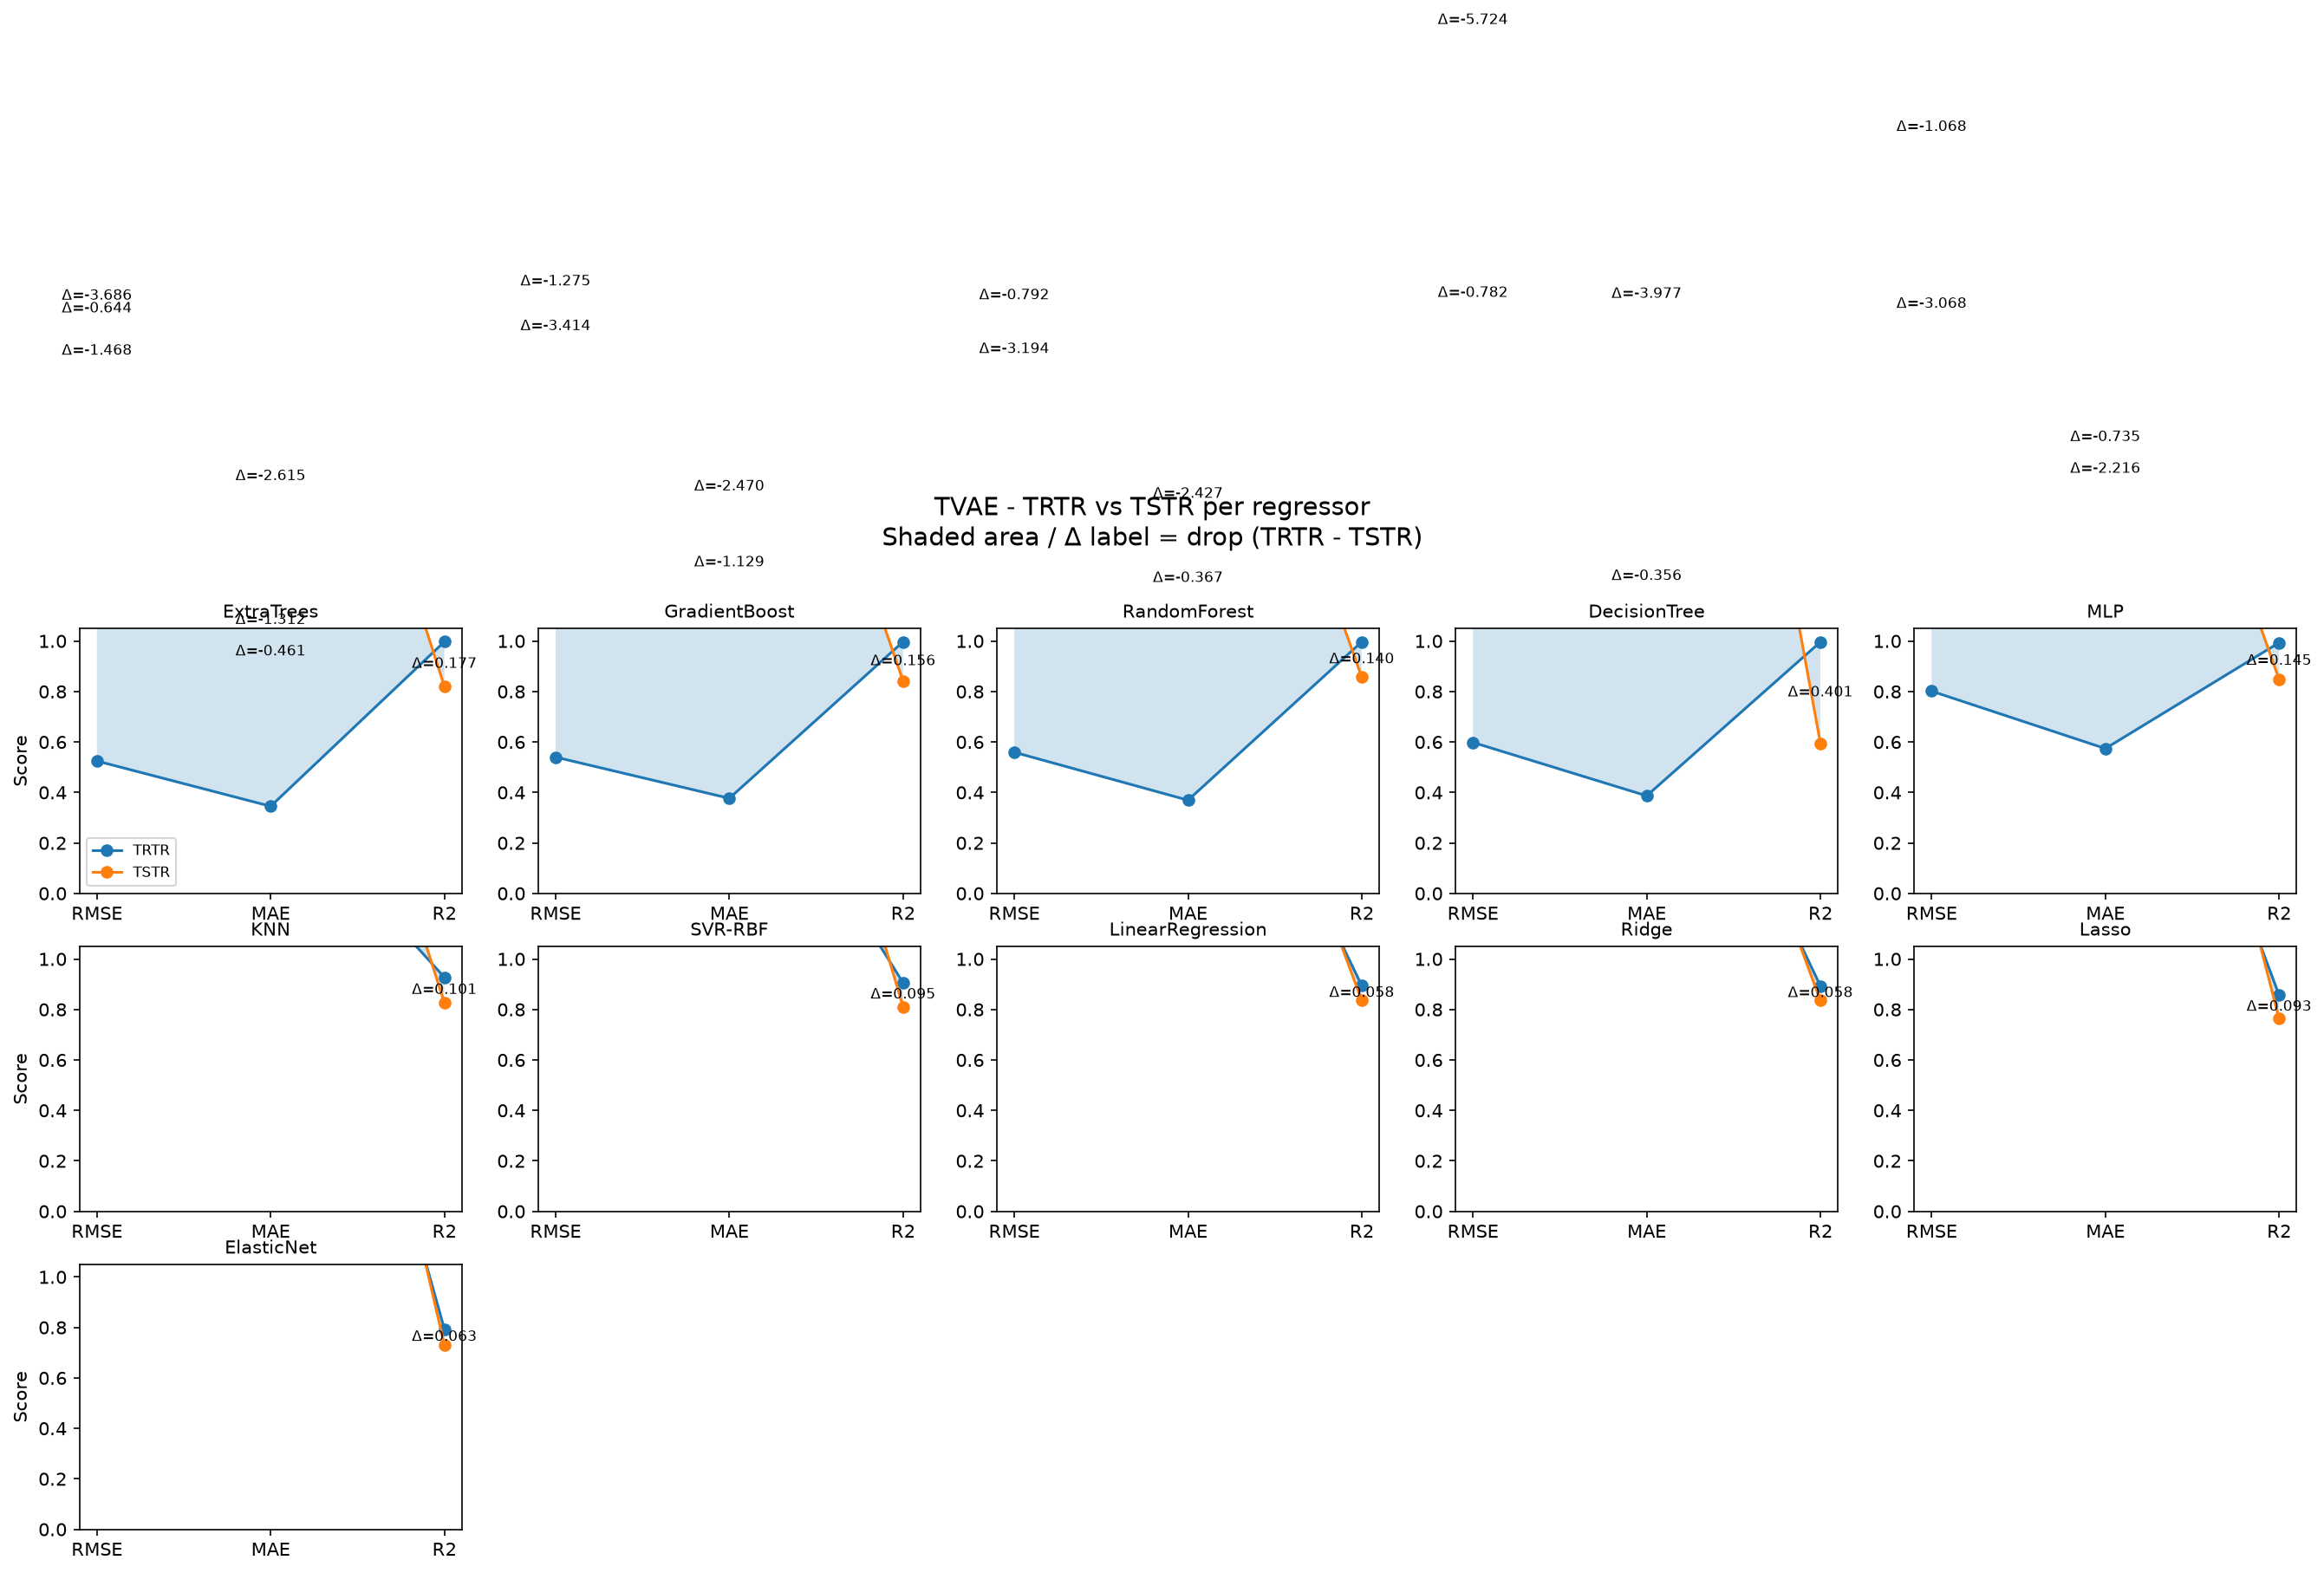

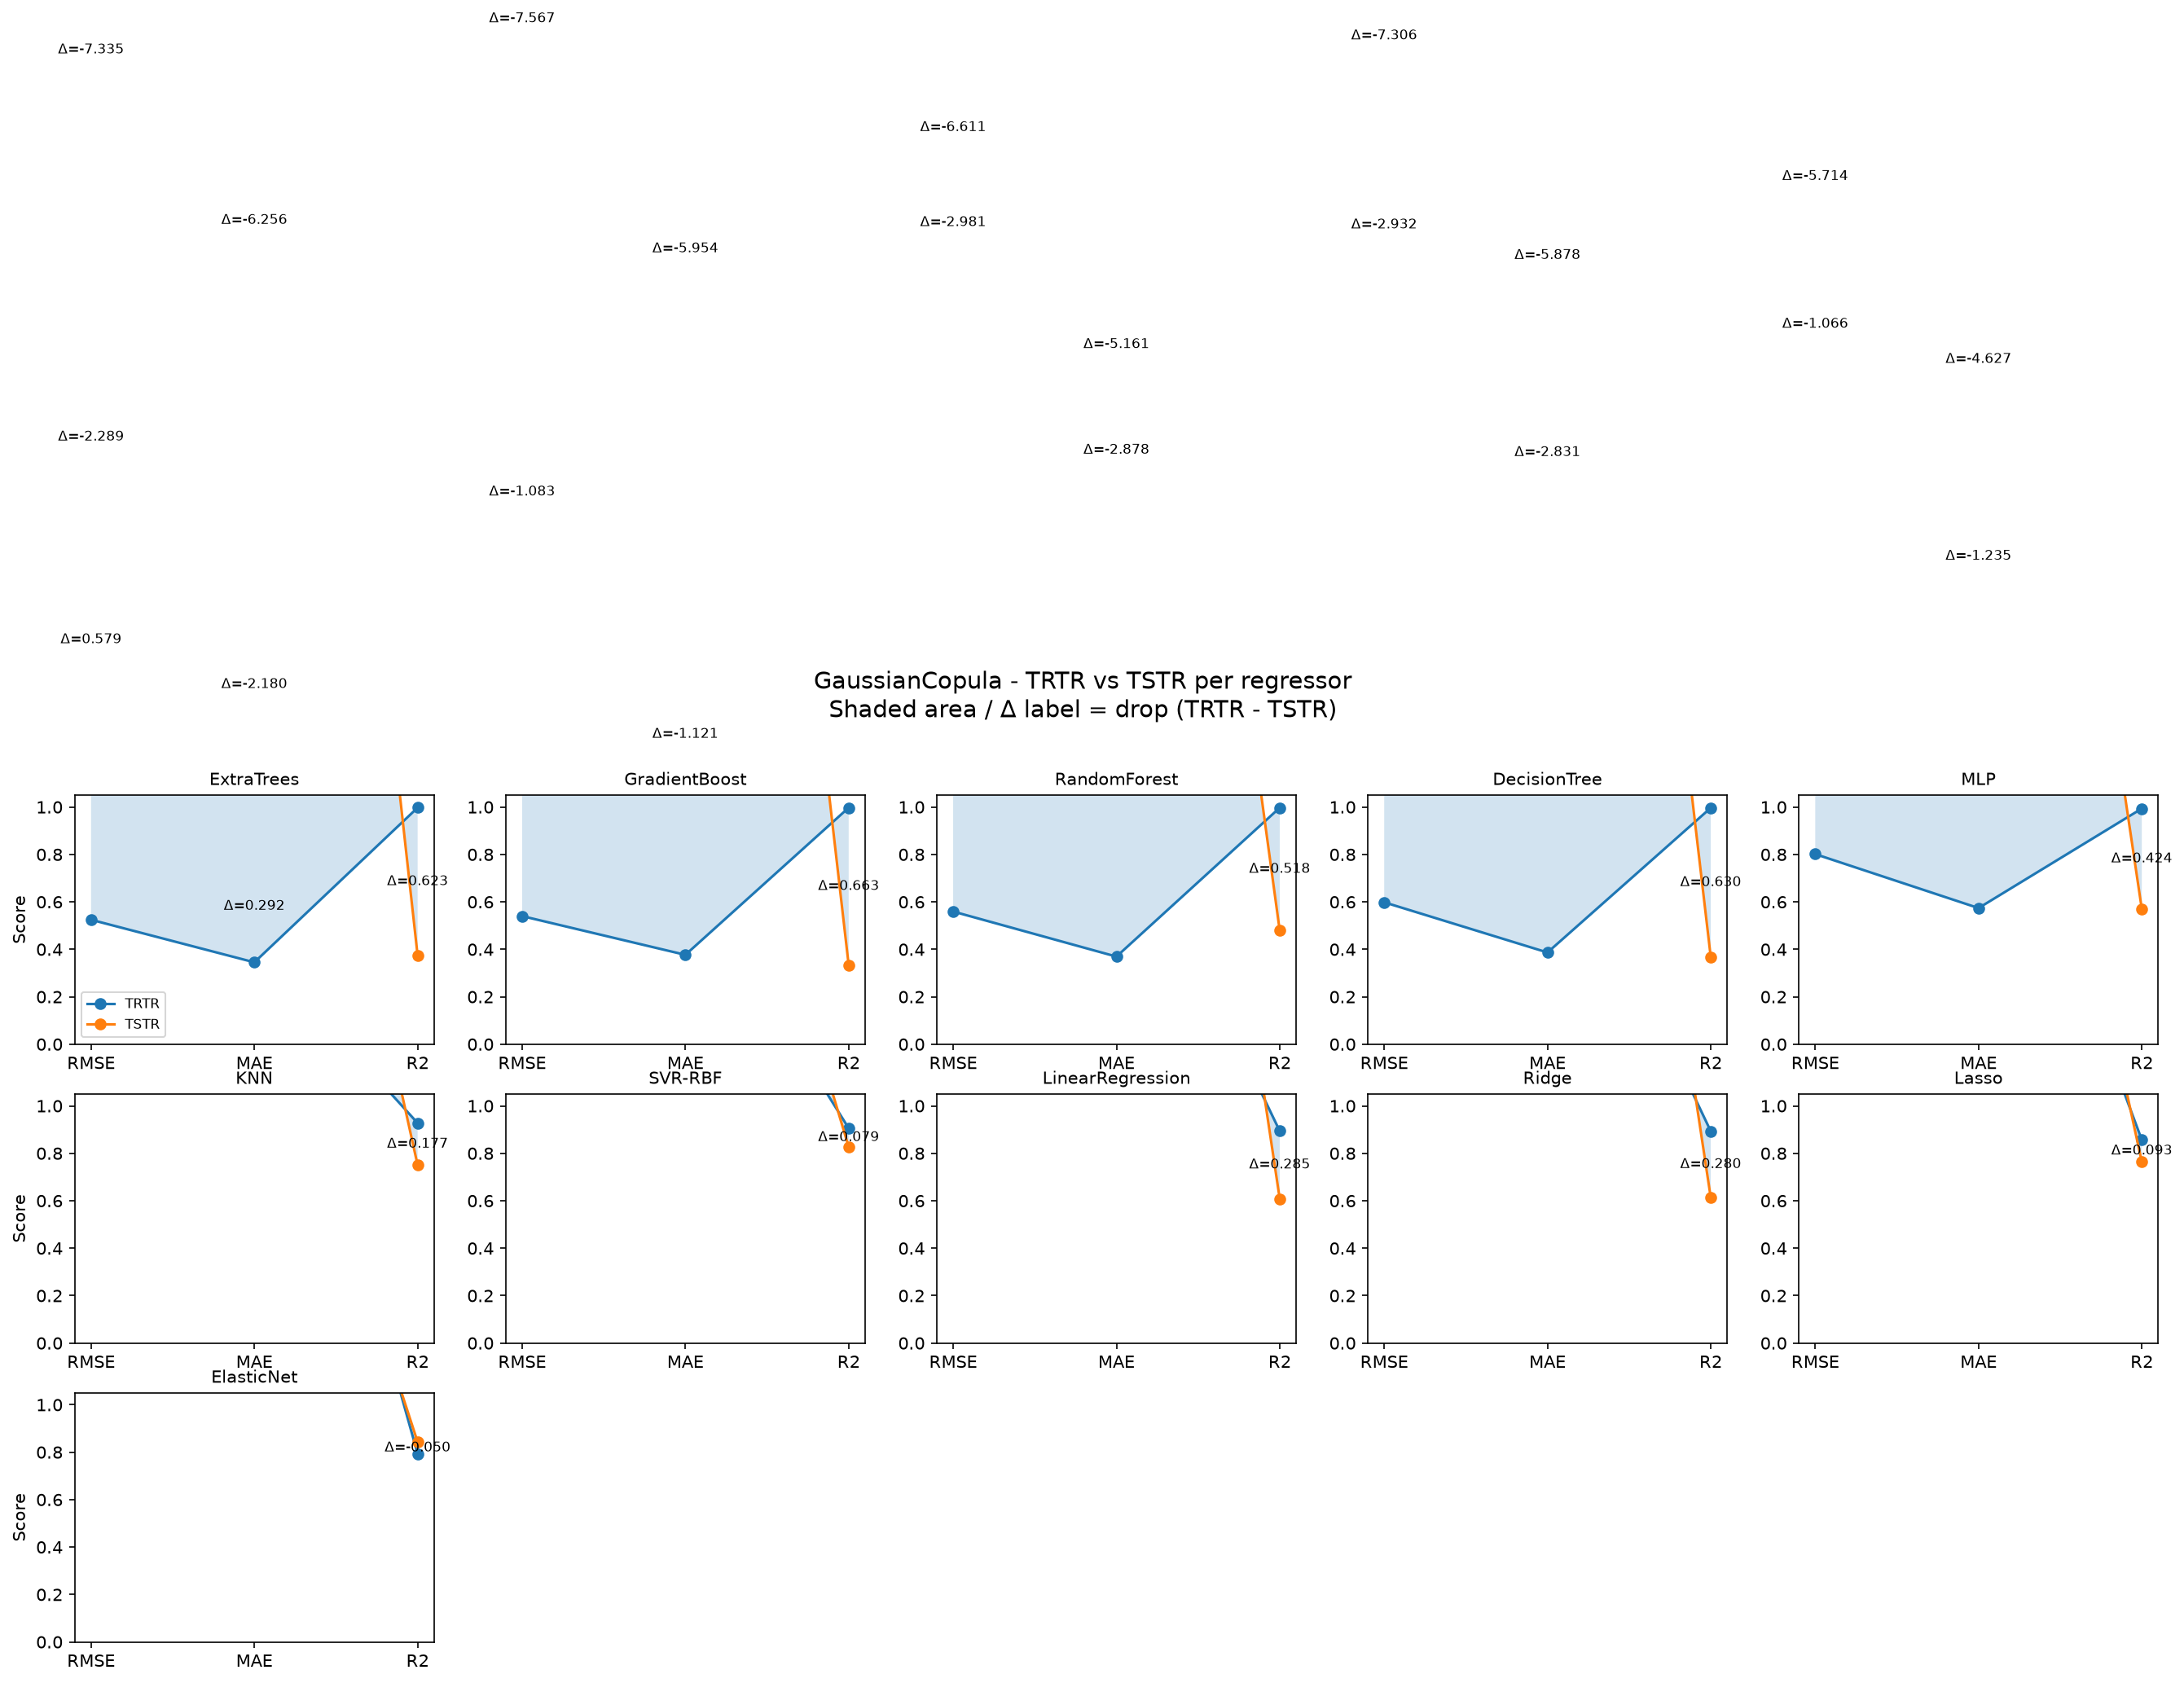

In [29]:
import numpy as np
import matplotlib.pyplot as plt

def plot_grid_line_metrics_with_gap(
    trtr_results,
    tstr_results,
    generator_name,
    ncols=5
):
    metrics = [m for m in ["RMSE", "MAE", "R2"] if m in trtr_results.columns and m in tstr_results.columns]
    if not metrics:
        print(f"No common metrics found for {generator_name}.")
        return

    x = np.arange(len(metrics))

    trtr = trtr_results.set_index("Model")[metrics]
    tstr = tstr_results.set_index("Model")[metrics]
    models_local = [m for m in trtr.index if m in tstr.index]

    n = len(models_local)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(22, 9),
        dpi=150,
        constrained_layout=True
    )
    axes = np.array(axes).reshape(-1)

    for i, m in enumerate(models_local):
        ax = axes[i]
        a = trtr.loc[m].values.astype(float)
        b = tstr.loc[m].values.astype(float)
        d = a - b

        ax.plot(x, a, marker="o", label="TRTR")
        ax.plot(x, b, marker="o", label="TSTR")
        ax.fill_between(x, b, a, alpha=0.2)

        for xi, ai, bi, di in zip(x, a, b, d):
            ax.text(xi, (ai + bi) / 2, f"Δ={di:.3f}", ha="center", va="center", fontsize=8)

        ax.set_title(m, fontsize=10)
        ax.set_xticks(x)
        ax.set_xticklabels(metrics)
        ax.set_ylim(0, 1.05)

        if i % ncols == 0:
            ax.set_ylabel("Score")
        if i == 0:
            ax.legend(fontsize=8, loc="lower left")

    for j in range(n, len(axes)):
        axes[j].axis("off")

    fig.suptitle(
        f"{generator_name} - TRTR vs TSTR per regressor\n"
        f"Shaded area / Δ label = drop (TRTR - TSTR)",
        fontsize=14
    )
    plt.show()

label_col = "Y1"
generators = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

trtr_results = evaluate_models(
    train_df=data,
    test_df=data,
    label="Y1",
    models=models
)

for gen in generators:
    tstr_results = evaluate_models(
        train_df=synthetic_datasets[gen][[c for c in data.columns if c in synthetic_datasets[gen].columns]],
        test_df=data,
        label="Y1",
        models=models
    )
    plot_grid_line_metrics_with_gap(
        trtr_results,
        tstr_results,
        generator_name=gen,
        ncols=5
    )

# 5 Statistical similarity tests 

Average error by model


,Model,Mean Error %,Median Error %,Std Error %
0,CTGAN,6.831319,5.423380,6.953187
1,CopulaGAN,6.337747,4.079192,10.726314
2,TVAE,6.569800,2.751480,6.650251
3,GaussianCopula,3.734944,2.341670,10.718952


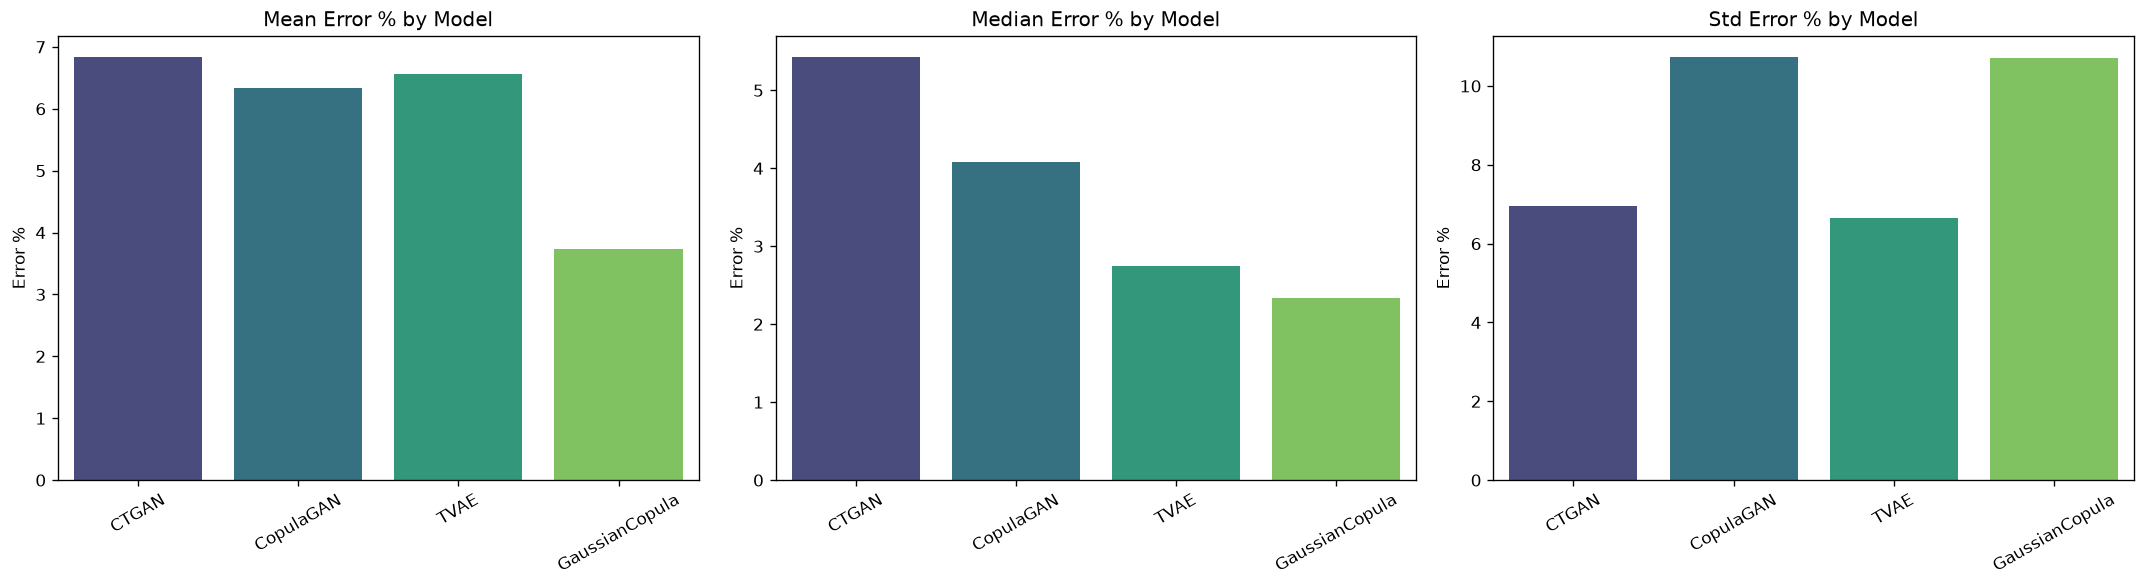

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "Y1"]

summary_rows = []
feature_error_by_model = {}

for model_name in model_order:
    synth_df = synthetic_datasets[model_name].copy()
    _common = [c for c in real_df.columns if c in synth_df.columns]

    synth_df = synth_df[_common]

    real_means = real_df[num_cols].astype(np.float64).mean()
    synth_means = synth_df[num_cols].astype(np.float64).mean()

    real_stds = real_df[num_cols].astype(np.float64).std(ddof=1)
    synth_stds = synth_df[num_cols].astype(np.float64).std(ddof=1)

    mean_error_pct = (np.abs(synth_means - real_means) / real_means.replace(0, np.nan).abs()) * 100
    std_error_pct = (np.abs(synth_stds - real_stds) / real_stds.replace(0, np.nan).abs()) * 100

    feature_error_df = pd.DataFrame({
        "Feature": num_cols,
        "Mean_Error_%": mean_error_pct.values,
        "Std_Error_%": std_error_pct.values
    })

    feature_error_df = feature_error_df.replace([np.inf, -np.inf], np.nan)

    model_summary = {
        "Model": model_name,
        "Mean Error %": float(feature_error_df["Mean_Error_%"].mean(skipna=True)),
        "Median Error %": float(feature_error_df["Mean_Error_%"].median(skipna=True)),
        "Std Error %": float(feature_error_df["Std_Error_%"].mean(skipna=True))
    }

    summary_rows.append(model_summary)
    feature_error_by_model[model_name] = feature_error_df

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.set_index("Model").loc[model_order].reset_index()

print("Average error by model")
display(summary_df)

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=120)

sns.barplot(data=summary_df, x="Model", y="Mean Error %", ax=axes[0], palette="viridis")
axes[0].set_title("Mean Error % by Model")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Median Error %", ax=axes[1], palette="viridis")
axes[1].set_title("Median Error % by Model")
axes[1].tick_params(axis="x", rotation=30)

sns.barplot(data=summary_df, x="Model", y="Std Error %", ax=axes[2], palette="viridis")
axes[2].set_title("Std Error % by Model")
axes[2].tick_params(axis="x", rotation=30)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("Error %")

plt.tight_layout()
plt.show()


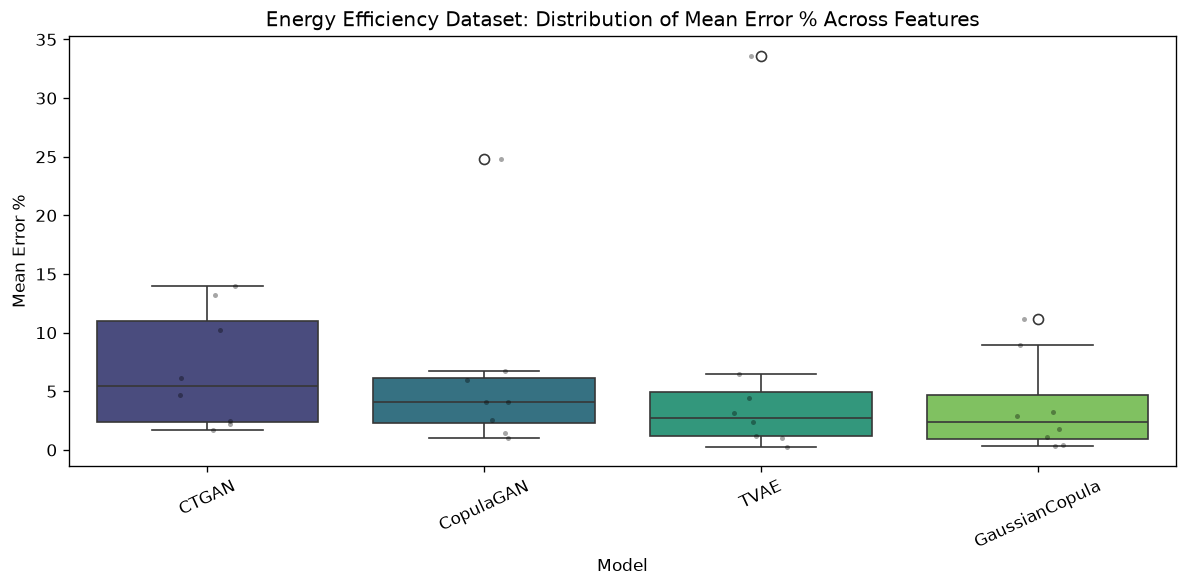

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

dist_df = pd.concat(
    [
        feature_error_by_model[m][["Feature", "Mean_Error_%"]].assign(Model=m)
        for m in ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
    ],
    ignore_index=True
).replace([float("inf"), float("-inf")], pd.NA).dropna(subset=["Mean_Error_%"])

plt.figure(figsize=(10, 5), dpi=120)
sns.boxplot(data=dist_df, x="Model", y="Mean_Error_%", palette="viridis")
sns.stripplot(data=dist_df, x="Model", y="Mean_Error_%", color="black", alpha=0.35, size=3)
plt.title("Energy Efficiency Dataset: Distribution of Mean Error % Across Features")
plt.xlabel("Model")
plt.ylabel("Mean Error %")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

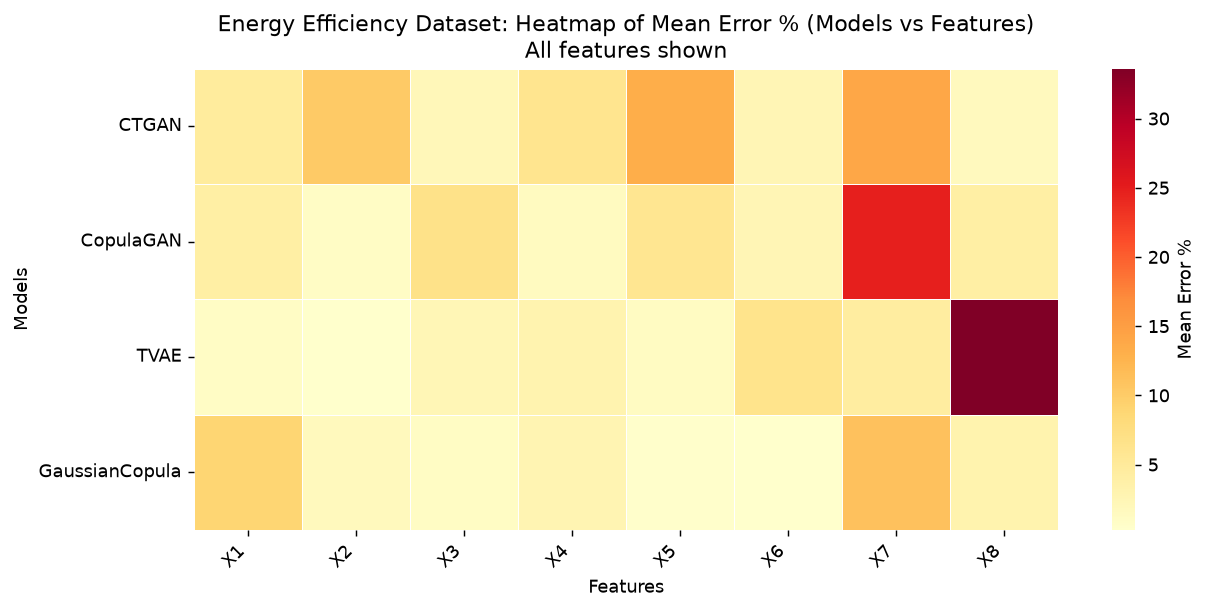

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

heatmap_df = pd.DataFrame({
    m: feature_error_by_model[m].set_index("Feature")["Mean_Error_%"]
    for m in model_order
}).T

heatmap_df = heatmap_df.replace([np.inf, -np.inf], np.nan)

max_features = 20
if heatmap_df.shape[1] > max_features:
    top_features = heatmap_df.mean(axis=0, skipna=True).sort_values(ascending=False).head(max_features).index
    heatmap_plot_df = heatmap_df[top_features]
    truncated_note = f"Top {max_features} features shown (of {heatmap_df.shape[1]} total)"
else:
    heatmap_plot_df = heatmap_df.copy()
    truncated_note = "All features shown"

def truncate_label(s, max_len=18):
    s = str(s)
    return s if len(s) <= max_len else s[:max_len - 1] + "..."

display_labels = [truncate_label(c, max_len=18) for c in heatmap_plot_df.columns]

plt.figure(figsize=(max(10, 0.55 * len(display_labels)), 4.8), dpi=130)
sns.heatmap(
    heatmap_plot_df,
    cmap="YlOrRd",
    annot=False,
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Mean Error %"}
)

plt.title(f"Energy Efficiency Dataset: Heatmap of Mean Error % (Models vs Features)\n{truncated_note}")
plt.xlabel("Features")
plt.ylabel("Models")
plt.xticks(np.arange(len(display_labels)) + 0.5, display_labels, rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

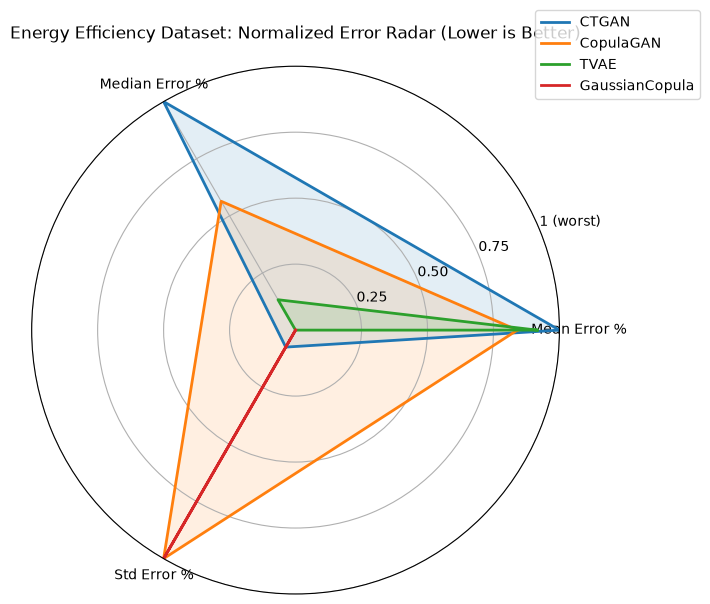

,Model,Mean Error %,Median Error %,Std Error %
0,CTGAN,1.000000,1.000000,0.074321
1,CopulaGAN,0.840597,0.563817,1.000000
2,TVAE,0.915540,0.132981,0.000000
3,GaussianCopula,0.000000,0.000000,0.998194


In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

metrics = ["Mean Error %", "Median Error %", "Std Error %"]
radar_df = summary_df[["Model"] + metrics].copy()

norm_df = radar_df.copy()
for m in metrics:
    mn, mx = norm_df[m].min(), norm_df[m].max()
    if mx > mn:
        norm_df[m] = (norm_df[m] - mn) / (mx - mn)
    else:
        norm_df[m] = 0.0

labels = metrics
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

for _, row in norm_df.iterrows():
    values = row[metrics].tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=row["Model"])
    ax.fill(angles, values, alpha=0.12)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_ylim(0, 1)
ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0 (best)", "0.25", "0.50", "0.75", "1 (worst)"])
ax.set_title("Energy Efficiency Dataset: Normalized Error Radar (Lower is Better)", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.28, 1.12))

plt.tight_layout()
plt.show()

display(norm_df)

Average absolute difference in outlier counts (Real vs Synthetic) by model:


,Model,Avg_Abs_Diff_Outlier_Count,Median_Abs_Diff_Outlier_Count,Max_Abs_Diff_Outlier_Count
0,CopulaGAN,0.000,0.0,0.0
1,CTGAN,6.000,0.0,27.0
2,GaussianCopula,7.875,0.0,63.0
3,TVAE,10.625,0.0,85.0


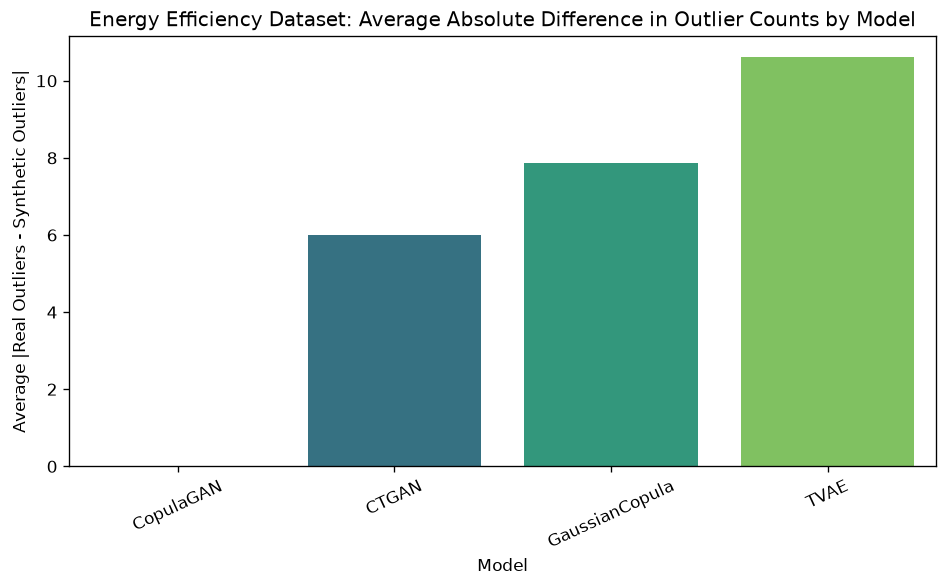

In [34]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "Y1"]

def outlier_count_iqr(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lo = q1 - 1.5 * iqr
    hi = q3 + 1.5 * iqr
    return ((series < lo) | (series > hi)).sum()

rows = []
feature_diff_by_model = {}

real_outliers = {c: outlier_count_iqr(real_df[c]) for c in num_cols}

for model in model_order:
    synth_df = synthetic_datasets[model][real_df.columns].copy()
    synth_outliers = {c: outlier_count_iqr(synth_df[c]) for c in num_cols}

    feat_df = pd.DataFrame({
        "Feature": num_cols,
        "Real_Outliers": [real_outliers[c] for c in num_cols],
        "Synthetic_Outliers": [synth_outliers[c] for c in num_cols]
    })
    feat_df["Abs_Diff_Outlier_Count"] = (feat_df["Real_Outliers"] - feat_df["Synthetic_Outliers"]).abs()

    feature_diff_by_model[model] = feat_df
    rows.append({
        "Model": model,
        "Avg_Abs_Diff_Outlier_Count": float(feat_df["Abs_Diff_Outlier_Count"].mean()),
        "Median_Abs_Diff_Outlier_Count": float(feat_df["Abs_Diff_Outlier_Count"].median()),
        "Max_Abs_Diff_Outlier_Count": float(feat_df["Abs_Diff_Outlier_Count"].max())
    })

outlier_summary_df = pd.DataFrame(rows).sort_values("Avg_Abs_Diff_Outlier_Count").reset_index(drop=True)

print("Average absolute difference in outlier counts (Real vs Synthetic) by model:")
display(outlier_summary_df)

plt.figure(figsize=(8, 5), dpi=120)
sns.barplot(data=outlier_summary_df, x="Model", y="Avg_Abs_Diff_Outlier_Count", palette="viridis")
plt.title("Energy Efficiency Dataset: Average Absolute Difference in Outlier Counts by Model")
plt.xlabel("Model")
plt.ylabel("Average |Real Outliers - Synthetic Outliers|")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()


# 6. Cosine Similarity with Hungraian Mapping

In [35]:
from numpy.linalg import norm
import numpy as np
import pandas as pd
from sdv.single_table import CTGANSynthesizer, CopulaGANSynthesizer, TVAESynthesizer, GaussianCopulaSynthesizer

if "ctgan" not in globals():
    ctgan = CTGANSynthesizer(metadata=metadata)
    ctgan.fit(data)

if "copulagan" not in globals():
    copulagan = CopulaGANSynthesizer(metadata=metadata)
    copulagan.fit(data)

if "tvae" not in globals():
    tvae = TVAESynthesizer(metadata=metadata)
    tvae.fit(data)

if "gaussiancopula" not in globals():
    gaussiancopula = GaussianCopulaSynthesizer(metadata=metadata)
    gaussiancopula.fit(data)

synth_models = {
    "CTGAN": ctgan,
    "CopulaGAN": copulagan,
    "TVAE": tvae,
    "GaussianCopula": gaussiancopula
}

n_rows = len(data)
synthetic_data = {}
for name, synth in synth_models.items():
    synthetic_data[name] = synth.sample(num_rows=n_rows)[data.columns]

def normalize_rows(X):
    X = np.asarray(X, dtype=np.float64)
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

cosine_results = {}
cosine_dfs = {}

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "Y1"]

real_matrix = normalize_rows(data[num_cols].to_numpy(dtype=np.float64))

for model_name, synth_df in synthetic_data.items():
    print(f"Building cosine similarity DataFrame for {model_name}...")

    synth_matrix = normalize_rows(synth_df[num_cols].to_numpy(dtype=np.float64))
    cosine_matrix = real_matrix @ synth_matrix.T

    block_n = 10
    n = min(block_n, cosine_matrix.shape[0], cosine_matrix.shape[1])

    cosine_df = pd.DataFrame(
        cosine_matrix[:n, :n],
        index=[f"R{i+1}" for i in range(n)],
        columns=[f"S{j+1}" for j in range(n)]
    )

    cosine_dfs[model_name] = cosine_df
    cosine_results[model_name] = {
        "avg_cosine": float(cosine_matrix.mean()),
        "max_cosine": float(cosine_matrix.max())
    }

    print(cosine_df, "\n")

display(pd.DataFrame(cosine_results).T)


Building cosine similarity DataFrame for CTGAN...
           S1        S2        S3        S4        S5        S6        S7  \
R1   0.997210  0.978472  0.998098  0.997208  0.999738  0.999037  0.987726   
R2   0.996061  0.973512  0.996582  0.995320  0.999445  0.999150  0.985971   
R3   0.993209  0.986752  0.995264  0.995548  0.992954  0.991016  0.985726   
R4   0.995477  0.985634  0.997214  0.997172  0.995984  0.994390  0.987434   
R5   0.996805  0.976228  0.997514  0.996447  0.999743  0.999239  0.987032   
R6   0.996374  0.984601  0.997925  0.997705  0.997312  0.995912  0.988021   
R7   0.993207  0.986752  0.995266  0.995542  0.992950  0.991018  0.985718   
R8   0.993207  0.986750  0.995265  0.995545  0.992953  0.991016  0.985720   
R9   0.996796  0.976216  0.997508  0.996436  0.999737  0.999233  0.987015   
R10  0.993701  0.986609  0.995696  0.995921  0.993592  0.991713  0.986111   

           S8        S9       S10  
R1   0.999226  0.991663  0.998864  
R2   0.998355  0.986753  0.997

,avg_cosine,max_cosine
CTGAN,0.992334,0.999996
CopulaGAN,0.991272,0.999997
TVAE,0.994249,1.000000
GaussianCopula,0.993300,1.000000


In [36]:
import numpy as np
import pandas as pd
from numpy.linalg import norm

def normalize_rows(X):
    X = np.asarray(X, dtype=np.float64)
    return X / (norm(X, axis=1, keepdims=True) + 1e-12)

def associate_real_with_synthetic(real_data: pd.DataFrame, synthetic_data: pd.DataFrame):
    num_cols = real_data.select_dtypes(include=["number"]).columns.tolist()
    num_cols = [c for c in num_cols if c != "Y1"]

    R = real_data[num_cols].to_numpy(dtype=np.float64)
    S = synthetic_data[num_cols].to_numpy(dtype=np.float64)

    R_norm = normalize_rows(R)
    S_norm = normalize_rows(S)

    cos_sim = R_norm @ S_norm.T
    best_s_idx = np.argmax(cos_sim, axis=1)
    best_sim = cos_sim[np.arange(len(R)), best_s_idx]

    return best_s_idx, best_sim, cos_sim

data = data.copy()
results = {}

for name, synth_df in synthetic_data.items():
    synth_df = synth_df[data.columns].copy()
    best_indices, best_sims, cos_matrix = associate_real_with_synthetic(data, synth_df)

    results[name] = {
        "best_indices": best_indices,
        "best_sims": best_sims,
        "cos_matrix": cos_matrix,
    }

    top_idx = np.argsort(best_sims)[::-1][:10]

    print(f"\n{name} - Top 10 Real -> Synthetic Matchings")
    for rank, i in enumerate(top_idx, 1):
        print(f"{rank:02d}. R{i+1} -> S{best_indices[i]+1}   cosine similarity = {best_sims[i]:.4f}")



CTGAN - Top 10 Real -> Synthetic Matchings
01. R473 -> S651   cosine similarity = 1.0000
02. R152 -> S651   cosine similarity = 1.0000
03. R156 -> S603   cosine similarity = 1.0000
04. R663 -> S603   cosine similarity = 1.0000
05. R272 -> S651   cosine similarity = 1.0000
06. R669 -> S603   cosine similarity = 1.0000
07. R227 -> S603   cosine similarity = 1.0000
08. R681 -> S603   cosine similarity = 1.0000
09. R288 -> S603   cosine similarity = 1.0000
10. R309 -> S603   cosine similarity = 1.0000

CopulaGAN - Top 10 Real -> Synthetic Matchings
01. R285 -> S643   cosine similarity = 1.0000
02. R259 -> S643   cosine similarity = 1.0000
03. R757 -> S643   cosine similarity = 1.0000
04. R164 -> S643   cosine similarity = 1.0000
05. R205 -> S643   cosine similarity = 1.0000
06. R284 -> S643   cosine similarity = 1.0000
07. R620 -> S671   cosine similarity = 1.0000
08. R665 -> S671   cosine similarity = 1.0000
09. R464 -> S643   cosine similarity = 1.0000
10. R230 -> S643   cosine similari

In [37]:
import numpy as np
import pandas as pd
from numpy.linalg import norm
from scipy.optimize import linear_sum_assignment

def normalize_rows(X: np.ndarray) -> np.ndarray:
    X = np.asarray(X, dtype=np.float64)
    norms = norm(X, axis=1, keepdims=True) + 1e-12
    return X / norms

def cosine_similarity_matrix(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None) -> np.ndarray:
    if num_cols is None:
        num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
    num_cols = [c for c in num_cols if c != "Y1"]

    R = real_df[num_cols].to_numpy(dtype=np.float64)
    S = synth_df[num_cols].to_numpy(dtype=np.float64)
    return normalize_rows(R) @ normalize_rows(S).T

def hungarian_match(real_df: pd.DataFrame, synth_df: pd.DataFrame, num_cols=None):
    cos_sim = cosine_similarity_matrix(real_df, synth_df, num_cols)
    n_real, n_synth = cos_sim.shape

    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(1.0 - cos_sim)
    else:
        col_ind, row_ind = linear_sum_assignment(1.0 - cos_sim.T)

    sims = cos_sim[row_ind, col_ind]
    avg_sim = float(sims.mean())
    return row_ind, col_ind, sims, avg_sim, cos_sim

real_df = data.copy()
results = {}

for name in ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]:
    synth_df = synthetic_data[name][real_df.columns].copy()

    print(f"\n==============================")
    print(f"{name}: Hungarian matching (cosine, numeric features excluding quality)")
    print(f"==============================")

    row_ind, col_ind, sims, avg_sim, cos_matrix = hungarian_match(real_df, synth_df)

    results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "similarities": sims,
        "avg_similarity": avg_sim,
        "cos_matrix": cos_matrix,
    }

    print(f"Average cosine similarity (Hungarian match): {avg_sim:.4f}\n")

    order = np.argsort(sims)[::-1]
    top_k = min(10, len(order))
    for r in range(top_k):
        k = order[r]
        print(f"R{row_ind[k]+1} <-> S{col_ind[k]+1}   cosine similarity = {sims[k]:.4f}")



CTGAN: Hungarian matching (cosine, numeric features excluding quality)
Average cosine similarity (Hungarian match): 0.9967

R18 <-> S129   cosine similarity = 1.0000
R585 <-> S286   cosine similarity = 1.0000
R424 <-> S194   cosine similarity = 1.0000
R115 <-> S279   cosine similarity = 1.0000
R584 <-> S378   cosine similarity = 1.0000
R760 <-> S529   cosine similarity = 1.0000
R375 <-> S443   cosine similarity = 0.9999
R501 <-> S452   cosine similarity = 0.9999
R716 <-> S68   cosine similarity = 0.9999
R143 <-> S305   cosine similarity = 0.9999

CopulaGAN: Hungarian matching (cosine, numeric features excluding quality)
Average cosine similarity (Hungarian match): 0.9968

R484 <-> S205   cosine similarity = 1.0000
R317 <-> S518   cosine similarity = 1.0000
R169 <-> S204   cosine similarity = 1.0000
R260 <-> S277   cosine similarity = 1.0000
R164 <-> S230   cosine similarity = 1.0000
R515 <-> S139   cosine similarity = 1.0000
R609 <-> S515   cosine similarity = 1.0000
R230 <-> S268   c

In [38]:
import pandas as pd
import numpy as np

real_df = data.copy()
feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != "Y1"]

if "synthetic_data" in globals():
    synth_source = synthetic_data
elif "synthetic_tables" in globals():
    synth_source = synthetic_tables
else:
    raise NameError("No synthetic source found. Expected `synthetic_data` or `synthetic_tables`.")

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
output_file = "Hungarian_Matchings_All_Models_EnergyEfficiency.xlsx"

combined_rows = []
summary_rows = []

with pd.ExcelWriter(output_file, engine="xlsxwriter") as writer:
    for model_name in model_order:
        if model_name not in results or model_name not in synth_source:
            continue

        row_ind = results[model_name]["row_ind"]
        col_ind = results[model_name]["col_ind"]

        if "similarities" in results[model_name]:
            score_key = "cosine_similarity"
            scores = results[model_name]["similarities"]
        elif "distances" in results[model_name]:
            score_key = "mahalanobis_distance"
            scores = results[model_name]["distances"]
        else:
            raise KeyError(f"No score array found for model {model_name}. Expected 'similarities' or 'distances'.")

        mapping_df = pd.DataFrame({
            "Model": model_name,
            "real_index": row_ind,
            "synthetic_index": col_ind,
            "real_label": [f"R{i+1}" for i in row_ind],
            "synthetic_label": [f"S{j+1}" for j in col_ind],
            score_key: scores
        })

        real_part = real_df.iloc[row_ind][feature_cols].reset_index(drop=True)
        real_part.insert(0, "real_label", [f"R{i+1}" for i in row_ind])

        synth_df = synth_source[model_name][real_df.columns].copy()
        synth_part = synth_df.iloc[col_ind][feature_cols].reset_index(drop=True)
        synth_part.insert(0, "synthetic_label", [f"S{j+1}" for j in col_ind])

        side_by_side = pd.concat(
            [
                mapping_df.reset_index(drop=True),
                real_part.add_prefix("real_"),
                synth_part.add_prefix("synth_")
            ],
            axis=1
        )

        side_by_side.to_excel(writer, sheet_name=model_name[:31], index=False)
        combined_rows.append(side_by_side)

        summary_row = {
            "Model": model_name,
            "Num_Matches": len(scores),
            f"Avg_{score_key}": float(np.mean(scores)),
            f"Median_{score_key}": float(np.median(scores)),
            f"Min_{score_key}": float(np.min(scores)),
            f"Max_{score_key}": float(np.max(scores)),
        }
        summary_rows.append(summary_row)

    if combined_rows:
        combined_df = pd.concat(combined_rows, ignore_index=True)
        combined_df.to_excel(writer, sheet_name="All_Models_Combined", index=False)

    if summary_rows:
        summary_df = pd.DataFrame(summary_rows)
        sort_col = [c for c in summary_df.columns if c.startswith("Avg_")][0]
        ascending = False if "cosine" in sort_col else True
        summary_df = summary_df.sort_values(sort_col, ascending=ascending)
        summary_df.to_excel(writer, sheet_name="Summary", index=False)

print(f"Saved: {output_file}")
display(summary_df)


Saved: Hungarian_Matchings_All_Models_EnergyEfficiency.xlsx


,Model,Num_Matches,Avg_cosine_similarity,Median_cosine_similarity,Min_cosine_similarity,Max_cosine_similarity
3,GaussianCopula,768,0.999323,0.999589,0.995123,1.000000
2,TVAE,768,0.999186,0.999531,0.993071,1.000000
1,CopulaGAN,768,0.996751,0.997670,0.986088,0.999996
0,CTGAN,768,0.996661,0.998229,0.979812,0.999994


# 7. Mahalanobis distance with Hungrain Mapping  

In [39]:
import numpy as np
from numpy.linalg import inv, LinAlgError

def fit_mahalanobis_params(real_matrix, reg=1e-6):
    mu = np.mean(real_matrix, axis=0)
    cov = np.cov(real_matrix, rowvar=False)
    if cov.ndim == 0:
        cov = np.array([[cov]])
    p = cov.shape[0]
    try:
        inv_cov = inv(cov + reg * np.eye(p))
    except LinAlgError:
        inv_cov = np.linalg.pinv(cov + reg * np.eye(p))
    return mu, inv_cov

def mahalanobis_distances_to_distribution(synth_matrix, mu, inv_cov):
    delta = synth_matrix - mu
    d2 = np.einsum("ij,jk,ik->i", delta, inv_cov, delta)
    return np.sqrt(np.maximum(d2, 0.0))

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "Y1"]

data_numeric = data[num_cols].dropna().copy()
real_matrix = data_numeric.to_numpy(dtype=np.float64)

mu_real, inv_cov_real = fit_mahalanobis_params(real_matrix)
print("Fitted mean and inverse covariance on real feature data.")
print(f"Used features: {len(num_cols)}")
print(f"Mean shape: {mu_real.shape}, Inv_cov shape: {inv_cov_real.shape}")


Fitted mean and inverse covariance on real feature data.
Used features: 8
Mean shape: (8,), Inv_cov shape: (8, 8)


In [40]:
mahalanobis_results = {}

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "Y1"]

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_df = synthetic_data[name][num_cols].copy()
    synth_numeric = synth_df.to_numpy(dtype=np.float64)

    dists = mahalanobis_distances_to_distribution(synth_numeric, mu_real, inv_cov_real)

    mahalanobis_results[name] = {
        "mean": float(np.mean(dists)),
        "median": float(np.median(dists)),
        "std": float(np.std(dists)),
        "min": float(np.min(dists)),
        "max": float(np.max(dists)),
        "distances": dists,
    }

summary = pd.DataFrame({
    name: [r["mean"], r["median"], r["std"], r["min"], r["max"]]
    for name, r in mahalanobis_results.items()
}, index=["mean_dist", "median_dist", "std_dist", "min_dist", "max_dist"]).T

summary.index.name = "Model"
summary = summary.sort_values("mean_dist")

print("Mahalanobis distance to real distribution (lower is better):")
display(summary)


Mahalanobis distance to real distribution (lower is better):


,mean_dist,median_dist,std_dist,min_dist,max_dist
Model,,,,,
TVAE,18868.032841,14472.390125,16774.048288,41.265657,99800.287206
GaussianCopula,21169.772228,19420.355680,15140.185332,10.921273,78628.548116
CTGAN,45637.726708,40179.761560,31959.100273,163.326141,139212.542526
CopulaGAN,51117.384961,45687.026962,34907.204094,83.578601,136673.239486


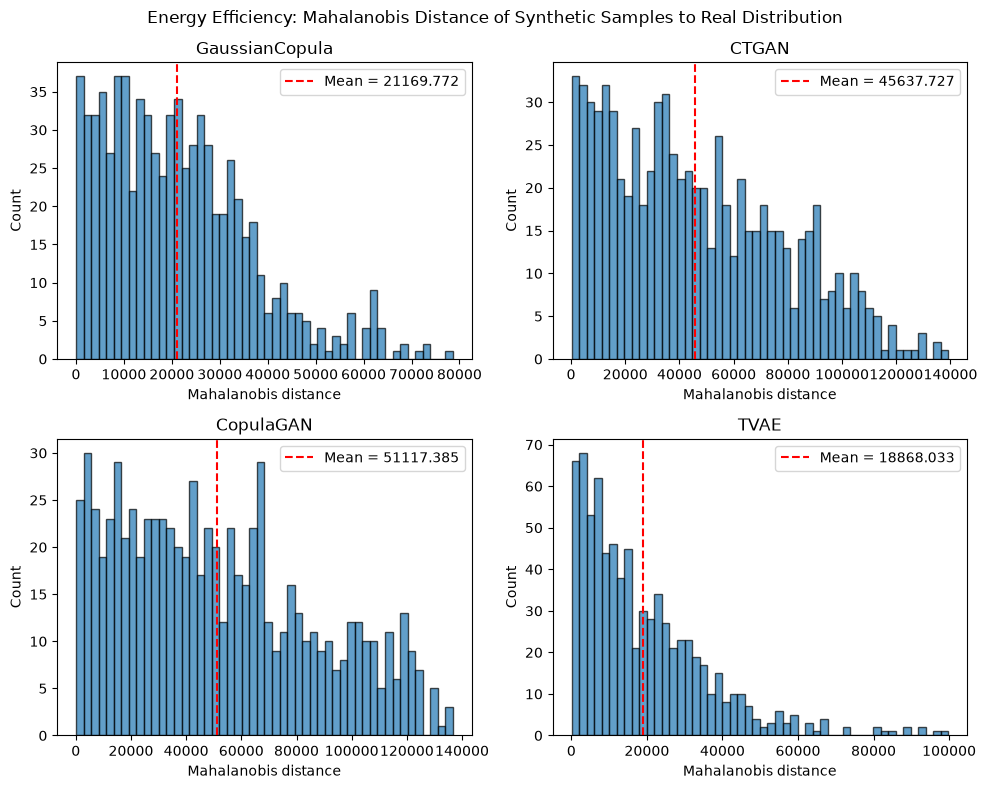

In [41]:
import os
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for ax, (name, res) in zip(axes, mahalanobis_results.items()):
    ax.hist(res["distances"], bins=50, edgecolor="black", alpha=0.7)
    ax.axvline(res["mean"], color="red", linestyle="--", label=f"Mean = {res['mean']:.3f}")
    ax.set_title(name)
    ax.set_xlabel("Mahalanobis distance")
    ax.set_ylabel("Count")
    ax.legend()

for j in range(len(mahalanobis_results), len(axes)):
    axes[j].axis("off")

plt.suptitle("Energy Efficiency: Mahalanobis Distance of Synthetic Samples to Real Distribution", fontsize=12)
plt.tight_layout()

ROOT = os.getcwd()
fig_dir = os.path.join(ROOT, "figures")
os.makedirs(fig_dir, exist_ok=True)

plt.savefig(
    os.path.join(fig_dir, "mahalanobis_energyefficiency_by_model.png"),
    dpi=150,
    bbox_inches="tight"
)

plt.show()


In [42]:
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment
import numpy as np
import pandas as pd

def pairwise_mahalanobis(real_matrix, synth_matrix, inv_cov):
    return cdist(real_matrix, synth_matrix, metric="mahalanobis", VI=inv_cov)

hungarian_results = {}

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "Y1"]

real_matrix = data[num_cols].to_numpy(dtype=np.float64)
n_samples = len(real_matrix)

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_numeric = synthetic_data[name][num_cols].to_numpy(dtype=np.float64)
    assert synth_numeric.shape[0] == n_samples, (
        f"Synthetic size {synth_numeric.shape[0]} != real size {n_samples}"
    )

    D = pairwise_mahalanobis(real_matrix, synth_numeric, inv_cov_real)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

    row_ind, col_ind = linear_sum_assignment(D)
    matched_distances = D[row_ind, col_ind]

    hungarian_results[name] = {
        "total_distance": float(matched_distances.sum()),
        "mean_distance_per_match": float(matched_distances.mean()),
        "median_distance_per_match": float(np.median(matched_distances)),
        "std_distance_per_match": float(np.std(matched_distances)),
        "max_distance_per_match": float(matched_distances.max()),
        "matched_distances": matched_distances,
        "row_ind": row_ind,
        "col_ind": col_ind,
    }

hungarian_summary = pd.DataFrame(
    {
        name: [
            r["mean_distance_per_match"],
            r["median_distance_per_match"],
            r["std_distance_per_match"],
            r["max_distance_per_match"],
        ]
        for name, r in hungarian_results.items()
    },
    index=[
        "mean_distance_per_match",
        "median_distance_per_match",
        "std_distance_per_match",
        "max_distance_per_match",
    ],
).T

hungarian_summary.index.name = "Model"
hungarian_summary = hungarian_summary.sort_values("mean_distance_per_match")

print("Hungarian matching using Mahalanobis distance (lower is better):")
display(hungarian_summary)


Hungarian matching using Mahalanobis distance (lower is better):


,mean_distance_per_match,median_distance_per_match,std_distance_per_match,max_distance_per_match
Model,,,,
TVAE,18868.030988,14472.389548,16774.049939,99800.287156
GaussianCopula,21169.768524,19420.355514,15140.189999,78628.548177
CTGAN,45637.724902,40179.761358,31959.102356,139212.542481
CopulaGAN,51117.382555,45687.026622,34907.207095,136673.239305


In [43]:
import numpy as np
import pandas as pd

def greedy_one_to_one_matching_fast(D):
    n_rows, n_cols = D.shape
    n_match = min(n_rows, n_cols)

    used_rows = np.zeros(n_rows, dtype=bool)
    used_cols = np.zeros(n_cols, dtype=bool)

    flat_order = np.argsort(D, axis=None)
    pairs = []

    for idx in flat_order:
        i = idx // n_cols
        j = idx % n_cols
        if not used_rows[i] and not used_cols[j]:
            used_rows[i] = True
            used_cols[j] = True
            pairs.append((i, j, float(D[i, j])))
            if len(pairs) == n_match:
                break

    distances = np.array([p[2] for p in pairs], dtype=np.float64)
    total_distance = float(distances.sum()) if len(distances) else np.nan
    mean_distance = float(distances.mean()) if len(distances) else np.nan
    return total_distance, mean_distance, pairs

greedy_results = {}
comparison_rows = []

num_cols = data.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "Y1"]

X_real_full = data[num_cols].to_numpy(dtype=np.float64)

MAX_ROWS = 2000
rng = np.random.default_rng(42)

if len(X_real_full) > MAX_ROWS:
    real_idx = rng.choice(len(X_real_full), size=MAX_ROWS, replace=False)
else:
    real_idx = np.arange(len(X_real_full))

X_real = X_real_full[real_idx]

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    X_synth_full = synthetic_data[name][num_cols].to_numpy(dtype=np.float64)

    if len(X_synth_full) > MAX_ROWS:
        synth_idx = rng.choice(len(X_synth_full), size=MAX_ROWS, replace=False)
    else:
        synth_idx = np.arange(len(X_synth_full))

    X_synth = X_synth_full[synth_idx]

    D = pairwise_mahalanobis(X_real, X_synth, inv_cov_real)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

    total_g, mean_g, _ = greedy_one_to_one_matching_fast(D)

    greedy_results[name] = {
        "total_distance": total_g,
        "mean_distance": mean_g
    }

    h_total = hungarian_results[name]["total_distance"]
    h_mean = hungarian_results[name]["mean_distance_per_match"]

    comparison_rows.append({
        "Model": name,
        "Rows_Used_For_Greedy": int(min(len(X_real), len(X_synth))),
        "Greedy total (sampled)": total_g,
        "Hungarian total (full)": h_total,
        "Greedy mean (sampled)": mean_g,
        "Hungarian mean (full)": h_mean,
        "Total diff": total_g - h_total,
        "Mean diff": mean_g - h_mean,
    })

greedy_summary = pd.DataFrame({
    name: [greedy_results[name]["total_distance"], greedy_results[name]["mean_distance"]]
    for name in greedy_results
}, index=["total_distance", "mean_distance"]).T
greedy_summary.index.name = "Model"

print("Greedy one-to-one matching (fast sampled version):")
display(greedy_summary)

print("\nComparison table:")
comparison_df = pd.DataFrame(comparison_rows).set_index("Model")
display(comparison_df)


Greedy one-to-one matching (fast sampled version):


,total_distance,mean_distance
Model,,
GaussianCopula,1.625838e+07,21169.768599
CTGAN,3.504977e+07,45637.724946
CopulaGAN,3.925815e+07,51117.382605
TVAE,1.449065e+07,18868.031041



Comparison table:


,Rows_Used_For_Greedy,Greedy total (sampled),Hungarian total (full),Greedy mean (sampled),Hungarian mean (full),Total diff,Mean diff
Model,,,,,,,
GaussianCopula,768,1.625838e+07,1.625838e+07,21169.768599,21169.768524,0.057167,0.000074
CTGAN,768,3.504977e+07,3.504977e+07,45637.724946,45637.724902,0.033868,0.000044
CopulaGAN,768,3.925815e+07,3.925815e+07,51117.382605,51117.382555,0.038698,0.000050
TVAE,768,1.449065e+07,1.449065e+07,18868.031041,18868.030988,0.040869,0.000053


In [44]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

def mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real):
    R = real_df[feature_cols].to_numpy(dtype=np.float64)
    S = synth_df[feature_cols].to_numpy(dtype=np.float64)
    return cdist(R, S, metric="mahalanobis", VI=inv_cov_real)

def hungarian_match_mahalanobis(real_df, synth_df, feature_cols, inv_cov_real):
    D = mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real)
    D = np.nan_to_num(np.asarray(D, dtype=np.float64), nan=1e10, posinf=1e10, neginf=1e10)

    n_real, n_synth = D.shape
    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]
    return row_ind, col_ind, dists, float(dists.mean()), D

real_df = data.copy()

feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != "Y1"]
print("Using numeric non-target features:", len(feature_cols))

X_real = real_df[feature_cols].to_numpy(dtype=np.float64)
mu_real = X_real.mean(axis=0)
cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

mahalanobis_results = {}

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_df = synthetic_data[name][real_df.columns].copy()

    row_ind, col_ind, dists, avg_dist, D = hungarian_match_mahalanobis(
        real_df=real_df,
        synth_df=synth_df,
        feature_cols=feature_cols,
        inv_cov_real=inv_cov_real
    )

    mahalanobis_results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "distances": dists,
        "avg_distance": avg_dist
    }

    print(f"{name}: avg matched Mahalanobis distance = {avg_dist:.4f}")


Using numeric non-target features: 8
GaussianCopula: avg matched Mahalanobis distance = 21169.7699
CTGAN: avg matched Mahalanobis distance = 45637.7279
CopulaGAN: avg matched Mahalanobis distance = 51117.3859
TVAE: avg matched Mahalanobis distance = 18868.0322


In [45]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

def mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real):
    R = real_df[feature_cols].to_numpy(dtype=np.float64)
    S = synth_df[feature_cols].to_numpy(dtype=np.float64)
    return cdist(R, S, metric="mahalanobis", VI=inv_cov_real)

def hungarian_match_mahalanobis(real_df, synth_df, feature_cols, inv_cov_real):
    D = mahalanobis_distance_matrix(real_df, synth_df, feature_cols, inv_cov_real)
    D = np.nan_to_num(np.asarray(D, dtype=np.float64), nan=1e10, posinf=1e10, neginf=1e10)

    n_real, n_synth = D.shape
    if n_real <= n_synth:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]
    return row_ind, col_ind, dists, float(dists.mean()), D

real_df = data.copy()

feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != "Y1"]
print("Using numeric non-target features:", len(feature_cols))

X_real = real_df[feature_cols].to_numpy(dtype=np.float64)
mu_real = X_real.mean(axis=0)
cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

mahalanobis_results = {}

for name in ["GaussianCopula", "CTGAN", "CopulaGAN", "TVAE"]:
    synth_df = synthetic_data[name][real_df.columns].copy()

    row_ind, col_ind, dists, avg_dist, D = hungarian_match_mahalanobis(
        real_df=real_df,
        synth_df=synth_df,
        feature_cols=feature_cols,
        inv_cov_real=inv_cov_real
    )

    mahalanobis_results[name] = {
        "row_ind": row_ind,
        "col_ind": col_ind,
        "distances": dists,
        "avg_distance": avg_dist
    }

    print(f"{name}: avg matched Mahalanobis distance = {avg_dist:.4f}")


Using numeric non-target features: 8
GaussianCopula: avg matched Mahalanobis distance = 21169.7699
CTGAN: avg matched Mahalanobis distance = 45637.7279
CopulaGAN: avg matched Mahalanobis distance = 51117.3859
TVAE: avg matched Mahalanobis distance = 18868.0322


In [46]:
import numpy as np
from scipy.spatial.distance import cdist
from scipy.optimize import linear_sum_assignment

feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != "Y1"]

real_df = data.copy()
X_real = real_df[feature_cols].to_numpy(dtype=np.float64)

cov_real = np.cov(X_real, rowvar=False)
inv_cov_real = np.linalg.pinv(cov_real + 1e-6 * np.eye(cov_real.shape[0]))

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

for model_name in model_order:
    synth_df = synthetic_data[model_name][real_df.columns].copy()
    X_synth = synth_df[feature_cols].to_numpy(dtype=np.float64)

    D = cdist(X_real, X_synth, metric="mahalanobis", VI=inv_cov_real)
    D = np.nan_to_num(D, nan=1e10, posinf=1e10, neginf=1e10)

    if D.shape[0] <= D.shape[1]:
        row_ind, col_ind = linear_sum_assignment(D)
    else:
        col_ind, row_ind = linear_sum_assignment(D.T)

    dists = D[row_ind, col_ind]
    r_to_match = {r: (s, d) for r, s, d in zip(row_ind, col_ind, dists)}

    print(f"\n{model_name} - Hungarian mappings for R1 to R20:")
    for r in range(20):
        if r in r_to_match:
            s, dist = r_to_match[r]
            print(f"R{r+1} -> S{s+1}   distance = {dist:.4f}")
        else:
            print(f"R{r+1} -> No match found")



CTGAN - Hungarian mappings for R1 to R20:
R1 -> S432   distance = 11716.7259
R2 -> S757   distance = 65189.0316
R3 -> S536   distance = 43200.7975
R4 -> S218   distance = 47356.7619
R5 -> S440   distance = 57530.2996
R6 -> S54   distance = 64176.5778
R7 -> S144   distance = 15554.2489
R8 -> S244   distance = 65442.1455
R9 -> S19   distance = 14615.2764
R10 -> S219   distance = 14296.8435
R11 -> S666   distance = 72406.8546
R12 -> S23   distance = 12467.9558
R13 -> S17   distance = 98493.8991
R14 -> S382   distance = 52500.6886
R15 -> S74   distance = 75607.5185
R16 -> S73   distance = 441.4340
R17 -> S614   distance = 12337.2728
R18 -> S475   distance = 35166.4793
R19 -> S473   distance = 72994.7344
R20 -> S305   distance = 4915.3350

CopulaGAN - Hungarian mappings for R1 to R20:
R1 -> S701   distance = 32169.9473
R2 -> S438   distance = 23188.4834
R3 -> S569   distance = 18452.8078
R4 -> S31   distance = 130418.8872
R5 -> S567   distance = 122017.1468
R6 -> S475   distance = 653.2363

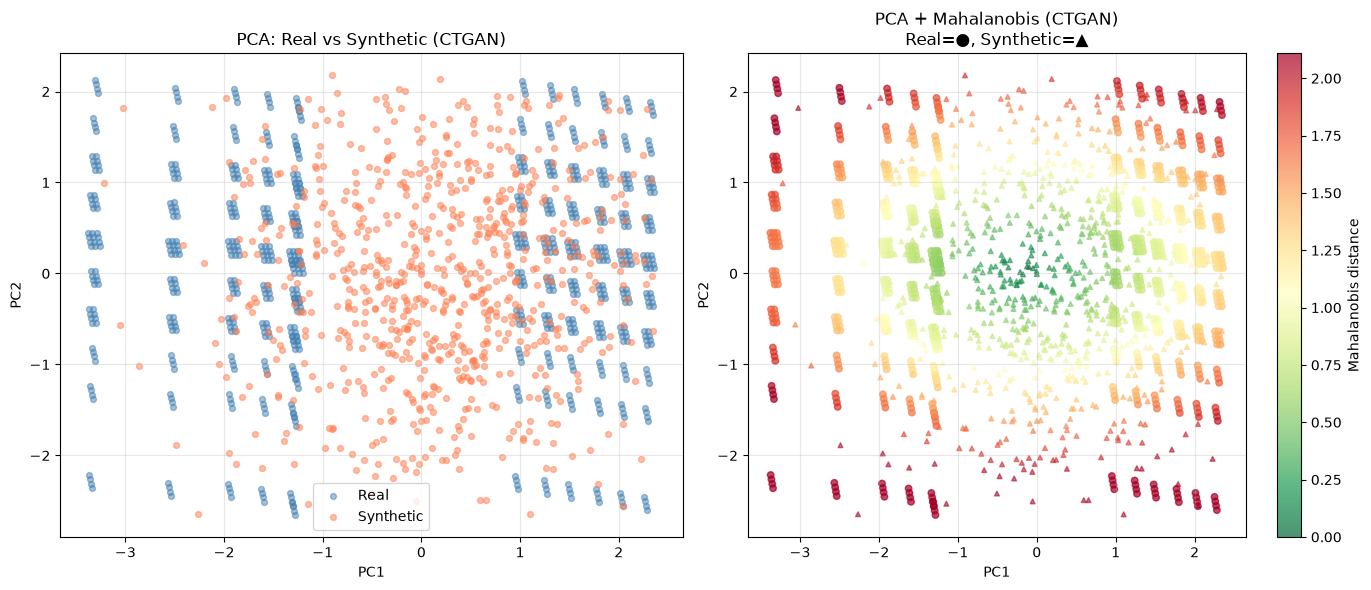

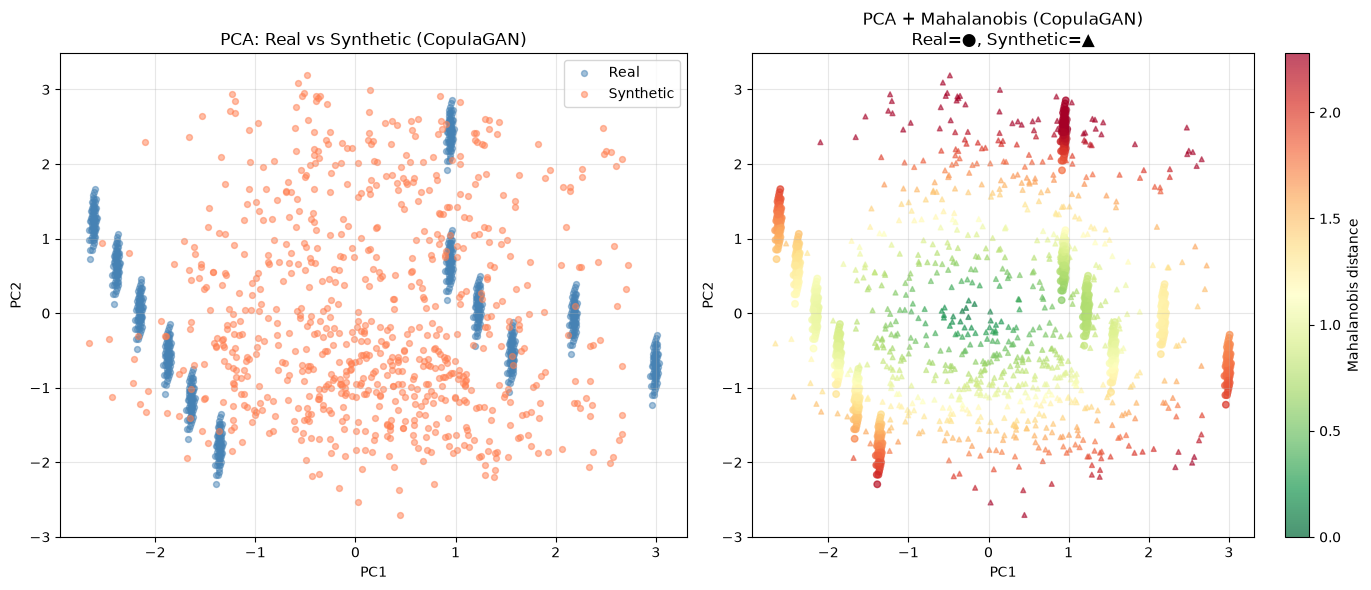

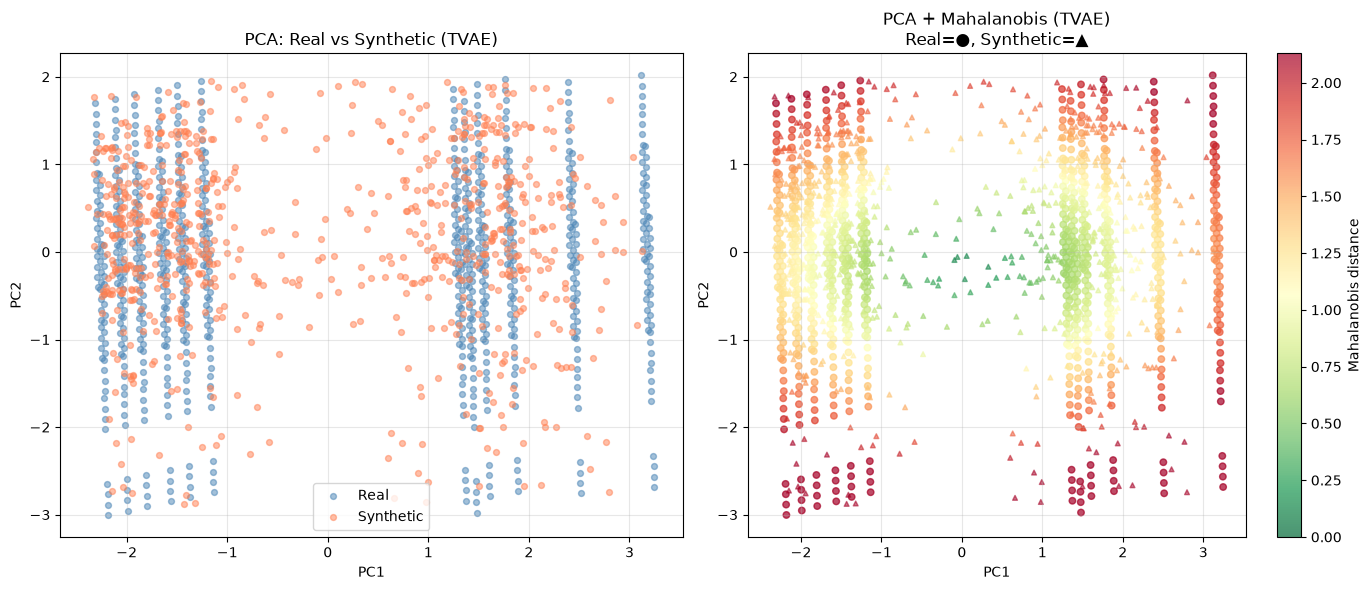

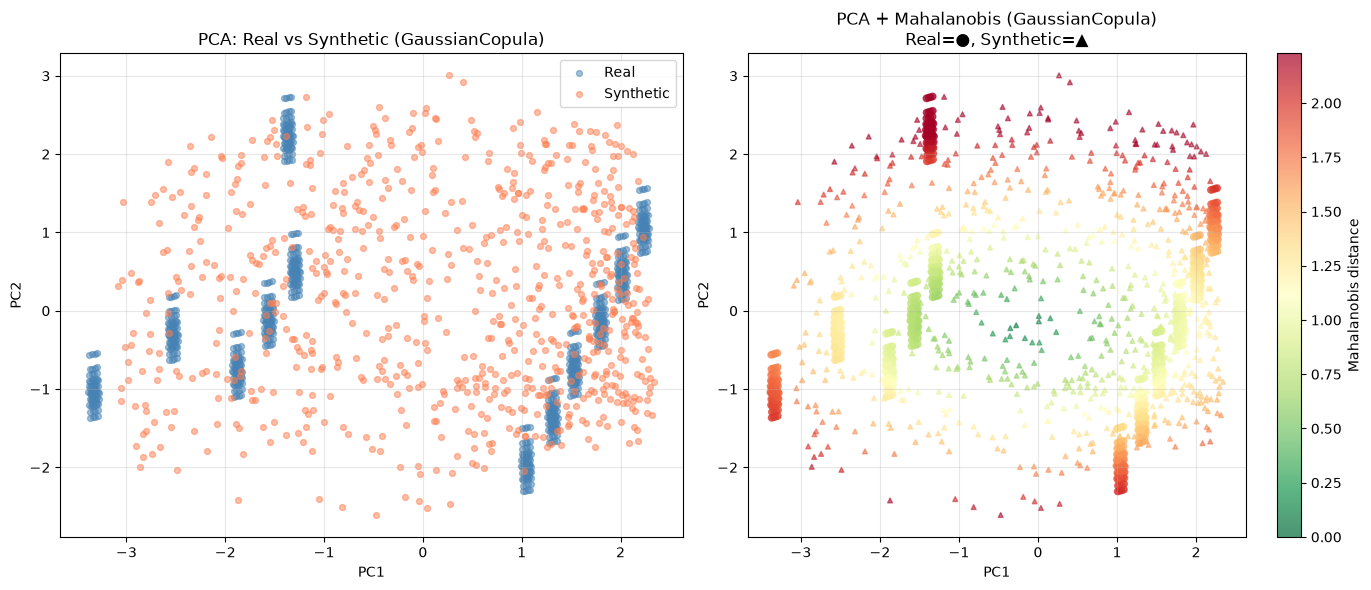

,Model,Real_Mean_MD_2D,Synth_Mean_MD_2D,Delta_Synth_minus_Real
0,CTGAN,1.324941,0.995713,-0.329228
2,TVAE,1.331059,1.213086,-0.117973
1,CopulaGAN,1.342225,1.214706,-0.127518
3,GaussianCopula,1.341611,1.310923,-0.030688


In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import inv, LinAlgError
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def _mahal_dist_2d(X, mu, inv_cov):
    delta = X - mu
    return np.sqrt(np.maximum(np.einsum("ij,jk,ik->i", delta, inv_cov, delta), 0.0))

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]

real_df = data.copy()
feature_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != "Y1"]

X_r = real_df[feature_cols].to_numpy(dtype=np.float64)
scaler = StandardScaler().fit(X_r)
X_r_s = scaler.transform(X_r)

rows = []

for model_name in model_order:
    if model_name not in synthetic_data:
        print(f"{model_name} not found in synthetic_data, skipping.")
        continue

    synth_df = synthetic_data[model_name][real_df.columns].copy()
    X_s = synth_df[feature_cols].to_numpy(dtype=np.float64)
    X_s_s = scaler.transform(X_s)

    X_all = np.vstack([X_r_s, X_s_s])
    Z_all = PCA(n_components=2, random_state=42).fit_transform(X_all)

    n_r = len(X_r_s)
    Z_r = Z_all[:n_r]
    Z_s = Z_all[n_r:]

    mu_z = np.mean(Z_r, axis=0)
    cov_z = np.cov(Z_r, rowvar=False)
    reg = 1e-6

    try:
        inv_cov_z = inv(cov_z + reg * np.eye(2))
    except LinAlgError:
        inv_cov_z = np.linalg.pinv(cov_z + reg * np.eye(2))

    d_r = _mahal_dist_2d(Z_r, mu_z, inv_cov_z)
    d_s = _mahal_dist_2d(Z_s, mu_z, inv_cov_z)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    ax.scatter(Z_r[:, 0], Z_r[:, 1], c="steelblue", alpha=0.5, s=18, label="Real")
    ax.scatter(Z_s[:, 0], Z_s[:, 1], c="coral", alpha=0.5, s=18, label="Synthetic")
    ax.set_title(f"PCA: Real vs Synthetic ({model_name})")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    vmax = np.percentile(np.hstack([d_r, d_s]), 95)
    sc = ax.scatter(
        Z_r[:, 0], Z_r[:, 1], c=d_r, cmap="RdYlGn_r", alpha=0.7, s=22, marker="o", vmin=0, vmax=vmax
    )
    ax.scatter(
        Z_s[:, 0], Z_s[:, 1], c=d_s, cmap="RdYlGn_r", alpha=0.55, s=12, marker="^", vmin=0, vmax=vmax
    )
    plt.colorbar(sc, ax=ax, label="Mahalanobis distance")
    ax.set_title(f"PCA + Mahalanobis ({model_name})\nReal=●, Synthetic=▲")
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    rows.append({
        "Model": model_name,
        "Real_Mean_MD_2D": float(d_r.mean()),
        "Synth_Mean_MD_2D": float(d_s.mean()),
        "Delta_Synth_minus_Real": float(d_s.mean() - d_r.mean())
    })

summary_df = pd.DataFrame(rows).sort_values("Synth_Mean_MD_2D")
display(summary_df)


In [48]:
import pandas as pd
import numpy as np

def export_all_models_hungarian_mahalanobis_excel(
    real_df: pd.DataFrame,
    synthetic_data: dict,
    hungarian_results: dict,
    num_cols: list,
    filename: str = "Hungarian_Mahalanobis_Four_Models_EnergyEfficiency.xlsx"
):
    model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
    summary_rows = []

    with pd.ExcelWriter(filename, engine="openpyxl") as writer:
        for model_name in model_order:
            if model_name not in synthetic_data or model_name not in hungarian_results:
                continue

            synth_df = synthetic_data[model_name].copy()
            _common = [c for c in real_df.columns if c in synth_df.columns]

            synth_df = synth_df[_common]

            row_ind = hungarian_results[model_name]["row_ind"]
            col_ind = hungarian_results[model_name]["col_ind"]

            if "dists" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["dists"]
            elif "distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["distances"]
            elif "selected_distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["selected_distances"]
            elif "matched_distances" in hungarian_results[model_name]:
                matched_distances = hungarian_results[model_name]["matched_distances"]
            else:
                raise KeyError(f"No distance array found for {model_name}")

            records = []
            for r_i, s_i, dist in zip(row_ind, col_ind, matched_distances):
                rec = {
                    "Dataset": "EnergyEfficiency",
                    "Model": model_name,
                    "Real_Index": int(r_i),
                    "Synthetic_Index": int(s_i),
                    "Real_Label": f"R{int(r_i)+1}",
                    "Synthetic_Label": f"S{int(s_i)+1}",
                    "Mahalanobis_Distance": float(dist),
                }
                for c in num_cols:
                    rec[f"Real_{c}"] = real_df.iloc[r_i][c]
                    rec[f"Synth_{c}"] = synth_df.iloc[s_i][c]
                records.append(rec)

            matched_df = pd.DataFrame(records)
            sheet_name = f"EnergyEfficiency_{model_name}"[:31]
            matched_df.to_excel(writer, sheet_name=sheet_name, index=False)

            summary_rows.append({
                "Dataset": "EnergyEfficiency",
                "Model": model_name,
                "Num_Matches": len(matched_df),
                "Mean_Distance": float(np.mean(matched_distances)),
                "Median_Distance": float(np.median(matched_distances)),
                "Std_Distance": float(np.std(matched_distances)),
                "Min_Distance": float(np.min(matched_distances)),
                "Max_Distance": float(np.max(matched_distances)),
            })

        if summary_rows:
            summary_df = pd.DataFrame(summary_rows).sort_values("Mean_Distance")
            summary_df.to_excel(writer, sheet_name="EnergyEfficiency_Summary", index=False)

    print(f"Excel file created: {filename}")


# ---- Run ----
real_df = data.copy()
num_cols = real_df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols if c != "Y1"]

export_all_models_hungarian_mahalanobis_excel(
    real_df=real_df,
    synthetic_data=synthetic_data,
    hungarian_results=hungarian_results,
    num_cols=num_cols,
    filename="Hungarian_Mahalanobis_Four_Models_EnergyEfficiency.xlsx"
)


Excel file created: Hungarian_Mahalanobis_Four_Models_EnergyEfficiency.xlsx


# 8. Privacy Metrics: Membership Inference Attack (MIA)

In [49]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import roc_curve, roc_auc_score

def model_loss_per_sample_regression(model, X, y):
    return (y - model.predict(X)) ** 2

def privacy_metrics_mia_regression(model, X_train, y_train, X_test, y_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)
    model.fit(X_train_s, y_train)
    loss_train = model_loss_per_sample_regression(model, X_train_s, y_train)
    loss_test = model_loss_per_sample_regression(model, X_test_s, y_test)
    scores = -np.concatenate([loss_train, loss_test])
    labels = np.concatenate([np.ones(len(loss_train)), np.zeros(len(loss_test))])
    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    return {"AUC": float(roc_auc_score(labels, scores)), "Advantage": float(np.max(tpr - fpr))}

target_col = "Y1"
feature_cols = [c for c in data.select_dtypes(include=[np.number]).columns if c != target_col]
real_df = data.copy()
synth_key = next(iter(synthetic_data)) if "synthetic_data" in globals() else next(iter(synthetic_outputs))
synth_src = synthetic_data if "synthetic_data" in globals() else synthetic_outputs
_common = [c for c in real_df.columns if c in synth_src[synth_key].columns]
synth_df = synth_src[synth_key][_common].copy()
model = Ridge(alpha=1.0, random_state=42)
print(privacy_metrics_mia_regression(
    model,
    real_df[feature_cols].to_numpy(dtype=np.float64),
    real_df[target_col].to_numpy(dtype=np.float64),
    synth_df[feature_cols].to_numpy(dtype=np.float64),
    synth_df[target_col].to_numpy(dtype=np.float64),
))


{'AUC': 0.8972659640842015, 'Advantage': 0.6627604166666666}


In [50]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

def privacy_metrics_mia_mahalanobis(X_train, X_test):
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s = scaler.transform(X_test)

    mu = np.mean(X_train_s, axis=0)
    cov = np.cov(X_train_s, rowvar=False)
    cov = cov + 1e-6 * np.eye(cov.shape[0])
    cov_inv = np.linalg.pinv(cov)

    diff_train = X_train_s - mu
    diff_test = X_test_s - mu

    md_train = np.sqrt(np.maximum(np.sum((diff_train @ cov_inv) * diff_train, axis=1), 0.0))
    md_test = np.sqrt(np.maximum(np.sum((diff_test @ cov_inv) * diff_test, axis=1), 0.0))

    scores = -np.concatenate([md_train, md_test])
    labels = np.concatenate([np.ones(len(md_train)), np.zeros(len(md_test))])

    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    auc = roc_auc_score(labels, scores)
    advantage = np.max(tpr - fpr)

    idx = np.searchsorted(fpr, 0.01, side="right") - 1
    idx = max(0, idx)
    tpr_at_fpr_001 = tpr[idx] if idx < len(tpr) else float("nan")

    return {
        "AUC": float(auc),
        "Advantage": float(advantage),
        "TPR_at_FPR_001": float(tpr_at_fpr_001),
        "Train_MD_Mean": float(md_train.mean()),
        "Test_MD_Mean": float(md_test.mean()),
    }

feature_cols = data.select_dtypes(include=[np.number]).columns.tolist()
feature_cols = [c for c in feature_cols if c != "Y1"]
X_train = data[feature_cols].to_numpy(dtype=np.float64)

model_order = ["CTGAN", "CopulaGAN", "TVAE", "GaussianCopula"]
rows = []

for model_name in model_order:
    X_test = synthetic_data[model_name][feature_cols].to_numpy(dtype=np.float64)
    m = privacy_metrics_mia_mahalanobis(X_train, X_test)
    m["Model"] = model_name
    rows.append(m)

comparison_df = pd.DataFrame(rows)[
    ["Model", "AUC", "Advantage", "TPR_at_FPR_001", "Train_MD_Mean", "Test_MD_Mean"]
].sort_values("AUC", ascending=False).reset_index(drop=True)

print("MIA (Mahalanobis) comparison across 4 synthetic models:")
display(comparison_df)


MIA (Mahalanobis) comparison across 4 synthetic models:


,Model,AUC,Advantage,TPR_at_FPR_001,Train_MD_Mean,Test_MD_Mean
0,CTGAN,1.000000,1.000000,1.0,2.583423,838.451956
1,CopulaGAN,1.000000,1.000000,1.0,2.583423,939.088032
2,GaussianCopula,1.000000,1.000000,1.0,2.583423,389.030517
3,TVAE,0.999522,0.996094,1.0,2.583423,346.639234
